## Bayesian inference example for WL only

### 1. Preparation of data vectors

In [1]:
import numpy as np
import tensorflow as tf

I0000 00:00:1776163818.583949   50830 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776163820.179405   50830 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776163827.280343   50830 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Necessary imports #

import sys
import os
os.environ["OMP_NUM_THREADS"] = "1"
#os.environ["OPENBLAS_NUM_THREADS"] = "1"
#os.environ["MKL_NUM_THREADS"] = "1"#
#os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
#os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
from multiprocessing import get_context
import time
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared,
    DotProduct, ConstantKernel as C
)
import seaborn as sns
import matplotlib.pyplot as plt

from nautilus import Prior
from nautilus import Sampler
from scipy.stats import norm

# Import euclidlib for reading the Euclid data
import euclidlib as el

# Import cloelib for cosmology and theoretical predictions
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations

# Import cloelike for likelihoods
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_WL

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(repo_root)

from binz.run_gp import build_gp_nz

/home/jipdebuck/miniconda3/envs/cloe_env/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...


E0000 00:00:1776163845.001793   50830 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [3]:
# Load necessary files #

# We read with euclidlib v2025.2 (v2025.1 is also compatible)

name_to_chain = 'checkpoint_WL_DR1_first_try_area_2000_realistic'
name_to_chain_gp = 'checkpoint_gp'

#cells_data = el.photo.harmonic_space.angular_power_spectra('/disks/shear16/canasherrera/SheariouslyCalibrated/data/DR1/synthetic_angular_spectra_DR1.fits')
full_cov=np.load('/home/jipdebuck/covariance_Gauss_DR1_TR1like_1589_2D.npz')['Gauss']

# Get n(z)
z_nz, nz_heracles = el.phz.redshift_distributions('/home/jipdebuck/nz_example.fits')

In [4]:
# Normalize and resample n(z)'s #

myz = np.linspace(1e-4, 3.0, 100)
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_heracles, z_nz)
dndz_she_norm = normalize_dndz(nz_heracles, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values())) #stacking arrays vertically
    my_dndz_norm = np.zeros([len(nz_example), len(myz)]) #creating an empty array
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :]) #interpolating to new myz values
    return my_dndz_norm

my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, myz)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, myz)

In [5]:
# Find boundaries for priors of x-nodes #

i_lows = {}
i_highs = {}
for key, nz in nz_heracles.items():
    mask = np.where(nz > 0.1)[0]
    i_lows.update({key: mask[0]})
    i_highs.update({key: mask[-1] + 1})
z_lows = z_nz[[i_lows[key] for key in dndz_pos_norm.keys()]]
z_highs = z_nz[[i_highs[key] for key in dndz_pos_norm.keys()]]
print(z_lows)
print(z_highs)


[0.054 0.508 0.72  0.92  1.148 1.468]
[0.716 0.966 1.192 1.44  1.772 2.914]


In [25]:
i_lows = {}
i_highs = {}
nz_lows = []
nz_highs = []
for key, nz in nz_heracles.items():
    nz_max = np.max(nz)
    mask = np.where(nz > 0.5 * nz_max)[0]
    i_lows.update({key: mask[0]})
    i_highs.update({key: mask[-1]})
    nz_lows.append(nz[mask[0]])
    nz_highs.append(nz[mask[-1]])
z_lows = z_nz[[i_lows[key] for key in dndz_pos_norm.keys()]]
z_highs = z_nz[[i_highs[key] for key in dndz_pos_norm.keys()]]
print(z_lows)
print(nz_lows)
print(z_highs)
print(nz_highs)

[0.308 0.61  0.83  1.038 1.272 1.59 ]
[np.float32(2.6645734), np.float32(3.6603994), np.float32(3.7355423), np.float32(3.3270159), np.float32(2.5905912), np.float32(1.4346577)]
[0.612 0.838 1.048 1.282 1.592 2.088]
[np.float32(2.7291179), np.float32(3.5810769), np.float32(3.7401915), np.float32(3.3221245), np.float32(2.5675595), np.float32(1.4377534)]


In [6]:
# Define fiducial parameters and ell vector #

fiducial_cosmology = {
    'H0': 67,                # Hubble constant
    'Omega_cdm0': 0.27,        # Cold dark matter density
    'Omega_b0': 0.049,         # Baryon density
    'Omega_k0': 0.0,           # Curvature
    'mnu': 0.077,                # Neutrino mass
    'w0': -1.0,                # Dark energy equation of state (present)
    'wa': 0.0,                 # Dark energy equation of state (evolution)
    'ns': 0.96,                # Scalar spectral index
    'As': 2.1e-9, # Scalar amplitude
    'gamma_MG': 0.545,         # Modified gravity parameter
    'log10TAGN': 7.75,          # AGN feedback parameter
    'N_mnu': 1,                  # Number of massive neutrino species
    'N_eff': 3.046             # Effective number of relativistic species
}

fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    # Magnification bias (per bin)
    'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
    'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
    'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
    'magnification_bias_7': 0.0, 'magnification_bias_8': 0.0,
    'magnification_bias_9': 0.0, 'magnification_bias_10': 0.0,
    'magnification_bias_11': 0.0, 'magnification_bias_12': 0.0,
    'magnification_bias_13': 0.0,
    # Redshift errors (positions)
    'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 
    'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
    'dz_pos_7': 0.0, 'dz_pos_8': 0.0, 'dz_pos_9': 0.0, 
    'dz_pos_10': 0.0, 'dz_pos_11': 0.0, 'dz_pos_12': 0.0,
    'dz_pos_13': 0.0,
    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
    'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
    'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
    'multiplicative_bias_7': 0.0, 'multiplicative_bias_8': 0.0,
    'multiplicative_bias_9': 0.0, 'multiplicative_bias_10': 0.0,
    'multiplicative_bias_11': 0.0, 'multiplicative_bias_12': 0.0,
    'multiplicative_bias_13': 0.0,
    # Redshift errors (shear)
    'dz_shear_1': 0.0, 'dz_shear_2': 0.0, 'dz_shear_3': 0.0,
    'dz_shear_4': 0.0, 'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
    'dz_shear_7': 0.0, 'dz_shear_8': 0.0, 'dz_shear_9': 0.0, 
    'dz_shear_10': 0.0, 'dz_shear_11': 0.0, 'dz_shear_12': 0.0,
    'dz_shear_13': 0.0
}

fiducial_gp = {'x1': 0.455, 'x2': 0.725, 'x3': 0.941, 'x4': 1.161, 'x5': 1.432, 'x6': 1.893, 'corr_len': 0.04}

ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])

In [7]:
# Compute cosmology #

# Choose which perturbation model to use: 'linear' or 'nonlinear'
perturbation_model = 'nonlinear'  # change to 'linear' if needed

# Cosmology parameters (easy to modify)
cosmo_params = fiducial_cosmology.copy()
nuisance_params = fiducial_nuisance.copy()

# Create background
background = CAMBBackground(
    H0=cosmo_params['H0'],
    Omega_cdm0=cosmo_params['Omega_cdm0'],
    Omega_b0=cosmo_params['Omega_b0'],
    w0=cosmo_params['w0'],
    wa=cosmo_params['wa'],
    Omega_k0=cosmo_params['Omega_k0'],
    ns=cosmo_params['ns'],
    As=cosmo_params['As'],
    mnu=cosmo_params['mnu'],
    gamma_MG=cosmo_params['gamma_MG'],
    N_mnu=cosmo_params['N_mnu']
)

# Choose perturbations
if perturbation_model == 'linear':
    perturbations = HMemuLinearPerturbations(background, myz)
else:
    perturbations = HMemuNonLinearPerturbations(
        background, 
        HMemuLinearPerturbations(background, myz), 
        myz, 
        log10TAGN=cosmo_params['log10TAGN']
    )

# Tracer definitions (only for cosmic shear)
tracer_pos = PositionsTracer(
    perturbations=perturbations,
    dndz=my_dndz_pos_norm,
    z=myz,
    galaxy_bias_model='poly',
    nuisance_params=nuisance_params
)

tracer_she = ShearTracer(
    perturbations=perturbations,
    dndz=my_dndz_she_norm,
    z=myz,
    nuisance_params=nuisance_params
)


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [8]:
# Compute the two-point angular power spectra #

cls_sheshe = AngularTwoPoint(tracer_she, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_posshe = AngularTwoPoint(tracer_pos, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_pospos = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl(ell_theory, 0, perturbations.k)
print(cls_sheshe[('SHE', 'SHE', 1,1)], len(ell_theory))

# Combine all spectra into a single dictionary for easy access
uncoupled_cls = {**cls_posshe, **cls_sheshe, **cls_pospos}
uncoupled_cls_WL = {**cls_sheshe}
print(uncoupled_cls.keys())

AngularPowerSpectrum(axis=(2,)) 32
dict_keys([('POS', 'SHE', 1, 1), ('POS', 'SHE', 1, 2), ('POS', 'SHE', 2, 1), ('POS', 'SHE', 1, 3), ('POS', 'SHE', 3, 1), ('POS', 'SHE', 1, 4), ('POS', 'SHE', 4, 1), ('POS', 'SHE', 1, 5), ('POS', 'SHE', 5, 1), ('POS', 'SHE', 1, 6), ('POS', 'SHE', 6, 1), ('POS', 'SHE', 2, 2), ('POS', 'SHE', 2, 3), ('POS', 'SHE', 3, 2), ('POS', 'SHE', 2, 4), ('POS', 'SHE', 4, 2), ('POS', 'SHE', 2, 5), ('POS', 'SHE', 5, 2), ('POS', 'SHE', 2, 6), ('POS', 'SHE', 6, 2), ('POS', 'SHE', 3, 3), ('POS', 'SHE', 3, 4), ('POS', 'SHE', 4, 3), ('POS', 'SHE', 3, 5), ('POS', 'SHE', 5, 3), ('POS', 'SHE', 3, 6), ('POS', 'SHE', 6, 3), ('POS', 'SHE', 4, 4), ('POS', 'SHE', 4, 5), ('POS', 'SHE', 5, 4), ('POS', 'SHE', 4, 6), ('POS', 'SHE', 6, 4), ('POS', 'SHE', 5, 5), ('POS', 'SHE', 5, 6), ('POS', 'SHE', 6, 5), ('POS', 'SHE', 6, 6), ('SHE', 'SHE', 1, 1), ('SHE', 'SHE', 1, 2), ('SHE', 'SHE', 1, 3), ('SHE', 'SHE', 1, 4), ('SHE', 'SHE', 1, 5), ('SHE', 'SHE', 1, 6), ('SHE', 'SHE', 2, 2), ('SHE', 

In [9]:
# Slice the covariance to isolate WL part #

cov_WL = full_cov[:(21)*32, :(21)*32]

In [10]:
# Define functions to build the data vectors #

def build_data(cls, mapa_key, cov, zs, nzs, include_pos=False, include_she=False):
    data = {
        'cells': cls,
        'ells': cls[mapa_key].ell,
        'z_arr': zs,
        'cov': cov,
        'mixmat': {},
    }
    if include_pos:
        data['dndz_pos'] = nzs[0]
    if include_she:
        data['dndz_she'] = nzs[1]
    return data

def build_settings(cls):
    for key in cls:
        if key[:2] == ('POS', 'POS'):
            scale_cuts = {key: [10, 750] for key in cls}
        else:
            scale_cuts = {key: [10, 1500] for key in cls}
    return {'n_ell_bins': 32, 'scale_cuts': scale_cuts}

In [11]:
data_3x2pt  = build_data(uncoupled_cls, ('SHE', 'SHE', 1, 1), 
                             full_cov, 
                             myz, [my_dndz_pos_norm, my_dndz_she_norm],
                             include_pos=True, include_she=True)
settings_3x2pt  = build_settings(uncoupled_cls)

data_WL  = build_data(uncoupled_cls_WL, ('SHE', 'SHE', 1, 1), 
                             cov_WL, 
                             myz, [my_dndz_pos_norm, my_dndz_she_norm],
                             include_pos=False, include_she=True)
settings_WL  = build_settings(uncoupled_cls_WL)

In [12]:
like_instance = EuclidLikelihood_WL(
        data=data_WL,
        settings=settings_WL,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
        mode="uncoupled"

    )

loglike = like_instance.loglike(fiducial_cosmology | fiducial_nuisance)
print("✨ Log-likelihood at fiducial: ", loglike)


✨ Log-likelihood at fiducial:  0.0


### 2. Inference

In [12]:
# Set priors for sampled parameters (only Omega_cdm0 and H0) #

zmean_dr1 = np.array([0.4371, 0.726, 0.9424, 1.164, 1.437, 1.963])

# Set priors
prior = Prior()
#prior.add_parameter('Omega_b0', dist=(0.01, 0.1))
prior.add_parameter('Omega_cdm0', dist=(0.1, 0.8))
#prior.add_parameter('logAs', dist=(np.log(0.6e-9*1e10), np.log(5e-9*1e10)))
#prior.add_parameter('ns', dist=(0.6, 1.2))
prior.add_parameter('H0', dist=(50, 90))
#prior.add_parameter('AIA', dist=(-1, 1))
#prior.add_parameter('EtaIA', dist=(-5, 5))
#prior.add_parameter('w0', dist=(-3.0, -0.5))
#prior.add_parameter('wa', dist=(-3.0, 3.0))
#prior.add_parameter('b1_photo_poly0', dist=(-3.0, 3.0))
#prior.add_parameter('b1_photo_poly1', dist=(-3.0, 3.0))
#prior.add_parameter('b1_photo_poly2', dist=(-3.0, 3.0))
#prior.add_parameter('b1_photo_poly3', dist=(-3.0, 3.0))
#prior.add_parameter('multiplicative_bias_1', norm(loc=0.0, scale=0.01))
#prior.add_parameter('multiplicative_bias_2', norm(loc=0.0, scale=0.01))
#prior.add_parameter('multiplicative_bias_3', norm(loc=0.0, scale=0.01))
#prior.add_parameter('multiplicative_bias_4', norm(loc=0.0, scale=0.01))
#prior.add_parameter('multiplicative_bias_5', norm(loc=0.0, scale=0.01))
#prior.add_parameter('multiplicative_bias_6', norm(loc=0.0, scale=0.01)) 
#prior.add_parameter('magnification_bias_1', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_2', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_3', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_4', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_5', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_6', dist=(-2.0, 2.0))
#prior.add_parameter('dz_pos_1', norm(loc=0.0, scale=0.002*(1+zmean_dr1[0])))
#prior.add_parameter('dz_pos_2', norm(loc=0.0, scale=0.002*(1+zmean_dr1[1])))
#prior.add_parameter('dz_pos_3', norm(loc=0.0, scale=0.002*(1+zmean_dr1[2])))
#prior.add_parameter('dz_pos_4', norm(loc=0.0, scale=0.002*(1+zmean_dr1[3])))
#prior.add_parameter('dz_pos_5', norm(loc=0.0, scale=0.002*(1+zmean_dr1[4])))
#prior.add_parameter('dz_pos_6', norm(loc=0.0, scale=0.002*(1+zmean_dr1[5])))
#prior.add_parameter('dz_shear_1', norm(loc=0.0, scale=0.002*(1+zmean_dr1[0])))
#prior.add_parameter('dz_shear_2', norm(loc=0.0, scale=0.002*(1+zmean_dr1[1])))
#prior.add_parameter('dz_shear_3', norm(loc=0.0, scale=0.002*(1+zmean_dr1[2])))
#prior.add_parameter('dz_shear_4', norm(loc=0.0, scale=0.002*(1+zmean_dr1[3])))
#prior.add_parameter('dz_shear_5', norm(loc=0.0, scale=0.002*(1+zmean_dr1[4])))
#prior.add_parameter('dz_shear_6', norm(loc=0.0, scale=0.002*(1+zmean_dr1[5])))

print("✨ Prior set up completed.")
print("Parameters sampled: ", prior.keys)
print("Number of sampled parameters:", len(prior.keys))

✨ Prior set up completed.
Parameters sampled:  ['Omega_cdm0', 'H0']
Number of sampled parameters: 2


In [ ]:
# Perform nested sampling # 

default_pars = fiducial_cosmology | fiducial_nuisance

def like_Naut_test(param_dict):
    # Enforce physical prior on w0 + wa
#    if param_dict['w0'] + param_dict['wa'] > -1. / 3:
#        return (-np.inf, 0)

    pars_in = default_pars.copy()
    pars_in.update(param_dict)

    #h = pars_in['H0'] / 100.0
    #pars_in['Omega_cdm0'] = param_dict['omch2'] / h**2
    #pars_in['Omega_b0'] = param_dict['ombh2'] / h**2
    #pars_in['As'] = np.exp(param_dict['logAs']) * 1e-10

    return (like_instance.loglike(pars_in), like_instance.derived['sigma8_0'])

blob_vec     = [('sigma8_0', float)]

#if __name__ == '__main__':

#with get_context("spawn").Pool(10) as p:
sampler = Sampler(prior, like_Naut_test, 
        n_live=5000, 
        blobs_dtype=blob_vec,
            filepath=name_to_chain + '.h5', 
            resume=True)
t_start = time.time()
print('Starting sampling...')
sampler.run(verbose=True)
t_end = time.time()
total_seconds = t_end - t_start
days = int(total_seconds // 86400)
hours = int((total_seconds % 86400) // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)
print(f'Total time: {days}d {hours}h {minutes}m {seconds}s')
print('Sampling finished!')
print('Saving chains...')

points, log_w, log_l, derived = sampler.posterior(return_blobs=True)

        # --- Sampled parameters ---
param_names = list(prior.keys)
chain_dict = {
            name: points[:, i]
            for i, name in enumerate(param_names)
        }

        # --- Derived parameters ---
derived_names = [name for name, _ in blob_vec]

derived_dict = {
            derived_names[0]: np.array([sample[0] for sample in derived])
        }

        # --- Save everything in a labelled way ---
np.savez_compressed(
            name_to_chain + '.npz',
            chain=chain_dict,
            derived=derived_dict,
            weights=log_w,
            logl=log_l,
            param_names=param_names,
            derived_names=derived_names
        )

print('Chains saved with name:', name_to_chain + '.npz')

In [ ]:
import corner
import matplotlib.pyplot as plt

name_to_chain = 'checkpoint_WL_DR1_first_try_area_2000_realistic'
data = np.load(name_to_chain + ".npz", allow_pickle=True)
chain_dict = data["chain"].item()   # dictionary
param_names = data["param_names"]
log_w = data["weights"]
points = np.column_stack([chain_dict[p] for p in param_names])
print(points)
corner.corner(
    points, weights=np.exp(log_w), bins=20, labels=param_names, color='purple',
    plot_datapoints=False, range=np.repeat(0.999, points.shape[1]))

### 3. Generating $n(z)$ using GP

In [15]:
# Define parameters for GP reconstruction #

z_meds = []   # positions of median redshift for each bin
n_meds = []   # height of n(z) at median redshift for each bin

for key, nz in nz_heracles.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med = np.interp(0.5, cdf, z_nz)
    n_med = nz[np.argmin(np.abs(z_nz - z_med))]
    z_meds.append(z_med)
    n_meds.append(n_med)
print(z_meds)
corr_len = 0.04                              # correlation length for the GP kernel
z_bounds = (0,3)                              # bounds for the redshift
z_pred = np.linspace(0, 3, 400)       # prediction points for GP
alpha = 1e-8                                  # noise level during fitting 
kernel_class = RBF
nu = 1.5                                      # necessary for Matern only, defines smoothness 
const_value = 0.04                            # amplitude of constant kernel
const_bounds = (1e-4, 1.0)                    # bounds for constant kernel amplitude
# We read with euclidlib v2025.2 (v2025.1 is also compatible)
z_pred_res = z_pred.reshape(-1, 1)
widths = np.array([z_highs[0]-z_lows[0], z_highs[1]-z_lows[1], z_highs[2]-z_lows[2], z_highs[3]-z_lows[3], z_highs[4]-z_lows[4], z_highs[5]-z_lows[5]])

[np.float64(0.45525874487804274), np.float64(0.7252948545684067), np.float64(0.9405554432037012), np.float64(1.1613934063130782), np.float64(1.4318470149493852), np.float64(1.8930761937447231)]


In [27]:
# Trying more nodes 

def build_gp_nz(n_med, nz_low, nz_high, z_med, z_low, z_high, corr_len, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds):
    gp_priors = {}
    gp_predictions = {}
    for i, nz in enumerate(n_med):
        if kernel_class == Matern:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len, nu=nu, length_scale_bounds="fixed")
        else:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len, length_scale_bounds="fixed")
        gp = GaussianProcessRegressor(kernel=kernel, optimizer=None, normalize_y=False, alpha=alpha)
        X_train = np.array([np.log1p(z_bounds[0])/np.log1p(z_bounds[1]), np.log1p(z_low[i])/np.log1p(z_bounds[1]), np.log1p(z_med[i])/np.log1p(z_bounds[1]), np.log1p(z_high[i])/np.log1p(z_bounds[1]), np.log1p(z_bounds[1])/np.log1p(z_bounds[1])]).reshape(-1, 1)
        y_train = np.array([0.0, nz_low[i], nz, nz_high[i], 0.0])
        gp.fit(X_train, y_train)
        x_pred = np.log1p(z_pred)/np.log1p(z_bounds[1])
        x_pred = np.array(x_pred).reshape(-1, 1)
        y_pred, y_std = gp.predict(x_pred, return_std=True)
        gp_priors[i] = gp
        gp_predictions[i] = (y_pred, y_std)
    return gp_priors, gp_predictions

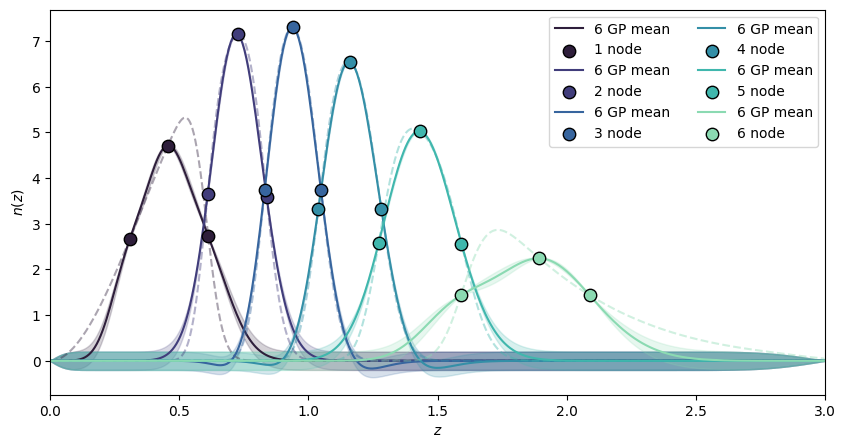

In [29]:
# GP reconstruction and plotting of results #

# Perform GP reconstruction #
priors, predictions = build_gp_nz(n_meds, nz_lows, nz_highs, z_meds, z_lows, z_highs, corr_len, z_bounds, z_pred, alpha, RBF, nu, const_value, const_bounds)

# Plot GP reconstruction results #
palette = sns.color_palette("mako", 6)
fig, ax = plt.subplots(figsize=(10, 5))

for j, nz in enumerate(n_meds):
    y_pred, y_std = predictions[j]
    X_train, y_train = [z_lows[j], z_meds[j], z_highs[j]], [nz_lows[j], n_meds[j], nz_highs[j]]

    ax.plot(z_pred, y_pred, color=palette[j], label=f"{key} GP mean")
    ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
                    color=palette[j], alpha=0.2)

    ax.plot(z_nz, nz_heracles[j+1], '--', color=palette[j], alpha=0.4)
    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$n(z)$")
ax.set_xlim(0, 3)
ax.legend(loc="upper right", ncol=2)
plt.show()


In [17]:
def resample_dndz_gp(gp_predictions, z_pred, zs):
    gp_predictions_norm = {}
    for key in gp_predictions.keys():
        gp_predictions_norm[key] = gp_predictions[key][0]/integrate.trapezoid(gp_predictions[key][0], z_pred[:,0])
    my_dndz = np.vstack(list(gp_predictions_norm.values())) 
    my_dndz_norm = np.zeros([len(gp_predictions_norm), len(zs)])
    for i in range(len(gp_predictions_norm)):
        # gp_predictions[i][0] is 1D array of n(z) for bin i

        my_dndz_norm[i, :] = np.interp(zs, z_pred[:,0], my_dndz[i, :])
    
    return my_dndz_norm

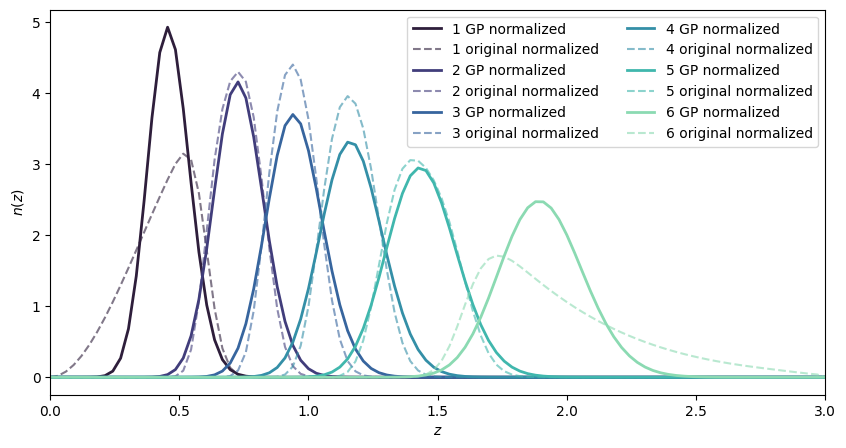

In [21]:
my_dndz_norm_gp = resample_dndz_gp(predictions, z_pred_res, myz)
palette = sns.color_palette("mako", 6)
fig, ax = plt.subplots(figsize=(10, 5))

for j, nz in enumerate(n_meds):
    y_pred, y_std = predictions[j]
    X_train, y_train = z_meds[j], n_meds[j]
    ax.plot(myz, my_dndz_norm_gp[j], color=palette[j],label=f"{j+1} GP normalized", linewidth=2)
    ax.plot(myz, my_dndz_she_norm[j], color=palette[j], alpha=0.6, linestyle='--', label=f"{j+1} original normalized")
#    ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
#                    color=palette[j], alpha=0.2)

#    ax.plot(z_nz, dndz_she_norm[j+1], '--', color=palette[j], alpha=0.4)
#    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$n(z)$")
ax.set_xlim(0, 3)
ax.legend(loc="upper right", ncol=2)
plt.show()


In [21]:
delta_x_all = []
for i in range(len(n_meds)):
    z_low = z_meds[i] - widths[i]/2
    z_high = z_meds[i] + widths[i]/2
    dx = (np.log1p(z_high) - np.log1p(z_low)) / np.log1p(z_bounds[1])
    delta_x_all.append(dx)

def build_gp_nz(n_med, z_med, corr_len, delta_x, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds):
    gp_priors = {}
    gp_predictions = {}
    for i, nz in enumerate(n_med):
        corr_len_scale = corr_len*delta_x[i]
        if kernel_class == Matern:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len_scale, nu=nu, length_scale_bounds="fixed")
        else:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len_scale, length_scale_bounds="fixed")
        gp = GaussianProcessRegressor(kernel=kernel, optimizer=None, normalize_y=False, alpha=alpha)
        X_train = np.array([np.log1p(z_bounds[0])/np.log1p(z_bounds[1]), np.log1p(z_med[i])/np.log1p(z_bounds[1]), np.log1p(z_bounds[1])/np.log1p(z_bounds[1])]).reshape(-1, 1)
        y_train = np.array([0.0, nz, 0.0])
        gp.fit(X_train, y_train)
        x_pred = np.log1p(z_pred)/np.log1p(z_bounds[1])
        x_pred = np.array(x_pred).reshape(-1, 1)
        y_pred, y_std = gp.predict(x_pred, return_std=True)
        gp_priors[i] = gp
        gp_predictions[i] = (y_pred, y_std)
    return gp_priors, gp_predictions

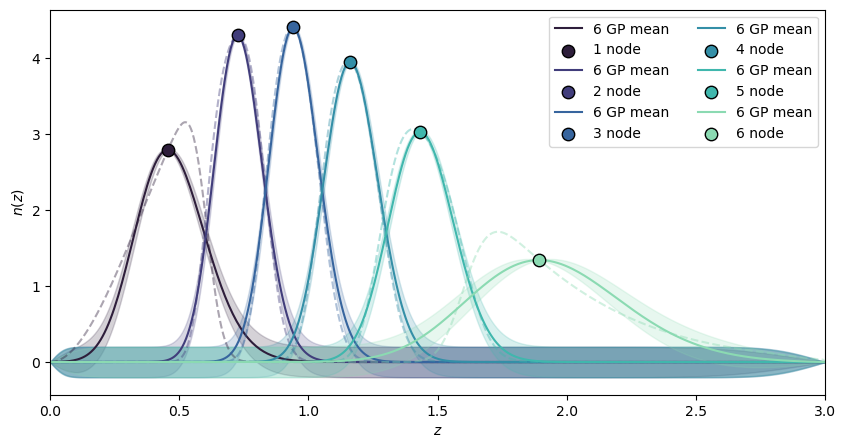

In [28]:
# Define a function to resample the reconstructed n(z) #

corr_len = 0.2

def resample_dndz_gp(gp_predictions, z_pred, zs):
    gp_predictions_norm = {}
    for key in gp_predictions.keys():
        gp_predictions_norm[key] = gp_predictions[key][0]/integrate.trapezoid(gp_predictions[key][0], z_pred[:,0])
    my_dndz = np.vstack(list(gp_predictions_norm.values())) 
    my_dndz_norm = np.zeros([len(gp_predictions_norm), len(zs)])
    for i in range(len(gp_predictions_norm)):
        # gp_predictions[i][0] is 1D array of n(z) for bin i

        my_dndz_norm[i, :] = np.interp(zs, z_pred[:,0], my_dndz[i, :])
    return my_dndz_norm

priors, predictions = build_gp_nz(n_meds, z_meds, corr_len, delta_x_all, z_bounds, z_pred, alpha, RBF, nu, const_value, const_bounds)

# Plot GP reconstruction results #
palette = sns.color_palette("mako", 6)
fig, ax = plt.subplots(figsize=(10, 5))

for j, nz in enumerate(n_meds):
    y_pred, y_std = predictions[j]
    X_train, y_train = z_meds[j], n_meds[j]

    ax.plot(z_pred, y_pred, color=palette[j], label=f"{key} GP mean")
    ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
                    color=palette[j], alpha=0.2)

    ax.plot(z_nz, dndz_she_norm[j+1], '--', color=palette[j], alpha=0.4)
    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$n(z)$")
ax.set_xlim(0, 3)
ax.legend(loc="upper right", ncol=2)
plt.show()

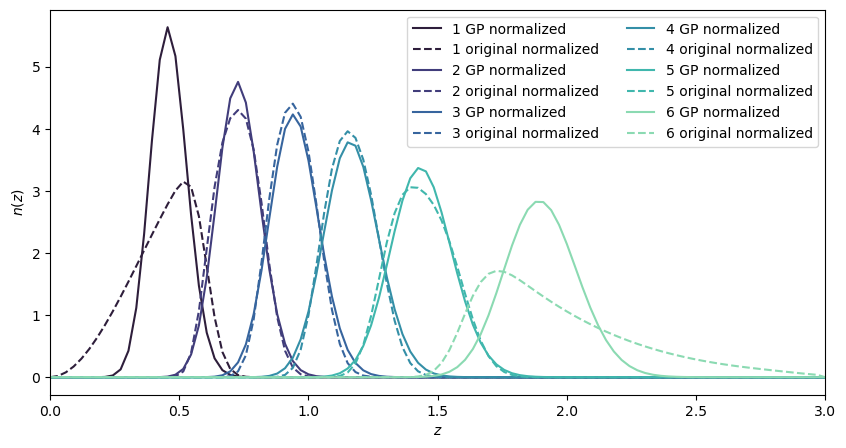

In [16]:
z_pred_res = z_pred.reshape(-1, 1)
predictions_sample = predictions.copy()
my_dndz_norm_gp = resample_dndz_gp(predictions_sample, z_pred_res, myz)
palette = sns.color_palette("mako", 6)
fig, ax = plt.subplots(figsize=(10, 5))

for j, nz in enumerate(n_meds):
    y_pred, y_std = predictions[j]
    X_train, y_train = z_meds[j], n_meds[j]
    ax.plot(myz, my_dndz_norm_gp[j], color=palette[j],label=f"{j+1} GP normalized")
    ax.plot(myz, my_dndz_she_norm[j], color=palette[j], linestyle='--', label=f"{j+1} original normalized")
#    ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
#                    color=palette[j], alpha=0.2)

#    ax.plot(z_nz, dndz_she_norm[j+1], '--', color=palette[j], alpha=0.4)
#    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$n(z)$")
ax.set_xlim(0, 3)
ax.legend(loc="upper right", ncol=2)
plt.show()

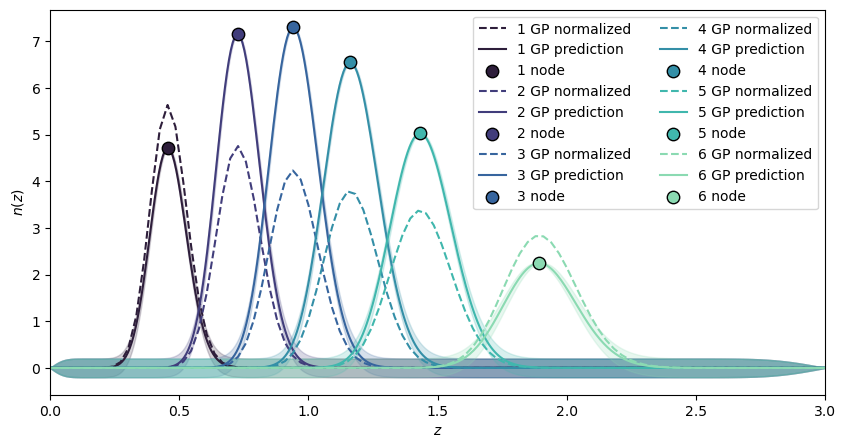

In [17]:
# Plotting the resampled GP n(z) together with original GP n(z) #

fig, ax = plt.subplots(figsize=(10, 5))

for j, nz in enumerate(n_meds):
    y_pred, y_std = predictions[j]
    X_train, y_train = z_meds[j], n_meds[j]
    ax.plot(myz, my_dndz_norm_gp[j], color=palette[j], linestyle='--',label=f"{j+1} GP normalized")
    ax.plot(z_pred, y_pred, color=palette[j], label=f"{j+1} GP prediction")
    ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
                    color=palette[j], alpha=0.2)

#    ax.plot(z_nz, dndz_she_norm[j+1], '--', color=palette[j], alpha=0.4)
    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")

ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$n(z)$")
ax.set_xlim(0, 3)
ax.legend(loc="upper right", ncol=2)


### 4. Sampling a single training node and the correlation length

In [15]:
# Set priors for sampled parameters (only Omega_cdm0 and H0) #

zmean_dr1 = np.array([0.4371, 0.726, 0.9424, 1.164, 1.437, 1.963])

# Set priors
prior_gp = Prior()
#prior.add_parameter('Omega_b0', dist=(0.01, 0.1))
#prior_gp.add_parameter('Omega_cdm0', dist=(0.1, 0.8))
#prior.add_parameter('logAs', dist=(np.log(0.6e-9*1e10), np.log(5e-9*1e10)))
#prior.add_parameter('ns', dist=(0.6, 1.2))
#prior_gp.add_parameter('H0', dist=(50, 90))
#prior.add_parameter('AIA', dist=(-1, 1))
#prior.add_parameter('EtaIA', dist=(-5, 5))
#prior.add_parameter('w0', dist=(-3.0, -0.5))
#prior.add_parameter('wa', dist=(-3.0, 3.0))
#prior.add_parameter('b1_photo_poly0', dist=(-3.0, 3.0))
#prior.add_parameter('b1_photo_poly1', dist=(-3.0, 3.0))
#prior.add_parameter('b1_photo_poly2', dist=(-3.0, 3.0))
#prior.add_parameter('b1_photo_poly3', dist=(-3.0, 3.0))
#prior.add_parameter('multiplicative_bias_1', norm(loc=0.0, scale=0.01))
#prior.add_parameter('multiplicative_bias_2', norm(loc=0.0, scale=0.01))
#prior.add_parameter('multiplicative_bias_3', norm(loc=0.0, scale=0.01))
#prior.add_parameter('multiplicative_bias_4', norm(loc=0.0, scale=0.01))
#prior.add_parameter('multiplicative_bias_5', norm(loc=0.0, scale=0.01))
#prior.add_parameter('multiplicative_bias_6', norm(loc=0.0, scale=0.01)) 
#prior.add_parameter('magnification_bias_1', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_2', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_3', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_4', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_5', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_6', dist=(-2.0, 2.0))
#prior.add_parameter('dz_pos_1', norm(loc=0.0, scale=0.002*(1+zmean_dr1[0])))
#prior.add_parameter('dz_pos_2', norm(loc=0.0, scale=0.002*(1+zmean_dr1[1])))
#prior.add_parameter('dz_pos_3', norm(loc=0.0, scale=0.002*(1+zmean_dr1[2])))
#prior.add_parameter('dz_pos_4', norm(loc=0.0, scale=0.002*(1+zmean_dr1[3])))
#prior.add_parameter('dz_pos_5', norm(loc=0.0, scale=0.002*(1+zmean_dr1[4])))
#prior.add_parameter('dz_pos_6', norm(loc=0.0, scale=0.002*(1+zmean_dr1[5])))
#prior.add_parameter('dz_shear_1', norm(loc=0.0, scale=0.002*(1+zmean_dr1[0])))
#prior.add_parameter('dz_shear_2', norm(loc=0.0, scale=0.002*(1+zmean_dr1[1])))
#prior.add_parameter('dz_shear_3', norm(loc=0.0, scale=0.002*(1+zmean_dr1[2])))
#prior.add_parameter('dz_shear_4', norm(loc=0.0, scale=0.002*(1+zmean_dr1[3])))
#prior.add_parameter('dz_shear_5', norm(loc=0.0, scale=0.002*(1+zmean_dr1[4])))
#prior.add_parameter('dz_shear_6', norm(loc=0.0, scale=0.002*(1+zmean_dr1[5])))
prior_gp.add_parameter('x1', dist= (0.2, 0.7))
prior_gp.add_parameter('corr_len', dist=(0.02, 0.1))

print("✨ Prior set up completed.")
print("Parameters sampled: ", prior_gp.keys)
print("Number of sampled parameters:", len(prior_gp.keys))

✨ Prior set up completed.
Parameters sampled:  ['x1', 'corr_len']
Number of sampled parameters: 2


In [ ]:

# Running the sampler #
# Here, we interrupt to save time #

default_pars = fiducial_cosmology | fiducial_nuisance
name_to_chain_gp = 'checkpoint_gp'

def like_Naut_test_gp(param_dict):
    # Enforce physical prior on w0 + wa
#    if param_dict['w0'] + param_dict['wa'] > -1. / 3:
#        return (-np.inf, 0)
    x1 = param_dict["x1"]
    l  = param_dict["corr_len"]
    z_meds[0] = x1
    priors_loop, predictions_loop = build_gp_nz(n_meds, z_meds, l, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)
    my_dndz_norm_gp_loop = resample_dndz_gp(predictions_loop, z_pred_res, myz)
    pars_in = default_pars.copy()
    pars_in.update(param_dict)
    #h = pars_in['H0'] / 100.0
    #pars_in['Omega_cdm0'] = param_dict['omch2'] / h**2
    #pars_in['Omega_b0'] = param_dict['ombh2'] / h**2
    #pars_in['As'] = np.exp(param_dict['logAs']) * 1e-10
    like_instance.data.update({'dndz_she': my_dndz_norm_gp_loop})
    return (like_instance.loglike(pars_in), like_instance.derived['sigma8_0'])

blob_vec     = [('sigma8_0', float)]

#if __name__ == '__main__':

#with get_context("spawn").Pool(10) as p:
sampler = Sampler(prior_gp, like_Naut_test_gp, 
        n_live=5000, 
        blobs_dtype=blob_vec,
            filepath=name_to_chain_gp + '.h5', 
            resume=True)
t_start = time.time()
print('Starting sampling...')
sampler.run(verbose=True)
t_end = time.time()
total_seconds = t_end - t_start
days = int(total_seconds // 86400)
hours = int((total_seconds % 86400) // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)
print(f'Total time: {days}d {hours}h {minutes}m {seconds}s')
print('Sampling finished!')
print('Saving chains...')

points, log_w, log_l, derived = sampler.posterior(return_blobs=True)

        # --- Sampled parameters ---
param_names = list(prior.keys)
chain_dict = {
            name: points[:, i]
            for i, name in enumerate(param_names)
        }

        # --- Derived parameters ---
derived_names = [name for name, _ in blob_vec]

derived_dict = {
            derived_names[0]: np.array([sample[0] for sample in derived])
        }

        # --- Save everything in a labelled way ---
np.savez_compressed(
            name_to_chain_gp + '.npz',
            chain=chain_dict,
            derived=derived_dict,
            weights=log_w,
            logl=log_l,
            param_names=param_names,
            derived_names=derived_names
        )

print('Chains saved with name:', name_to_chain_gp + '.npz')

Starting sampling...
Resuming nautilus run...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    


KeyboardInterrupt: 

### 5. Quick likelihood scan over cosmological and GP parameters


🔄 Scanning over Omega_cdm0


WL: 100%|███████████████████████████████████████| 50/50 [00:31<00:00,  1.59it/s]



🔄 Scanning over H0


WL: 100%|███████████████████████████████████████| 50/50 [00:37<00:00,  1.34it/s]



🔄 Scanning over x1


...

WL: 100%|███████████████████████████████████████| 50/50 [00:31<00:00,  1.60it/s]



🔄 Scanning over EtaIA


WL: 100%|███████████████████████████████████████| 50/50 [00:31<00:00,  1.57it/s]



🔄 Scanning over AIA


WL: 100%|███████████████████████████████████████| 50/50 [00:33<00:00,  1.49it/s]


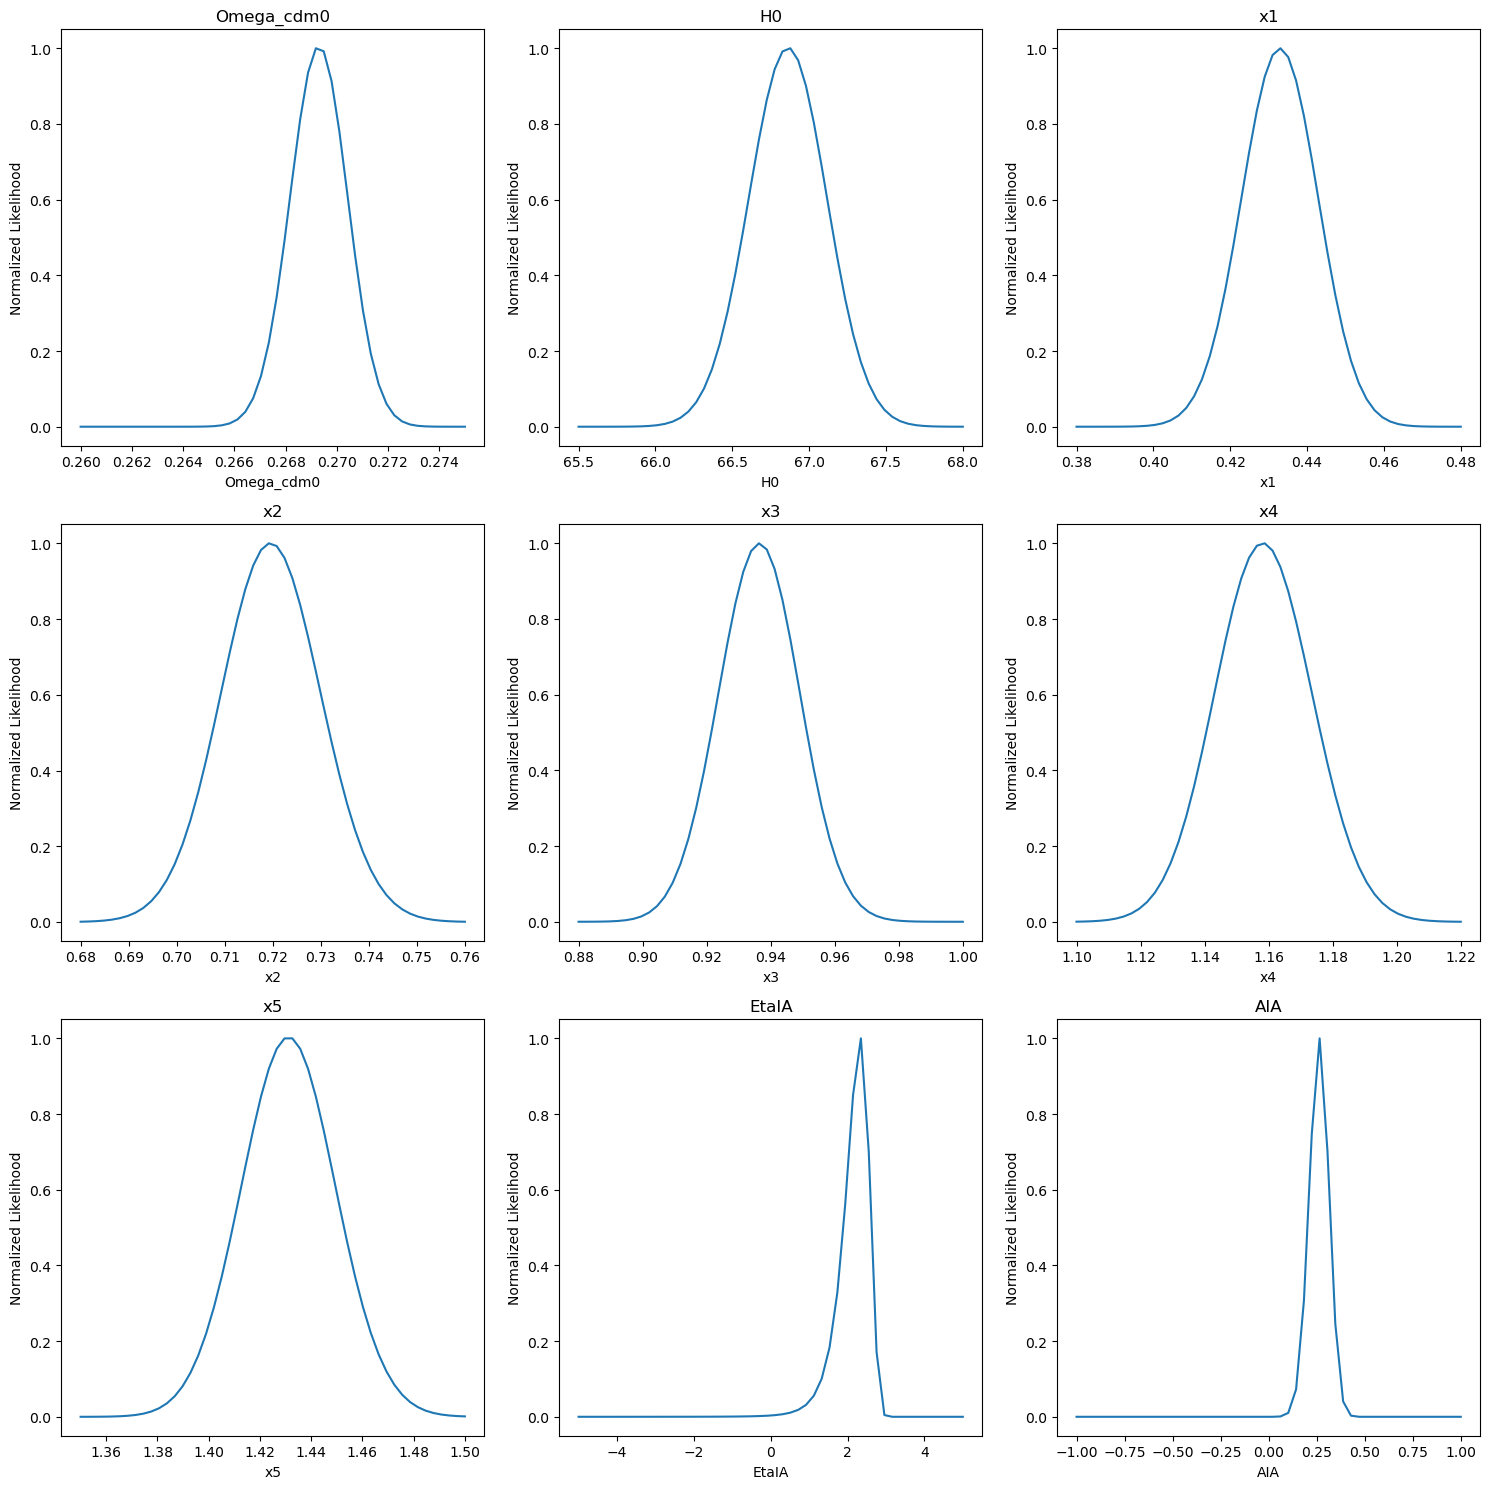

In [27]:
# Updating likelihood function to include all 6 bins #

from tqdm import tqdm

default_pars = fiducial_cosmology | fiducial_nuisance
def like_Naut_test_gp(param_dict):
    # Enforce physical prior on w0 + wa
#    if param_dict['w0'] + param_dict['wa'] > -1. / 3:
#        return (-np.inf, 0)
#    l  = param_dict["corr_len"]
    z_meds[0] = param_dict["x1"]
    z_meds[1] = param_dict["x2"]
    z_meds[2] = param_dict["x3"]
    z_meds[3] = param_dict["x4"]
    z_meds[4] = param_dict["x5"]
#    z_meds[5] = param_dict["x6"]
#    n_meds[0] = param_dict["y1"]
#    n_meds[1] = param_dict["y2"]
#    n_meds[2] = param_dict["y3"]
#    n_meds[3] = param_dict["y4"]
#    n_meds[4] = param_dict["y5"]
#    n_meds[5] = param_dict["y6"]
    priors_loop, predictions_loop = build_gp_nz(n_meds, z_meds, corr_len, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)
    my_dndz_norm_gp_loop = resample_dndz_gp(predictions_loop, z_pred_res, myz)
    pars_in = default_pars.copy()
    pars_in.update(param_dict)
    #h = pars_in['H0'] / 100.0
    #pars_in['Omega_cdm0'] = param_dict['omch2'] / h**2
    #pars_in['Omega_b0'] = param_dict['ombh2'] / h**2
    like_instance.data.update({'dndz_she': my_dndz_norm_gp_loop})
    return (like_instance.loglike(pars_in), like_instance.derived['sigma8_0'])

# Initializing parameter arrays and dictionaries #
fig, axes = plt.subplots(3,3, figsize=(15,15))
axes = axes.flatten()
oms = np.linspace(0.26, 0.275, 50)
H0s = np.linspace(65.5, 68, 50)
x1 = np.linspace(0.38, 0.48, 50)
x2 = np.linspace(0.68, 0.76, 50)
x3 = np.linspace(0.88, 1.0, 50)
x4 = np.linspace(1.1, 1.22, 50)
x5 = np.linspace(1.35, 1.5, 50)
x6 = np.linspace(1.81, 2.2, 50)
corr_len = 0.04
Eta_IA = np.linspace(-5, 5, 50)
AIA = np.linspace(-1,1, 50)
params = {'Omega_cdm0': oms, 'H0': H0s, 'x1': x1, 'x2': x2, 'x3': x3, 'x4': x4, 'x5': x5, 'EtaIA': Eta_IA, 'AIA': AIA}

fid_params = {'Omega_cdm0': fiducial_cosmology['Omega_cdm0'], 'H0': fiducial_cosmology['H0'],
              'x1': fiducial_gp['x1'], 'x2': fiducial_gp['x2'], 'x3': fiducial_gp['x3'],
              'x4': fiducial_gp['x4'], 'x5': fiducial_gp['x5'], 'EtaIA': fiducial_nuisance['EtaIA'], 
              'AIA': fiducial_nuisance['AIA']}
keys = ['Omega_cdm0', 'H0', 'x1', 'x2', 'x3', 'x4', 'x5', 'EtaIA', 'AIA']

# Scanning and plotting #
for key, ax in zip(keys, axes):
    print(f"\n🔄 Scanning over {key}")
    likelihood_curve = []
    dict = fid_params.copy()
    for value in tqdm(params[key], desc=f"WL", ncols=80):
        dict.update({key: value})
        ll = like_Naut_test_gp(dict)[0]
        likelihood_curve.append(ll)
    
    # Convert log-likelihoods to likelihoods (exp) and normalize
    likelihood_curve = np.exp(likelihood_curve - np.max(likelihood_curve))
    
    # Plot
    ax.plot(params[key], likelihood_curve, label='Cosmic shear')
    ax.set_title(key)
    ax.set_xlabel(key)
    ax.set_ylabel('Normalized Likelihood')

plt.tight_layout()
plt.savefig("/home/jipdebuck/plots/likelihood_scan_IA.pdf", bbox_inches='tight')
plt.show()

### 6. Visualizing the pipeline

We want to visualize the pipeline by extracting sampled parameters, plotting sampled $n(z)$'s and $C_{\ell}$'s, and comparing with the original $C_{\ell}$'s. We are doing this for a shear-only $\Lambda$ CDM GP chain.

In [18]:
# Defining the priors #

prior_gp = Prior()
prior_gp.add_parameter('Omega_b0', dist=(0.01, 0.1))
prior_gp.add_parameter('Omega_cdm0', dist=(0.1, 0.8))
prior_gp.add_parameter('logAs', dist=(np.log(0.6e-9*1e10), np.log(5e-9*1e10)))
prior_gp.add_parameter('ns', dist=(0.6, 1.2))
prior_gp.add_parameter('H0', dist=(50, 90))
prior_gp.add_parameter('AIA', dist=(-1, 1))
prior_gp.add_parameter('EtaIA', dist=(-5, 5))
#prior_gp.add_parameter('w0', dist=(-3.0, -0.5))
#prior_gp.add_parameter('wa', dist=(-3.0, 3.0))
#prior_gp.add_parameter('b1_photo_poly0', dist=(-3.0, 3.0))
#prior_gp.add_parameter('b1_photo_poly1', dist=(-3.0, 3.0))
#prior_gp.add_parameter('b1_photo_poly2', dist=(-3.0, 3.0))
#prior_gp.add_parameter('b1_photo_poly3', dist=(-3.0, 3.0))
prior_gp.add_parameter('multiplicative_bias_1', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_2', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_3', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_4', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_5', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_6', norm(loc=0.0, scale=0.01)) 
#prior.add_parameter('magnification_bias_1', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_2', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_3', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_4', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_5', dist=(-2.0, 2.0))
#prior.add_parameter('magnification_bias_6', dist=(-2.0, 2.0))
#prior.add_parameter('dz_pos_1', norm(loc=0.0, scale=0.002*(1+zmean_dr1[0])))
#prior.add_parameter('dz_pos_2', norm(loc=0.0, scale=0.002*(1+zmean_dr1[1])))
#prior.add_parameter('dz_pos_3', norm(loc=0.0, scale=0.002*(1+zmean_dr1[2])))
#prior.add_parameter('dz_pos_4', norm(loc=0.0, scale=0.002*(1+zmean_dr1[3])))
#prior.add_parameter('dz_pos_5', norm(loc=0.0, scale=0.002*(1+zmean_dr1[4])))
#prior.add_parameter('dz_pos_6', norm(loc=0.0, scale=0.002*(1+zmean_dr1[5])))
#prior.add_parameter('dz_shear_1', norm(loc=0.0, scale=0.002*(1+zmean_dr1[0])))
#prior.add_parameter('dz_shear_2', norm(loc=0.0, scale=0.002*(1+zmean_dr1[1])))
#prior.add_parameter('dz_shear_3', norm(loc=0.0, scale=0.002*(1+zmean_dr1[2])))
#prior.add_parameter('dz_shear_4', norm(loc=0.0, scale=0.002*(1+zmean_dr1[3])))
#prior.add_parameter('dz_shear_5', norm(loc=0.0, scale=0.002*(1+zmean_dr1[4])))
#prior.add_parameter('dz_shear_6', norm(loc=0.0, scale=0.002*(1+zmean_dr1[5])))
prior_gp.add_parameter('x1', dist= (z_lows[0], z_highs[0]))
prior_gp.add_parameter('x2', dist= (z_lows[1], z_highs[1]))
prior_gp.add_parameter('x3', dist= (z_lows[2], z_highs[2]))
prior_gp.add_parameter('x4', dist= (z_lows[3], z_highs[3]))
prior_gp.add_parameter('x5', dist= (z_lows[4], z_highs[4]))
prior_gp.add_parameter('x6', dist= (z_lows[5], z_highs[5]))
prior_gp.add_parameter('y1', dist= (3, 6))
prior_gp.add_parameter('y2', dist= (5.5, 8.5))
prior_gp.add_parameter('y3', dist= (5.5, 8.5))
prior_gp.add_parameter('y4', dist= (4.5, 7.5))
prior_gp.add_parameter('y5', dist= (3, 6))
prior_gp.add_parameter('y6', dist= (0.4, 3.4))
prior_gp.add_parameter('corr_len', dist=(0.02, 0.1))

print("✨ Prior set up completed.")
print("Parameters sampled: ", prior_gp.keys)
print("Number of sampled parameters:", len(prior_gp.keys))
default_pars = fiducial_cosmology | fiducial_nuisance

✨ Prior set up completed.
Parameters sampled:  ['Omega_b0', 'Omega_cdm0', 'logAs', 'ns', 'H0', 'AIA', 'EtaIA', 'multiplicative_bias_1', 'multiplicative_bias_2', 'multiplicative_bias_3', 'multiplicative_bias_4', 'multiplicative_bias_5', 'multiplicative_bias_6', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y1', 'y2', 'y3', 'y4', 'y5', 'y6', 'corr_len']
Number of sampled parameters: 26


In [29]:
# Defining the likelihood function #

step_counter = 0 
def like_Naut_test_gp(param_dict):
    global step_counter
    # Enforce physical prior on w0 + wa
#    if param_dict['w0'] + param_dict['wa'] > -1. / 3:
#        return (-np.inf, 0)
    l  = param_dict["corr_len"]
    z_meds[0] = param_dict["x1"]
    z_meds[1] = param_dict["x2"]
    z_meds[2] = param_dict["x3"]
    z_meds[3] = param_dict["x4"]
    z_meds[4] = param_dict["x5"]
    z_meds[5] = param_dict["x6"]
    n_meds[0] = param_dict["y1"]
    n_meds[1] = param_dict["y2"]
    n_meds[2] = param_dict["y3"]
    n_meds[3] = param_dict["y4"]
    n_meds[4] = param_dict["y5"]
    n_meds[5] = param_dict["y6"]
    priors_loop, predictions_loop = build_gp_nz(n_meds, z_meds, l, z_bounds, z_pred, alpha, RBF, nu, const_value, const_bounds)
    my_dndz_norm_gp_loop = resample_dndz_gp(predictions_loop, z_pred_res, myz)
    pars_in = default_pars.copy()
    pars_in.update(param_dict)
    #h = pars_in['H0'] / 100.0
    #pars_in['Omega_cdm0'] = param_dict['omch2'] / h**2
    #pars_in['Omega_b0'] = param_dict['ombh2'] / h**2
    pars_in['As'] = np.exp(param_dict['logAs']) * 1e-10
    like_instance.data.update({'dndz_she': my_dndz_norm_gp_loop})
    ll = like_instance.loglike(pars_in)
    step = {"params": param_dict.copy(), "dndz": predictions_loop.copy(), "dndz_norm": my_dndz_norm_gp_loop.copy(), "loglike": ll, "C_ell": like_instance.theory_prediction}
    np.save(f"/home/jipdebuck/files/gp_sampling_step_{step_counter}.npy", step)
    step_counter += 1
    return (ll, like_instance.derived['sigma8_0'])

In [30]:
# Running the sampler #
blob_vec = [('sigma8_0', float)]
sampler = Sampler(prior_gp, like_Naut_test_gp, 
        n_live=10000, 
        blobs_dtype=blob_vec,
            filepath= 'steps.h5', 
            resume=True)
t_start = time.time()
print('Starting sampling...')
sampler.run(verbose=True)
t_end = time.time()
total_seconds = t_end - t_start
days = int(total_seconds // 86400)
hours = int((total_seconds % 86400) // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)
print(f'Total time: {days}d {hours}h {minutes}m {seconds}s')
print('Sampling finished!')
print('Saving chains...')

points, log_w, log_l, derived = sampler.posterior(return_blobs=True)

        # --- Sampled parameters ---
param_names = list(prior_gp.keys)
chain_dict = {
            name: points[:, i]
            for i, name in enumerate(param_names)
        }

        # --- Derived parameters ---
derived_names = [name for name, _ in blob_vec]

derived_dict = {
            derived_names[0]: np.array([sample[0] for sample in derived])
        }

        # --- Save everything in a labelled way ---
np.savez_compressed(
            'gp_v2.npz',
            chain=chain_dict,
            derived=derived_dict,
            weights=log_w,
            logl=log_l,
            param_names=param_names,
            derived_names=derived_names
        )

print('Chains saved with name:', name_to_chain_gp + '.npz')

Starting sampling...
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    


/home/jipdebuck/miniconda3/envs/venv_310/lib/python3.10/site-packages/cosmopower/cosmopower_NN.py:378: RuntimeWarning: overflow encountered in exp
  layers.append((self.betas_[i] + (1.-self.betas_[i])*1./(1.+np.exp(-self.alphas_[i]*act[-1])))*act[-1])


KeyboardInterrupt: 

In [19]:
i_lows_pos = {}
i_highs_pos = {}
for key, nz in dndz_pos_norm.items():
    nz_max = np.max(nz)
    mask = np.where(nz > 0.5 * nz_max)[0]
    i_lows_pos.update({key: mask[0]})
    i_highs_pos.update({key: mask[-1]})
z_lows_pos = z_nz[[i_lows_pos[key] for key in dndz_pos_norm.keys()]]
z_highs_pos = z_nz[[i_highs_pos[key] for key in dndz_pos_norm.keys()]]

i_lows_she = {}
i_highs_she = {}
for key, nz in dndz_she_norm.items():
    nz_max = np.max(nz)
    mask = np.where(nz > 0.5 * nz_max)[0]
    i_lows_she.update({key: mask[0]})
    i_highs_she.update({key: mask[-1]})
z_lows_she = z_nz[[i_lows_she[key] for key in dndz_she_norm.keys()]]
z_highs_she = z_nz[[i_highs_she[key] for key in dndz_she_norm.keys()]]


# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values())) #stacking arrays vertically
    my_dndz_norm = np.zeros([len(nz_example), len(myz)]) #creating an empty array
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :]) #interpolating to new myz values
    return my_dndz_norm

my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, myz)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, myz)

z_meds_she = []   # positions of median redshift for each bin
n_meds_she = []   # height of n(z) at median redshift for each bin
z_meds_pos = []
n_meds_pos = []

for key, nz in dndz_she_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med = np.interp(0.5, cdf, z_nz)
    n_med = nz[np.argmin(np.abs(z_nz - z_med))]
    z_meds_she.append(z_med)
    n_meds_she.append(n_med)
    
for key, nz in dndz_pos_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med_pos = np.interp(0.5, cdf, z_nz)
    n_med_pos = nz[np.argmin(np.abs(z_nz - z_med_pos))]
    z_meds_pos.append(z_med_pos)
    n_meds_pos.append(n_med_pos)
    
print('z_meds_she:', z_meds_she)
print('n_meds_she:', n_meds_she)
print('z_meds_pos:', z_meds_pos)
print('n_meds_pos:', n_meds_pos)

corr_len = 0.04                              # correlation length for the GP kernel
z_bounds = (0,3)                              # bounds for the redshift
z_pred = np.linspace(0, 3, 400)       # prediction points for GP
alpha = 1e-8                                  # noise level during fitting 
kernel_class = RBF
nu = 1.5                                      # necessary for Matern only, defines smoothness 
const_value = 0.04                            # amplitude of constant kernel
const_bounds = (1e-4, 1.0)                    # bounds for constant kernel amplitude
# We read with euclidlib v2025.2 (v2025.1 is also compatible)
z_pred_res = z_pred.reshape(-1, 1)
widths_she = np.array([z_highs_she[0]-z_lows_she[0], z_highs_she[1]-z_lows_she[1], z_highs_she[2]-z_lows_she[2], z_highs_she[3]-z_lows_she[3], z_highs_she[4]-z_lows_she[4], z_highs_she[5]-z_lows_she[5]])
widths_pos = np.array([z_highs_pos[0]-z_lows_pos[0], z_highs_pos[1]-z_lows_pos[1], z_highs_pos[2]-z_lows_pos[2], z_highs_pos[3]-z_lows_pos[3], z_highs_pos[4]-z_lows_pos[4], z_highs_pos[5]-z_lows_pos[5]])
name_to_chain_gp = '3x2pt_LCDM_DR1_GP_ELR'

#cells_data = el.photo.harmonic_space.angular_power_spectra('/disks/shear16/canasherrera/SheariouslyCalibrated/data/DR1/synthetic_angular_spectra_DR1.fits')

fiducial_cosmology = {
    'H0': 67,                # Hubble constant
    'Omega_cdm0': 0.27,        # Cold dark matter density
    'Omega_b0': 0.049,         # Baryon density
    'Omega_k0': 0.0,           # Curvature
    'mnu': 0.077,                # Neutrino mass
    'w0': -1.0,                # Dark energy equation of state (present)
    'wa': 0.0,                 # Dark energy equation of state (evolution)
    'ns': 0.96,                # Scalar spectral index
    'As': 2.1e-9, # Scalar amplitude
    'gamma_MG': 0.545,         # Modified gravity parameter
    'log10TAGN': 7.75,          # AGN feedback parameter
    'N_mnu': 1,                  # Number of massive neutrino species
    'N_eff': 3.046             # Effective number of relativistic species
}

fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    # Magnification bias (per bin)
    'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
    'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
    'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
    'magnification_bias_7': 0.0, 'magnification_bias_8': 0.0,
    'magnification_bias_9': 0.0, 'magnification_bias_10': 0.0,
    'magnification_bias_11': 0.0, 'magnification_bias_12': 0.0,
    'magnification_bias_13': 0.0,
    # Redshift errors (positions)
    'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 
    'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
    'dz_pos_7': 0.0, 'dz_pos_8': 0.0, 'dz_pos_9': 0.0, 
    'dz_pos_10': 0.0, 'dz_pos_11': 0.0, 'dz_pos_12': 0.0,
    'dz_pos_13': 0.0,
    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
    'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
    'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
    'multiplicative_bias_7': 0.0, 'multiplicative_bias_8': 0.0,
    'multiplicative_bias_9': 0.0, 'multiplicative_bias_10': 0.0,
    'multiplicative_bias_11': 0.0, 'multiplicative_bias_12': 0.0,
    'multiplicative_bias_13': 0.0,
    # Redshift errors (shear)
    'dz_shear_1': 0.0, 'dz_shear_2': 0.0, 'dz_shear_3': 0.0,
    'dz_shear_4': 0.0, 'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
    'dz_shear_7': 0.0, 'dz_shear_8': 0.0, 'dz_shear_9': 0.0, 
    'dz_shear_10': 0.0, 'dz_shear_11': 0.0, 'dz_shear_12': 0.0,
    'dz_shear_13': 0.0
}

ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])

# --- Cosmology and Tracers: Easy to Change! ---

# Choose which perturbation model to use: 'linear' or 'nonlinear'
perturbation_model = 'nonlinear'  # change to 'linear' if needed

# Cosmology parameters (easy to modify)
cosmo_params = fiducial_cosmology.copy()
nuisance_params = fiducial_nuisance.copy()

# Create background
background = CAMBBackground(
    H0=cosmo_params['H0'],
    Omega_cdm0=cosmo_params['Omega_cdm0'],
    Omega_b0=cosmo_params['Omega_b0'],
    w0=cosmo_params['w0'],
    wa=cosmo_params['wa'],
    Omega_k0=cosmo_params['Omega_k0'],
    ns=cosmo_params['ns'],
    As=cosmo_params['As'],
    mnu=cosmo_params['mnu'],
    gamma_MG=cosmo_params['gamma_MG'],
    N_mnu=cosmo_params['N_mnu']
)

# Choose perturbations
if perturbation_model == 'linear':
    perturbations = HMemuLinearPerturbations(background, myz)
else:
    perturbations = HMemuNonLinearPerturbations(
        background, 
        HMemuLinearPerturbations(background, myz), 
        myz, 
        log10TAGN=cosmo_params['log10TAGN']
    )

def resample_dndz_gp(gp_predictions, z_pred, zs):
#    gp_predictions_norm = {}
#    for key in gp_predictions.keys():
#        gp_predictions_norm[key] = gp_predictions[key][0]/integrate.trapezoid(gp_predictions[key][0], z_pred[:,0])
    my_dndz = np.vstack([gp_predictions[i][0] for i in sorted(gp_predictions.keys())]) 
    my_dndz_norm = np.zeros([len(gp_predictions), len(zs)])
    for i in range(len(gp_predictions)):
        # gp_predictions[i][0] is 1D array of n(z) for bin i

        my_dndz_norm[i, :] = np.interp(zs, z_pred[:,0], my_dndz[i, :])
    
    return my_dndz_norm

tracer_pos = PositionsTracer(
    perturbations=perturbations,
    dndz=my_dndz_pos_norm,
    z=myz,
    galaxy_bias_model='poly',
    nuisance_params=nuisance_params
)

tracer_she = ShearTracer(
    perturbations=perturbations,
    dndz=my_dndz_she_norm,
    z=myz,
    nuisance_params=nuisance_params
)


cls_sheshe = AngularTwoPoint(tracer_she, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_posshe = AngularTwoPoint(tracer_pos, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_pospos = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl(ell_theory, 0, perturbations.k)
#print(cls_sheshe[('SHE', 'SHE', 1,1)], len(ell_theory))

# Combine all spectra into a single dictionary for easy access
uncoupled_cls = {**cls_posshe, **cls_sheshe, **cls_pospos}

def build_data(cls, mapa_key, cov, zs, nzs, include_pos=False, include_she=False):
    data = {
        'cells': cls,
        'ells': cls[mapa_key].ell,
        'z_arr': zs,
        'cov': cov,
        'mixmat': {},
    }
    if include_pos:
        data['dndz_pos'] = nzs[0]
    if include_she:
        data['dndz_she'] = nzs[1]
    return data

def build_settings(cls):
    for key in cls:
        if key[:2] == ('POS', 'POS'):
            scale_cuts = {key: [10, 750] for key in cls}
        else:
            scale_cuts = {key: [10, 1500] for key in cls}
    return {'n_ell_bins': 32, 'scale_cuts': scale_cuts}

data_3x2pt = build_data(uncoupled_cls, ('SHE', 'SHE', 1, 1), 
                             full_cov, 
                             myz, [my_dndz_pos_norm, my_dndz_she_norm],
                             include_pos=True, include_she=True)
settings_3x2pt  = build_settings(uncoupled_cls)

like_instance = EuclidLikelihood_3x2pt(
        data=data_3x2pt,
        settings=settings_3x2pt,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
        mode="uncoupled"

    )

loglike = like_instance.loglike(fiducial_cosmology | fiducial_nuisance)
print("✨ Log-likelihood at fiducial: ", loglike)


# Priors
zmean_dr1 = np.array([0.4371, 0.726, 0.9424, 1.164, 1.437, 1.963])

prior_gp = Prior()
prior_gp.add_parameter('Omega_b0', dist=(0.01, 0.1))
prior_gp.add_parameter('Omega_cdm0', dist=(0.1, 0.8))
prior_gp.add_parameter('logAs', dist=(np.log(0.6e-9*1e10), np.log(5e-9*1e10)))
prior_gp.add_parameter('ns', dist=(0.6, 1.2))
prior_gp.add_parameter('H0', dist=(50, 90))
prior_gp.add_parameter('AIA', dist=(-1, 1))
prior_gp.add_parameter('EtaIA', dist=(-5, 5))
#prior_gp.add_parameter('w0', dist=(-3.0, -0.5))
#prior_gp.add_parameter('wa', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly0', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly1', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly2', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly3', dist=(-3.0, 3.0))
prior_gp.add_parameter('multiplicative_bias_1', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_2', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_3', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_4', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_5', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_6', norm(loc=0.0, scale=0.01)) 
prior_gp.add_parameter('magnification_bias_1', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_2', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_3', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_4', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_5', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_6', dist=(-2.0, 2.0))
#prior.add_parameter('dz_pos_1', norm(loc=0.0, scale=0.002*(1+zmean_dr1[0])))
#prior.add_parameter('dz_pos_2', norm(loc=0.0, scale=0.002*(1+zmean_dr1[1])))
#prior.add_parameter('dz_pos_3', norm(loc=0.0, scale=0.002*(1+zmean_dr1[2])))
#prior.add_parameter('dz_pos_4', norm(loc=0.0, scale=0.002*(1+zmean_dr1[3])))
#prior.add_parameter('dz_pos_5', norm(loc=0.0, scale=0.002*(1+zmean_dr1[4])))
#prior.add_parameter('dz_pos_6', norm(loc=0.0, scale=0.002*(1+zmean_dr1[5])))
#prior.add_parameter('dz_shear_1', norm(loc=0.0, scale=0.002*(1+zmean_dr1[0])))
#prior.add_parameter('dz_shear_2', norm(loc=0.0, scale=0.002*(1+zmean_dr1[1])))
#prior.add_parameter('dz_shear_3', norm(loc=0.0, scale=0.002*(1+zmean_dr1[2])))
#prior.add_parameter('dz_shear_4', norm(loc=0.0, scale=0.002*(1+zmean_dr1[3])))
#prior.add_parameter('dz_shear_5', norm(loc=0.0, scale=0.002*(1+zmean_dr1[4])))
#prior.add_parameter('dz_shear_6', norm(loc=0.0, scale=0.002*(1+zmean_dr1[5])))
prior_gp.add_parameter('x1_she', norm(loc=z_meds_she[0], scale=0.002*(1+z_meds_she[0])))
prior_gp.add_parameter('x2_she', norm(loc=z_meds_she[1], scale=0.002*(1+z_meds_she[1])))
prior_gp.add_parameter('x3_she', norm(loc=z_meds_she[2], scale=0.002*(1+z_meds_she[2])))
prior_gp.add_parameter('x4_she', norm(loc=z_meds_she[3], scale=0.002*(1+z_meds_she[3])))
prior_gp.add_parameter('x5_she', norm(loc=z_meds_she[4], scale=0.002*(1+z_meds_she[4])))
prior_gp.add_parameter('x6_she', norm(loc=z_meds_she[5], scale=0.002*(1+z_meds_she[5])))
#prior_gp.add_parameter('y1_she', norm(loc=z_meds_she[0], scale=0.002*(1+z_meds_she[0])))
#prior_gp.add_parameter('y2_she', norm(loc=z_meds_she[0], scale=0.002*(1+z_meds_she[0])))
#prior_gp.add_parameter('y3_she', dist= (n_meds_she[2]-1, n_meds_she[2]+1))
#prior_gp.add_parameter('y4_she', dist= (n_meds_she[3]-1, n_meds_she[3]+1))
#prior_gp.add_parameter('y5_she', dist= (n_meds_she[4]-1, n_meds_she[4]+1))
#prior_gp.add_parameter('y6_she', dist= (n_meds_she[5]-1, n_meds_she[5]+1))
prior_gp.add_parameter('log_l_she', dist=(np.log(0.001), np.log(1)))
prior_gp.add_parameter('x1_pos', norm(loc=z_meds_pos[0], scale=0.002*(1+z_meds_pos[0])))
prior_gp.add_parameter('x2_pos', norm(loc=z_meds_pos[1], scale=0.002*(1+z_meds_pos[1])))
prior_gp.add_parameter('x3_pos', norm(loc=z_meds_pos[2], scale=0.002*(1+z_meds_pos[2])))
prior_gp.add_parameter('x4_pos', norm(loc=z_meds_pos[3], scale=0.002*(1+z_meds_pos[3])))
prior_gp.add_parameter('x5_pos', norm(loc=z_meds_pos[4], scale=0.002*(1+z_meds_pos[4])))
prior_gp.add_parameter('x6_pos', norm(loc=z_meds_pos[5], scale=0.002*(1+z_meds_pos[5])))
#prior_gp.add_parameter('y1_pos', dist= (n_meds_pos[0]-1, n_meds_pos[0]+1))
#prior_gp.add_parameter('y2_pos', dist= (n_meds_pos[1]-1, n_meds_pos[1]+1))
#prior_gp.add_parameter('y3_pos', dist= (n_meds_pos[2]-1, n_meds_pos[2]+1))
#rior_gp.add_parameter('y4_pos', dist= (n_meds_pos[3]-1, n_meds_pos[3]+1))
#prior_gp.add_parameter('y5_pos', dist= (n_meds_pos[4]-1, n_meds_pos[4]+1))
#rior_gp.add_parameter('y6_pos', dist= (n_meds_pos[5]-1, n_meds_pos[5]+1))
prior_gp.add_parameter('log_l_pos', dist=(np.log(0.001), np.log(1)))

def build_gp_nz(n_med, z_med, corr_len, widths, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds):
    gp_priors = {}
    gp_predictions = {}
    for i, nz in enumerate(n_med):
        corr_len_scale = corr_len*(widths[i]/np.max(widths))
        if kernel_class == Matern:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len_scale, nu=nu, length_scale_bounds="fixed")
        else:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len_scale, length_scale_bounds="fixed")
        gp = GaussianProcessRegressor(kernel=kernel, optimizer=None, normalize_y=False, alpha=alpha)
        X_train = np.array([z_bounds[0]/z_bounds[1], z_med[i]/z_bounds[1], z_bounds[1]/z_bounds[1]]).reshape(-1, 1)
        y_train = np.array([0.0, nz, 0.0])
        gp.fit(X_train, y_train)
        x_pred = z_pred/z_bounds[1]
        x_pred = np.array(x_pred).reshape(-1, 1)
        y_pred, y_std = gp.predict(x_pred, return_std=True)
        gp_priors[i] = gp
        gp_predictions[i] = (y_pred, y_std)
    return gp_priors, gp_predictions

print("✨ Prior set up completed.")
print("Parameters sampled: ", prior_gp.keys)
print("Number of sampled parameters:", len(prior_gp.keys))
default_pars = fiducial_cosmology | fiducial_nuisance

step_counter = 0
def like_Naut_test_gp(param_dict):
    global step_counter
    # Enforce physical prior on w0 + wa
#    if param_dict['w0'] + param_dict['wa'] > -1. / 3:
#        return (-np.inf, 0)
    l_she  = np.exp(param_dict["log_l_she"])
    z_meds_she_new = np.zeros(6)
    z_meds_she_new[0] = param_dict["x1_she"]
    z_meds_she_new[1] = param_dict["x2_she"]
    z_meds_she_new[2] = param_dict["x3_she"]
    z_meds_she_new[3] = param_dict["x4_she"]
    z_meds_she_new[4] = param_dict["x5_she"]
    z_meds_she_new[5] = param_dict["x6_she"]
#    if z_meds_she[0] >= z_meds_she[1] or z_meds_she[1] >= z_meds_she[2] or z_meds_she[2] >= z_meds_she[3] or z_meds_she[3] >= z_meds_she[4] or z_meds_she[4] >= z_meds_she[5]:
#        return (-np.inf, 0)
#    n_meds_she[0] = param_dict["y1_she"]
#    n_meds_she[1] = param_dict["y2_she"]
#    n_meds_she[2] = param_dict["y3_she"]
#    n_meds_she[3] = param_dict["y4_she"]
#    n_meds_she[4] = param_dict["y5_she"]
#    n_meds_she[5] = param_dict["y6_she"]
    l_pos  = np.exp(param_dict["log_l_pos"])
    z_meds_pos_new = np.zeros(6)
    z_meds_pos_new[0] = param_dict["x1_pos"]
    z_meds_pos_new[1] = param_dict["x2_pos"]
    z_meds_pos_new[2] = param_dict["x3_pos"]
    z_meds_pos_new[3] = param_dict["x4_pos"]
    z_meds_pos_new[4] = param_dict["x5_pos"]
    z_meds_pos_new[5] = param_dict["x6_pos"]
#    if z_meds_pos[0] >= z_meds_pos[1] or z_meds_pos[1] >= z_meds_pos[2] or z_meds_pos[2] >= z_meds_pos[3] or z_meds_pos[3] >= z_meds_pos[4] or z_meds_pos[4] >= z_meds_pos[5]:
#        return (-np.inf, 0)
#    n_meds_pos[0] = param_dict["y1_pos"]
#    n_meds_pos[1] = param_dict["y2_pos"]
#    n_meds_pos[2] = param_dict["y3_pos"]
#    n_meds_pos[3] = param_dict["y4_pos"]
#    n_meds_pos[4] = param_dict["y5_pos"]
#    n_meds_pos[5] = param_dict["y6_pos"]
    priors_she, predictions_she = build_gp_nz(n_meds_she, z_meds_she_new, l_she, widths_she, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)
    my_dndz_norm_gp_she = resample_dndz_gp(predictions_she, z_pred_res, myz)
    priors_pos, predictions_pos = build_gp_nz(n_meds_pos, z_meds_pos_new, l_pos, widths_pos, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)
    my_dndz_norm_gp_pos = resample_dndz_gp(predictions_pos, z_pred_res, myz)
    pars_in = default_pars.copy()
    pars_in.update(param_dict)
    #h = pars_in['H0'] / 100.0
    #pars_in['Omega_cdm0'] = param_dict['omch2'] / h**2
    #pars_in['Omega_b0'] = param_dict['ombh2'] / h**2
    pars_in['As'] = np.exp(param_dict['logAs']) * 1e-10
    like_instance.data.update({'dndz_she': my_dndz_norm_gp_she, 'dndz_pos': my_dndz_norm_gp_pos})
    ll = like_instance.loglike(pars_in)
    step = {"params": param_dict.copy(), "dndz": predictions_she.copy(), "dndz_norm": my_dndz_norm_gp_she.copy(), "loglike": ll, "C_ell": like_instance.theory_prediction}
    np.save(f"/home/jipdebuck/files/3x2pt/gp_sampling_step_{step_counter}.npy", step)
    step_counter += 1
    return (like_instance.loglike(pars_in), like_instance.derived['sigma8_0'])

blob_vec     = [('sigma8_0', float)]
sampler = Sampler(prior_gp, like_Naut_test_gp, 
                              n_live=5000, 
                              blobs_dtype=blob_vec,
                              filepath=name_to_chain_gp + '.h5', 
            resume=True)
t_start = time.time()
print('Starting sampling...')
sampler.run(verbose=True)
t_end = time.time()
total_seconds = t_end - t_start
days = int(total_seconds // 86400)
hours = int((total_seconds % 86400) // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)
print(f'Total time: {days}d {hours}h {minutes}m {seconds}s')
print('Sampling finished!')
print('Saving chains...')

points, log_w, log_l, derived = sampler.posterior(return_blobs=True)
        
log_z = sampler.log_z

        # --- Sampled parameters ---
param_names = list(prior_gp.keys)
chain_dict = {
            name: points[:, i]
            for i, name in enumerate(param_names)
        }

        # --- Derived parameters ---
derived_names = [name for name, _ in blob_vec]

derived_dict = {
            derived_names[0]: np.array([sample[0] for sample in derived])
        }

        # --- Save everything in a labelled way ---
np.savez_compressed(
            name_to_chain_gp + '.npz',
            chain=chain_dict,
            derived=derived_dict,
            weights=log_w,
            logl=log_l,
            logz=log_z,
            param_names=param_names,
            derived_names=derived_names
        )

print('Chains saved with name:', name_to_chain_gp + '.npz')


z_meds_she: [0.4552587449532811, 0.7252948553202659, 0.9405554434401697, 1.1613934055555377, 1.431847015462385, 1.893076192964457]
n_meds_she: [2.7942233, 4.3014407, 4.403936, 3.952227, 3.0313654, 1.3420788]
z_meds_pos: [0.4552587449532811, 0.7252948553202659, 0.9405554434401697, 1.1613934055555377, 1.431847015462385, 1.893076192964457]
n_meds_pos: [2.7942233, 4.3014407, 4.403936, 3.952227, 3.0313654, 1.3420788]
✨ Log-likelihood at fiducial:  0.0
✨ Prior set up completed.
Parameters sampled:  ['Omega_b0', 'Omega_cdm0', 'logAs', 'ns', 'H0', 'AIA', 'EtaIA', 'b1_photo_poly0', 'b1_photo_poly1', 'b1_photo_poly2', 'b1_photo_poly3', 'multiplicative_bias_1', 'multiplicative_bias_2', 'multiplicative_bias_3', 'multiplicative_bias_4', 'multiplicative_bias_5', 'multiplicative_bias_6', 'magnification_bias_1', 'magnification_bias_2', 'magnification_bias_3', 'magnification_bias_4', 'magnification_bias_5', 'magnification_bias_6', 'x1_she', 'x2_she', 'x3_she', 'x4_she', 'x5_she', 'x6_she', 'log_l_she',

KeyboardInterrupt: 

In [44]:
# Loading saved steps #

dndzs_gp = {}
cells_gp = {}
likelihoods = {}
params = {}
dndzs_gp_norm = {}

for i in range(6):
    name = f"/home/jipdebuck/files/3x2pt/gp_sampling_step_{i}.npy"
    step = np.load(name, allow_pickle=True)
    dndzs_gp[i] = step.item()['dndz']
    dndzs_gp_norm[i] = step.item()['dndz_norm']
    cells_gp[i] = step.item()['C_ell']
    likelihoods[i] = step.item()['loglike']
    params[i] = step.item()['params']

y_nodes = {}
x_nodes = {}
corr_lens = []
for i in range(6):  # run index
    y_nodes[i] = []
    x_nodes[i] = []
    corr_lens.append(params[i]['log_l_she'])
    for j in range(6):  # node index
#        y_nodes[i].append(params[i][f'y{j+1}_she'])
        x_nodes[i].append(params[i][f'x{j+1}_she'])
print(corr_lens)
print(cells_gp)
print(params)
print(likelihoods)
print(y_nodes)

[array(-5.31458973), array(-2.58950443), array(-5.58899106), array(-5.72793716), array(-1.37932523), array(-3.71655379)]
{0: {('POS', 'POS', 1, 1): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 1, 2): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 1, 3): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 1, 4): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 1, 5): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 1, 6): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 2, 2): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 2, 3): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 2, 4): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 2, 5): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 2, 6): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 3, 3): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 3, 4): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 3, 5): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 3, 6): AngularPowerSpectrum(axis=(0,)), ('POS', 'POS', 4, 4): AngularPowerSpectrum(axis=(

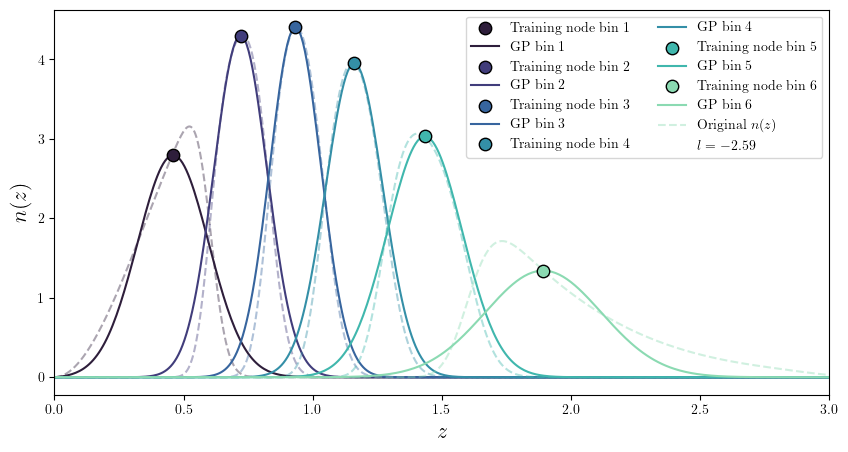

In [42]:
# Plotting the reconstructed n(z) for first step #
import matplotlib as mpl 
mpl.rcParams['font.family'] = "serif"
mpl.rcParams['font.serif'] = "Times New Roman"
mpl.rcParams['text.usetex'] = True

palette = sns.color_palette("mako", 6)
fig, ax = plt.subplots(figsize=(10, 5))

for i in range(6):
    ax.scatter(x_nodes[1][i], n_meds_she[i], color=palette[i], edgecolor='black', s=80, zorder=3, label=f"Training node bin {i+1}")
    ax.plot(z_pred, dndzs_gp[1][i][0], color=palette[i], label=f"GP bin {i+1}")
    if i == 5:   
        ax.plot(z_nz, dndz_she_norm[i+1], '--', color=palette[i], alpha=0.4, label=f"Original $n(z)$")
    else:
        ax.plot(z_nz, dndz_she_norm[i+1], '--', color=palette[i], alpha=0.4)

ax.plot(1,1, alpha=0, label=f"$l = {corr_lens[1]:.2f}$")  # correlation length to 2 decimal places
ax.set_xlabel(r"$z$", font='Times New Roman', fontsize=16)
ax.set_ylabel(r"$n(z)$", font='Times New Roman', fontsize=16)
ax.set_xlim(0, 3)
ax.legend(loc="upper right", ncol=2, fontsize=10)
plt.savefig('/home/jipdebuck/plots/GP_reconstruction.png', dpi=600, bbox_inches='tight')

In [46]:
import matplotlib.font_manager as fm

for f in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'Times' in f:
        print(f)

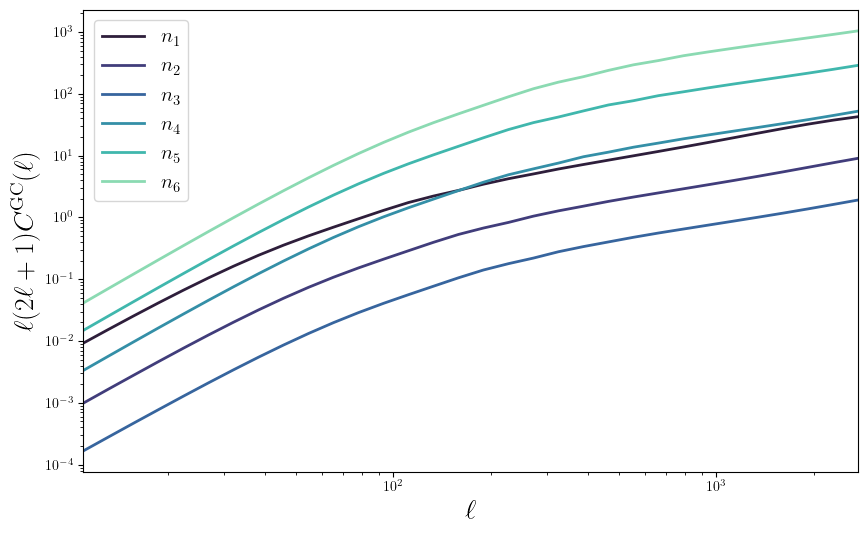

In [45]:
# Plotting the corresponding C_ell's for first step #
fig, ax = plt.subplots(figsize=(10, 6))

# ells = ell_theory


for i in range(0, 6):
    ells = cells_gp[1]['POS', 'POS', i+1, i+1].ell
    ax.loglog(
        ells,
        ells*(2*ells+1)*cells_gp[1]['POS', 'POS', i+1, i+1],
        label = '$n_{{{}}}$'.format(i+1),
        linewidth=2,
        color=palette[i]
    )

 ##   ells = uncoupled_cls_WL['POS', 'POS', i+1, i+1].ell
   ## ax.loglog(
    #    ells,
    #    ells*(2*ells+1)*uncoupled_cls_WL['POS', 'POS', i+1, i+1],
    #    linestyle='--',
    #    alpha=0.8,
    #    linewidth=2,
    #    color=palette[i]
    #)

    ax.set_xlabel(r'$\ell$', font='Times New Roman', fontsize=20)
    ax.set_ylabel(r'$\ell (2\ell +1)C^{\rm GC}(\ell)$', font='Times New Roman', fontsize=20)
    ax.set_xlim(np.min(ells), np.max(ells))

#ax.scatter(1,1, alpha=0, label=f"-2 ln $ \mathcal{{L}} = {likelihoods[1]:.2f}$")  # replaced j with 1
ax.legend(loc='upper left', fontsize=15, frameon=True)
plt.savefig('/home/jipdebuck/plots/Cl_reconstruction.png', bbox_inches='tight')

### 6. Implementing an ordering prior on the x-nodes 

In [21]:
step_counter = 0

def like_Naut_test_gp(param_dict):
    global step_counter
    # Enforce physical prior on w0 + wa
#    if param_dict['w0'] + param_dict['wa'] > -1. / 3:
#        return (-np.inf, 0)
    l  = param_dict["corr_len"]
    z_meds[0] = param_dict["x1"]
    z_meds[1] = param_dict["x2"]
    z_meds[2] = param_dict["x3"]
    z_meds[3] = param_dict["x4"]
    z_meds[4] = param_dict["x5"]
    z_meds[5] = param_dict["x6"]
    if z_meds[0] >= z_meds[1] or z_meds[1] >= z_meds[2] or z_meds[2] >= z_meds[3] or z_meds[3] >= z_meds[4] or z_meds[4] >= z_meds[5]:
        return (-np.inf, 0)
    n_meds[0] = param_dict["y1"]
    n_meds[1] = param_dict["y2"]
    n_meds[2] = param_dict["y3"]
    n_meds[3] = param_dict["y4"]
    n_meds[4] = param_dict["y5"]
    n_meds[5] = param_dict["y6"]
    priors_loop, predictions_loop = build_gp_nz(n_meds, z_meds, l, z_bounds, z_pred, alpha, RBF, nu, const_value, const_bounds)
    my_dndz_norm_gp_loop = resample_dndz_gp(predictions_loop, z_pred_res, myz)
    pars_in = default_pars.copy()
    pars_in.update(param_dict)
    #h = pars_in['H0'] / 100.0
    #pars_in['Omega_cdm0'] = param_dict['omch2'] / h**2
    #pars_in['Omega_b0'] = param_dict['ombh2'] / h**2
    pars_in['As'] = np.exp(param_dict['logAs']) * 1e-10
    like_instance.data.update({'dndz_she': my_dndz_norm_gp_loop})
    ll = like_instance.loglike(pars_in)
    step = {"params": param_dict.copy(), "dndz": predictions_loop.copy(), "dndz_norm": my_dndz_norm_gp_loop.copy(), "loglike": ll, "C_ell": like_instance.theory_prediction}
    np.save(f"/home/jipdebuck/files/gp_prior_step_{step_counter}.npy", step)
    step_counter += 1
    return (ll, like_instance.derived['sigma8_0'])

In [22]:
# Running the sampler #

blob_vec = [('sigma8_0', float)]
sampler = Sampler(prior_gp, like_Naut_test_gp, 
        n_live=10000, 
        blobs_dtype=blob_vec,
            filepath= 'steps_prior.h5', 
            resume=True)
t_start = time.time()
print('Starting sampling...')
sampler.run(verbose=True)
t_end = time.time()
total_seconds = t_end - t_start
days = int(total_seconds // 86400)
hours = int((total_seconds % 86400) // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)
print(f'Total time: {days}d {hours}h {minutes}m {seconds}s')
print('Sampling finished!')
print('Saving chains...')

points, log_w, log_l, derived = sampler.posterior(return_blobs=True)

        # --- Sampled parameters ---
param_names = list(prior_gp.keys)
chain_dict = {
            name: points[:, i]
            for i, name in enumerate(param_names)
        }

        # --- Derived parameters ---
derived_names = [name for name, _ in blob_vec]

derived_dict = {
            derived_names[0]: np.array([sample[0] for sample in derived])
        }

        # --- Save everything in a labelled way ---
np.savez_compressed(
            'gp_v2.npz',
            chain=chain_dict,
            derived=derived_dict,
            weights=log_w,
            logl=log_l,
            param_names=param_names,
            derived_names=derived_names
        )

print('Chains saved with name:', name_to_chain_gp + '.npz')

Starting sampling...
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    


/home/jipdebuck/miniconda3/envs/venv_310/lib/python3.10/site-packages/cosmopower/cosmopower_NN.py:378: RuntimeWarning: overflow encountered in exp
  layers.append((self.betas_[i] + (1.-self.betas_[i])*1./(1.+np.exp(-self.alphas_[i]*act[-1])))*act[-1])


KeyboardInterrupt: 

In [23]:
# Loading saved steps #

dndzs_gp_prior = {}
cells_gp_prior = {}
likelihoods_prior = {}
params_prior = {}
dndzs_gp_norm_prior = {}

for i in range(6):
    name = f"/home/jipdebuck/files/gp_prior_step_{i}.npy"
    step = np.load(name, allow_pickle=True)
    dndzs_gp_prior[i] = step.item()['dndz']
    dndzs_gp_norm_prior[i] = step.item()['dndz_norm']
    cells_gp_prior[i] = step.item()['C_ell']
    likelihoods_prior[i] = step.item()['loglike']
    params_prior[i] = step.item()['params']
y_nodes_prior = {}
x_nodes_prior = {}
corr_lens_prior = []
for i in range(6):  # run index
    y_nodes_prior[i] = []
    x_nodes_prior[i] = []
    corr_lens_prior.append(params_prior[i]['corr_len'])
    for j in range(6):  # node index
        y_nodes_prior[i].append(params_prior[i][f'y{j+1}'])
        x_nodes_prior[i].append(params_prior[i][f'x{j+1}'])
print(corr_lens_prior)
print(cells_gp_prior)
print(params_prior)
print(y_nodes_prior)

[array(0.06375013), array(0.05452882), array(0.044183), array(0.09523816), array(0.02532952), array(0.02477735)]
{0: {('SHE', 'SHE', 1, 1): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 2): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 3): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 4): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 5): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 1, 6): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 2): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 3): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 4): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 5): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 2, 6): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 3, 3): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 3, 4): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 3, 5): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 3, 6): AngularPowerSpectrum(axis=(2,)), ('SHE', 'SHE', 4, 4): AngularPowerSpectrum(axis=(2,)), ('

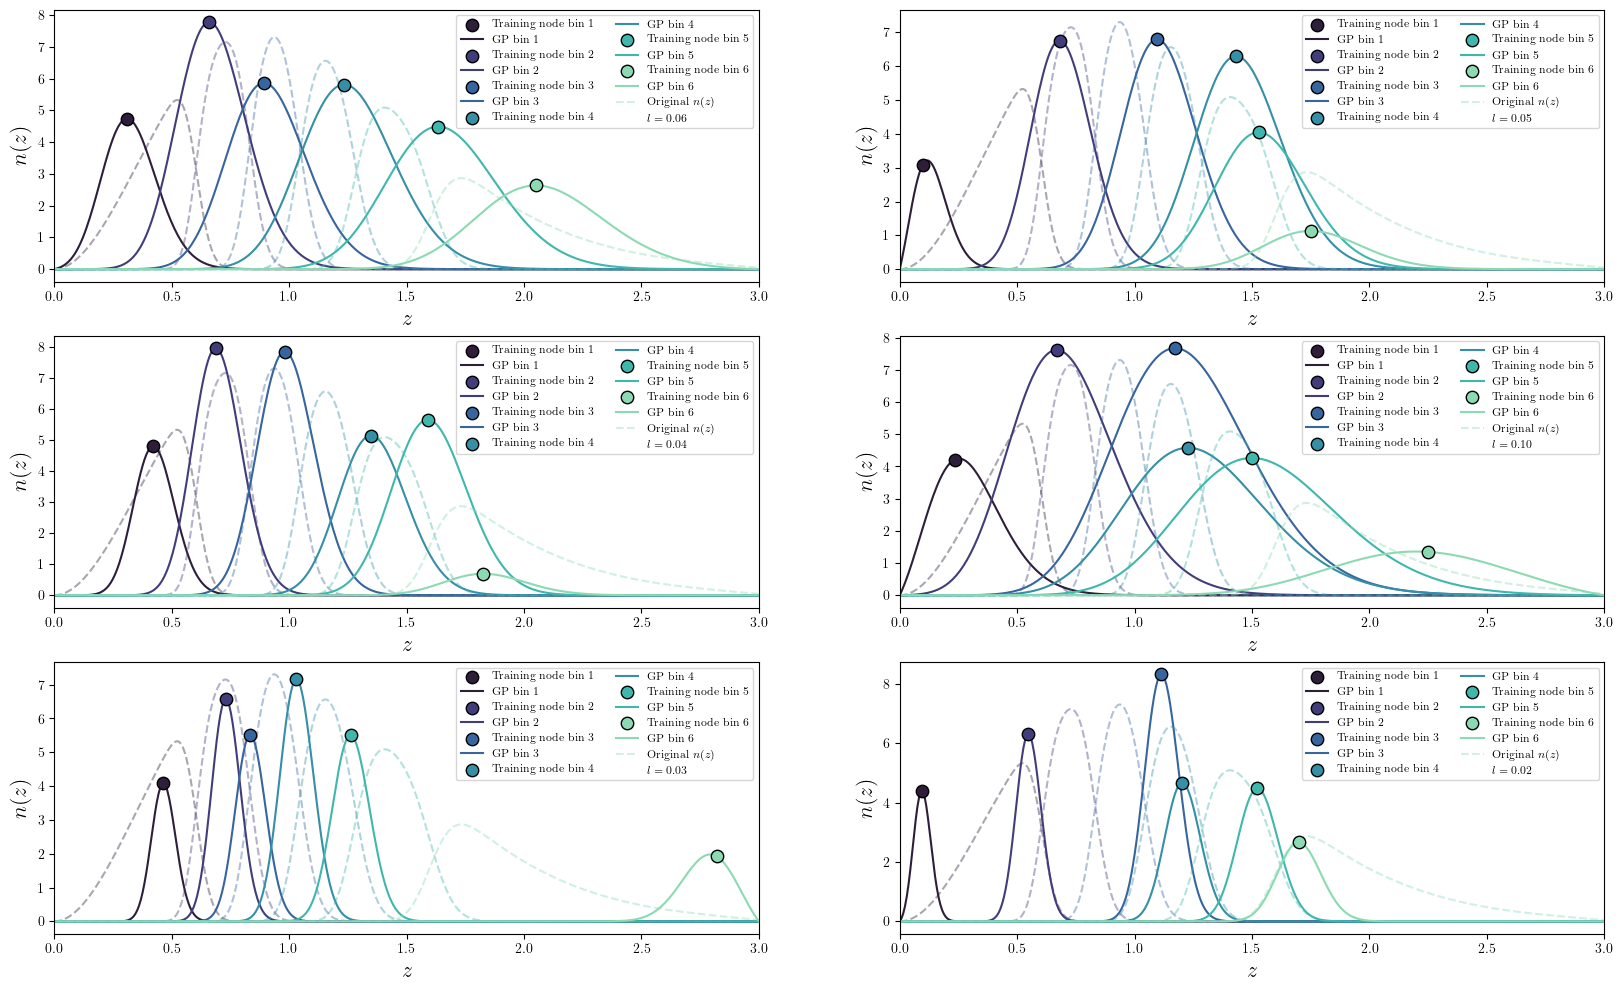

In [28]:
# Plotting the reconstructed n(z) for first 6 steps #

import matplotlib as mpl 
mpl.rcParams['font.family'] = "serif"
mpl.rcParams['font.serif'] = "Times New Roman"
mpl.rcParams['text.usetex'] = True

palette = sns.color_palette("mako", 6)
fig, axes = plt.subplots(3,2, figsize=(20, 12))
axes = axes.flatten()
for j in range(6):
    ax = axes[j]
    for i in range(6):
        ax.scatter(x_nodes_prior[j][i], y_nodes_prior[j][i], color=palette[i], edgecolor='black', s=80, zorder=3, label=f"Training node bin {i+1}")
        ax.plot(z_pred, dndzs_gp_prior[j][i][0], color=palette[i], label=f"GP bin {i+1}")
        if i == 5:   
            ax.plot(z_nz, nz_heracles[i+1], '--', color=palette[i], alpha=0.4, label=f"Original $n(z)$")
        else:
            ax.plot(z_nz, nz_heracles[i+1], '--', color=palette[i], alpha=0.4)
#    ax.plot(myz, dndzs_gp_norm[0][j], color=palette[j], linestyle='--', label=f"{j+1} GP normalized")
#    ax.plot(myz, my_dndz_she_norm[j], color=palette[j], linestyle='--', label=f"{j+1} original normalized")
#    ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
#                    color=palette[j], alpha=0.2)

#    ax.plot(z_nz, dndz_she_norm[j+1], '--', color=palette[j], alpha=0.4)
#    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")
    ax.plot(1,1, alpha=0, label=f"$l = {corr_lens_prior[j]:.2f}$")  # correlation length to 2 decimal places
    ax.set_xlabel(r"$z$", font='Times New Roman', fontsize=16)
    ax.set_ylabel(r"$n(z)$", font='Times New Roman', fontsize=16)
    ax.set_xlim(0, 3)
    ax.legend(loc="upper right", ncol=2, fontsize=8)
plt.savefig('/home/jipdebuck/plots/GP_reconstruction_prior.pdf', bbox_inches='tight')

AngularPowerSpectrum(axis=(2,))


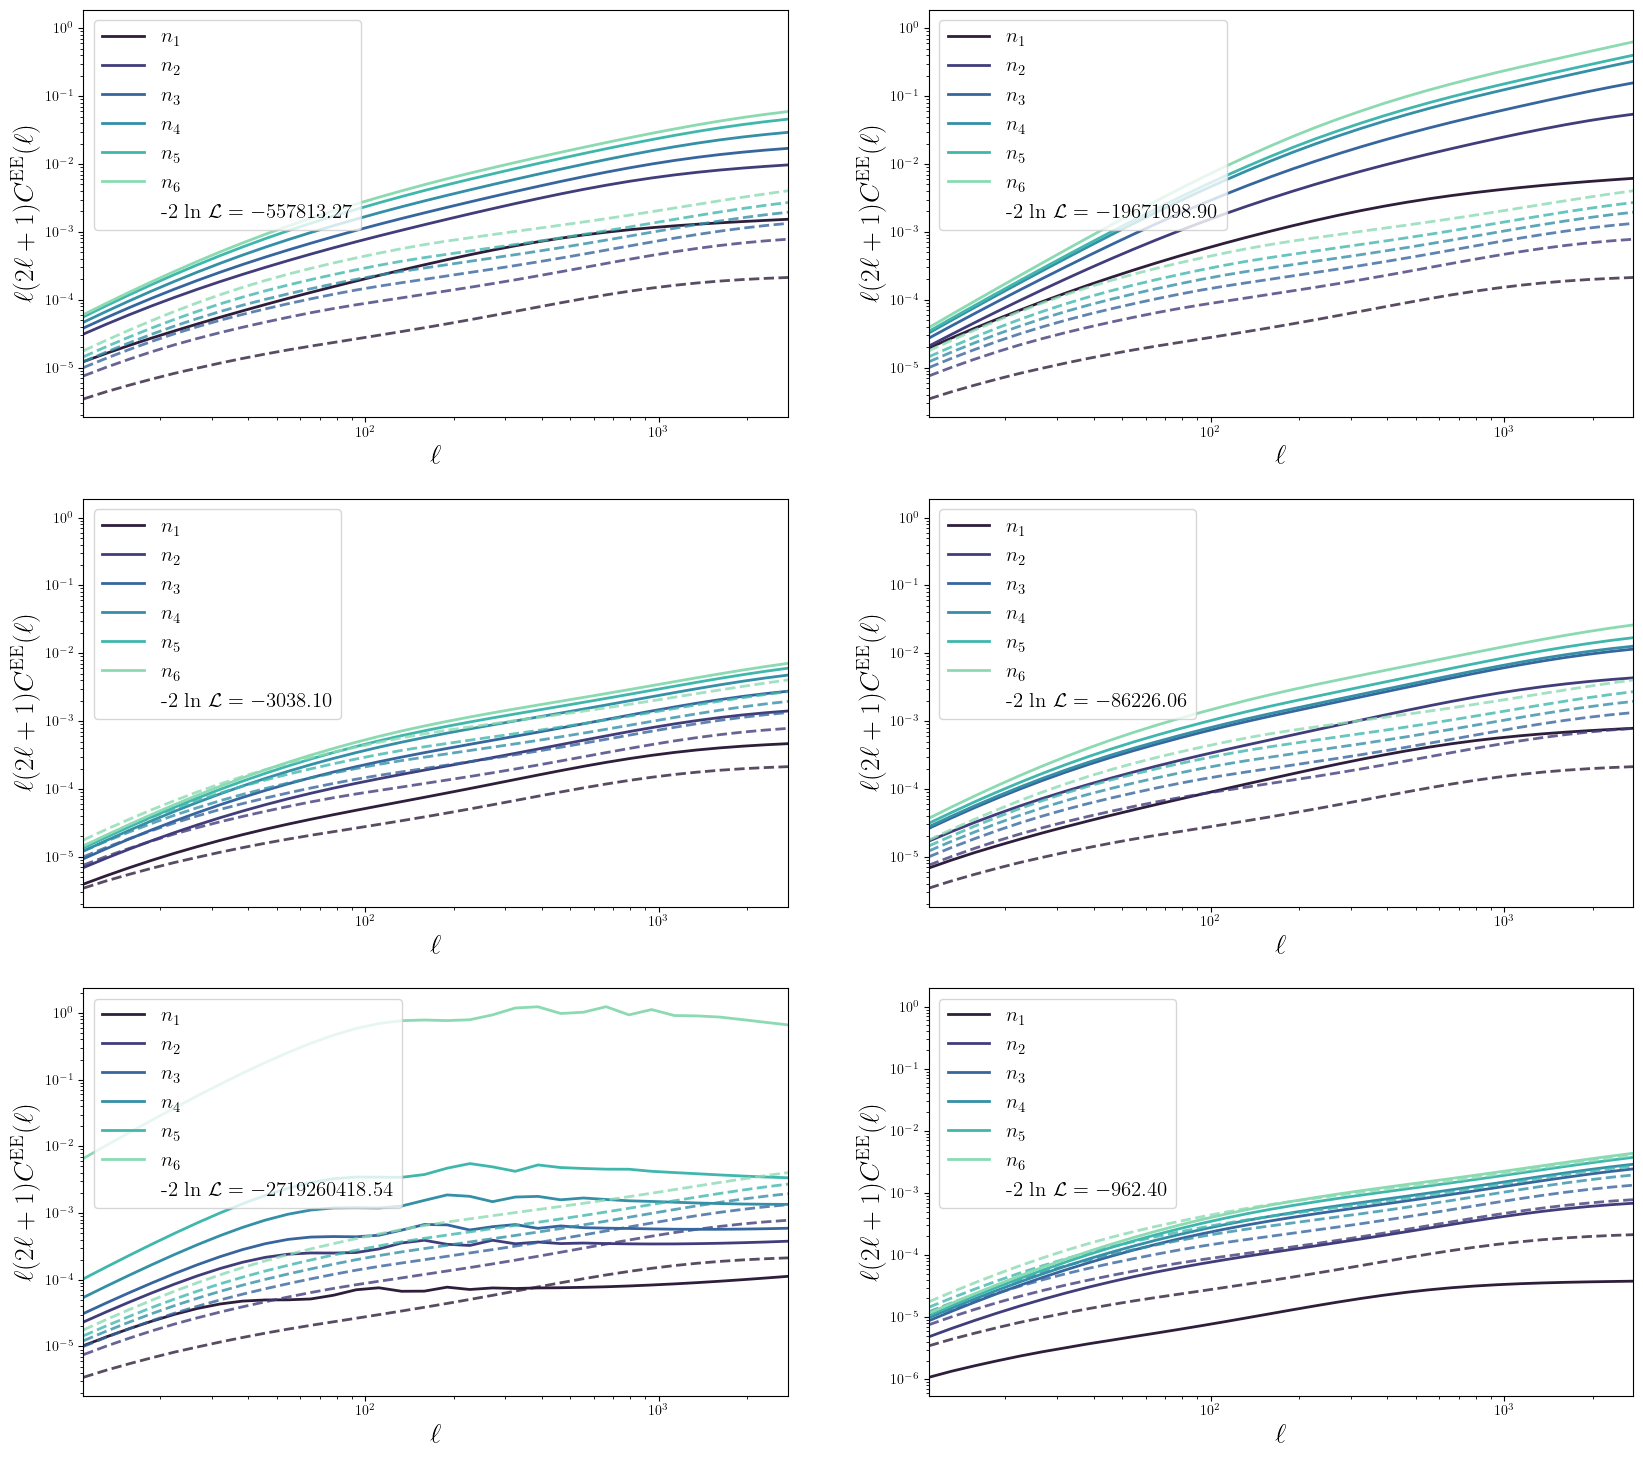

In [29]:
# Plotting the corresponding C_ell's for first 6 steps #

fig, axes = plt.subplots(3, 2, figsize=(20, 18))
axes = axes.flatten()
cells_gp_prior[0] = {**cells_gp_prior[0]}
print(cells_gp_prior[0]['SHE', 'SHE', i+1, i+1])
#ells = ell_theory
for j in range(0,6):
    ax = axes[j]
    for i in range(0, 6):
        ells = cells_gp_prior[j]['SHE', 'SHE', i+1, i+1].ell
        ax.loglog(ells, ells*(2*ells+1)*cells_gp_prior[j]['SHE', 'SHE', i+1, i+1][0,0], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=palette[i])
        #ax.set_ylim(1e-4, 1e-1)
        #ax.set_xlim(10, 2000)
        ells = uncoupled_cls_WL['SHE', 'SHE', i+1, i+1].ell
        ax.loglog(ells, ells*(2*ells+1)*uncoupled_cls_WL['SHE', 'SHE', i+1, i+1][0,0], linestyle='--', alpha=0.8, linewidth=2, color=palette[i])
        ax.set_xlabel(r'$\ell$', font='Times New Roman', fontsize=20)
        ax.set_ylabel(r'$\ell (2\ell +1)C^{\rm EE}(\ell)$', font='Times New Roman', fontsize=20);
#axes.set_title("Original $n(z)$ (dashed lines) vs reconstructed $n(z)$ (solid lines) $C^{EE}(\ell)$'s", fontsize=14)
        ax.set_xlim(np.min(ells), np.max(ells))
    ax.scatter(1,1, alpha=0, label=f"-2 ln $ \mathcal{{L}} = {likelihoods_prior[j]:.2f}$")  # correlation length to 2 decimal places
    ax.legend(loc='upper left', fontsize=15, frameon=True)
plt.savefig('/home/jipdebuck/plots/Cl_reconstruction_prior.pdf', bbox_inches='tight')

dndz_pos_norm: {1: array([ 1.08663524e-04,  2.17327048e-04,  4.61765128e-04, ...,
       -3.36965089e-14,  0.00000000e+00,  0.00000000e+00], dtype=float32), 2: array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 3: array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
       -3.4289263e-14,  0.0000000e+00,  0.0000000e+00], dtype=float32), 4: array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 5: array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 6: array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)}
dndz_she_norm: {1: array([ 1.08663524e-04,  2.17327048e-04,  4.61765128e-04, ...,
       -3.36965089e-14,  0.00000000e+00,  0.00000000e+00], dtype=float32), 2: array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 3: array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
       -3.4289263e-14,  0.0000000e+00,  0.0000000e+00], dtype=float32), 4: array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 5: array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 6: array([0., 0., 0., ..

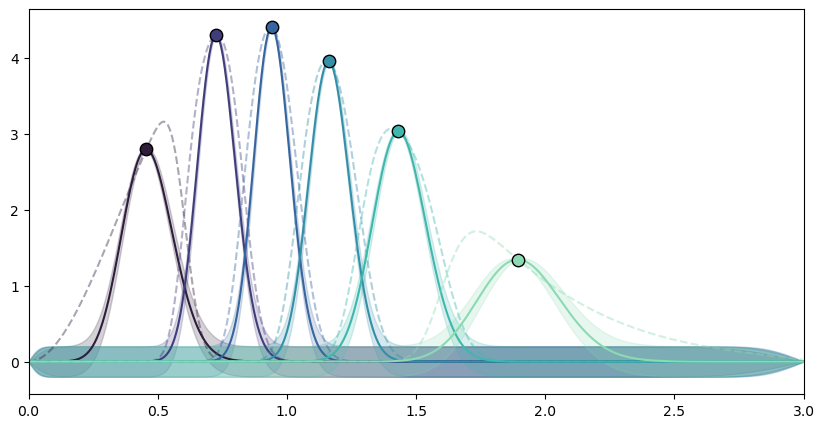

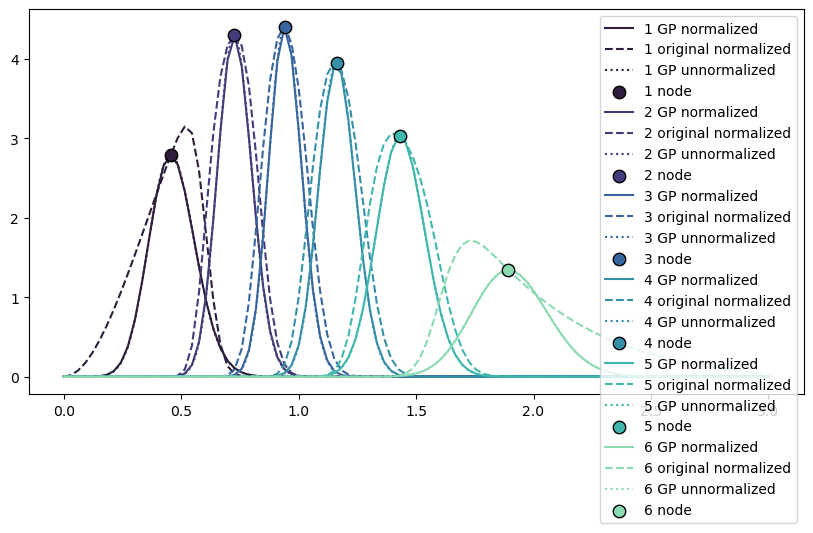

In [33]:
import numpy as np
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
from multiprocessing import get_context
import seaborn as sns
import time
import corner
import matplotlib.pyplot as plt

from nautilus import Prior
from nautilus import Sampler
from scipy.stats import norm
#from mpi4py.futures import MPIPoolExecutor
# Import euclidlib for reading the Euclid data
import euclidlib as el

# Import cloelib for cosmology and theoretical predictions
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations

# Import cloelike for likelihoods
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt, EuclidLikelihood_WL

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared,
    DotProduct, ConstantKernel as C
)

myz = np.linspace(1e-4, 3.0, 100)
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized
full_cov=np.load('/home/jipdebuck/covariance_Gauss_DR1_TR1like_1589_2D.npz')['Gauss']

# Get n(z)
z_nz, nz_heracles = el.phz.redshift_distributions('/home/jipdebuck/nz_example.fits')


# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_heracles, z_nz)
dndz_she_norm = normalize_dndz(nz_heracles, z_nz)

print('dndz_pos_norm:', dndz_pos_norm)
print('dndz_she_norm:', dndz_she_norm)
# Find boundaries for x-nodes priors 
i_lows_pos = {}
i_highs_pos = {}
for key, nz in dndz_pos_norm.items():
    nz_max = np.max(nz)
    mask = np.where(nz > 0.5 * nz_max)[0]
    i_lows_pos.update({key: mask[0]})
    i_highs_pos.update({key: mask[-1]})
z_lows_pos = z_nz[[i_lows_pos[key] for key in dndz_pos_norm.keys()]]
z_highs_pos = z_nz[[i_highs_pos[key] for key in dndz_pos_norm.keys()]]

i_lows_she = {}
i_highs_she = {}
for key, nz in dndz_she_norm.items():
    nz_max = np.max(nz)
    mask = np.where(nz > 0.5 * nz_max)[0]
    i_lows_she.update({key: mask[0]})
    i_highs_she.update({key: mask[-1]})
z_lows_she = z_nz[[i_lows_she[key] for key in dndz_she_norm.keys()]]
z_highs_she = z_nz[[i_highs_she[key] for key in dndz_she_norm.keys()]]


# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values())) #stacking arrays vertically
    my_dndz_norm = np.zeros([len(nz_example), len(myz)]) #creating an empty array
    print(my_dndz_norm.shape)
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :]) #interpolating to new myz values
    return my_dndz_norm

my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, myz)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, myz)




def build_gp_nz(n_med, z_med, corr_len, delta_x, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds):
    gp_priors = {}
    gp_predictions = {}
    for i, nz in enumerate(n_med):
        corr_len_scale = corr_len*delta_x[i]
        if kernel_class == Matern:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len_scale, nu=nu, length_scale_bounds="fixed")
        else:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len_scale, length_scale_bounds="fixed")
        gp = GaussianProcessRegressor(kernel=kernel, optimizer=None, normalize_y=False, alpha=alpha)
        X_train = np.array([np.log1p(z_bounds[0])/np.log1p(z_bounds[1]), np.log1p(z_med[i])/np.log1p(z_bounds[1]), np.log1p(z_bounds[1])/np.log1p(z_bounds[1])]).reshape(-1, 1)
        y_train = np.array([0.0, nz, 0.0])
        gp.fit(X_train, y_train)
        x_pred = np.log1p(z_pred)/np.log1p(z_bounds[1])
        x_pred = np.array(x_pred).reshape(-1, 1)
        y_pred, y_std = gp.predict(x_pred, return_std=True)
        gp_priors[i] = gp
        gp_predictions[i] = (y_pred, y_std)
    return gp_priors, gp_predictions

z_meds_she = []   # positions of median redshift for each bin
n_meds_she = []   # height of n(z) at median redshift for each bin
z_meds_pos = []
n_meds_pos = []

for key, nz in dndz_she_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med = np.interp(0.5, cdf, z_nz)
    n_med = nz[np.argmin(np.abs(z_nz - z_med))]
    z_meds_she.append(z_med)
    n_meds_she.append(n_med)
    
for key, nz in dndz_pos_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med_pos = np.interp(0.5, cdf, z_nz)
    n_med_pos = nz[np.argmin(np.abs(z_nz - z_med_pos))]
    z_meds_pos.append(z_med_pos)
    n_meds_pos.append(n_med_pos)

corr_len = 0.32                          # correlation length for the GP kernel
z_bounds = (0,3)                              # bounds for the redshift
z_pred = np.linspace(0, 3, 400)       # prediction points for GP
alpha = 1e-8                                  # noise level during fitting 
kernel_class = RBF
nu = 1.5                                      # necessary for Matern only, defines smoothness 
const_value = 0.04                            # amplitude of constant kernel
const_bounds = (1e-4, 1.0)                    # bounds for constant kernel amplitude
widths_she = np.array([z_highs_she[0]-z_lows_she[0], z_highs_she[1]-z_lows_she[1], z_highs_she[2]-z_lows_she[2], z_highs_she[3]-z_lows_she[3], z_highs_she[4]-z_lows_she[4], z_highs_she[5]-z_lows_she[5]])
widths_pos = np.array([z_highs_pos[0]-z_lows_pos[0], z_highs_pos[1]-z_lows_pos[1], z_highs_pos[2]-z_lows_pos[2], z_highs_pos[3]-z_lows_pos[3], z_highs_pos[4]-z_lows_pos[4], z_highs_pos[5]-z_lows_pos[5]])

# We read with euclidlib v2025.2 (v2025.1 is also compatible)
z_pred_res = z_pred.reshape(-1, 1)
name_to_chain_gp = '3x2pt_LCDM_DR1_GP_norm'
delta_x_she = []
for i in range(len(n_meds_she)):
    z_low_she = z_meds_she[i] - widths_she[i]/2
    z_high_she = z_meds_she[i] + widths_she[i]/2
    dx_she = (np.log1p(z_high_she) - np.log1p(z_low_she)) / np.log1p(z_bounds[1])
    delta_x_she.append(dx_she)

delta_x_pos = []
for i in range(len(n_meds_pos)):
    z_low_pos = z_meds_pos[i] - widths_pos[i]/2
    z_high_pos = z_meds_pos[i] + widths_pos[i]/2
    dx_pos = (np.log1p(z_high_pos) - np.log1p(z_low_pos)) / np.log1p(z_bounds[1])
    delta_x_pos.append(dx_pos)
#cells_data = el.photo.harmonic_space.angular_power_spectra('/disks/shear16/canasherrera/SheariouslyCalibrated/data/DR1/synthetic_angular_spectra_DR1.fits')
priors, predictions = build_gp_nz(n_meds_she, z_meds_she, corr_len, delta_x_she, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)
palette = sns.color_palette("mako", 6)
fig, ax = plt.subplots(figsize=(10, 5))
for j, nz in enumerate(n_meds_she):
    y_pred, y_std = predictions[j]
    X_train, y_train = z_meds_she[j], n_meds_she[j]

    ax.plot(z_pred, y_pred, color=palette[j], label=f"{key} GP mean")
    ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
                    color=palette[j], alpha=0.2)

    ax.plot(z_nz, dndz_she_norm[j+1], '--', color=palette[j], alpha=0.4)
    ax.set_xlim(0,3)
    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")


fiducial_cosmology = {
    'H0': 67,                # Hubble constant
    'Omega_cdm0': 0.27,        # Cold dark matter density
    'Omega_b0': 0.049,         # Baryon density
    'Omega_k0': 0.0,           # Curvature
    'mnu': 0.077,                # Neutrino mass
    'w0': -1.0,                # Dark energy equation of state (present)
    'wa': 0.0,                 # Dark energy equation of state (evolution)
    'ns': 0.96,                # Scalar spectral index
    'As': 2.1e-9, # Scalar amplitude
    'gamma_MG': 0.545,         # Modified gravity parameter
    'log10TAGN': 7.75,          # AGN feedback parameter
    'N_mnu': 1,                  # Number of massive neutrino species
    'N_eff': 3.046             # Effective number of relativistic species
}

fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    # Magnification bias (per bin)
    'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
    'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
    'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
    'magnification_bias_7': 0.0, 'magnification_bias_8': 0.0,
    'magnification_bias_9': 0.0, 'magnification_bias_10': 0.0,
    'magnification_bias_11': 0.0, 'magnification_bias_12': 0.0,
    'magnification_bias_13': 0.0,
    # Redshift errors (positions)
    'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 
    'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
    'dz_pos_7': 0.0, 'dz_pos_8': 0.0, 'dz_pos_9': 0.0, 
    'dz_pos_10': 0.0, 'dz_pos_11': 0.0, 'dz_pos_12': 0.0,
    'dz_pos_13': 0.0,
    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
    'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
    'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
    'multiplicative_bias_7': 0.0, 'multiplicative_bias_8': 0.0,
    'multiplicative_bias_9': 0.0, 'multiplicative_bias_10': 0.0,
    'multiplicative_bias_11': 0.0, 'multiplicative_bias_12': 0.0,
    'multiplicative_bias_13': 0.0,
    # Redshift errors (shear)
    'dz_shear_1': 0.0, 'dz_shear_2': 0.0, 'dz_shear_3': 0.0,
    'dz_shear_4': 0.0, 'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
    'dz_shear_7': 0.0, 'dz_shear_8': 0.0, 'dz_shear_9': 0.0, 
    'dz_shear_10': 0.0, 'dz_shear_11': 0.0, 'dz_shear_12': 0.0,
    'dz_shear_13': 0.0
}

ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])

# --- Cosmology and Tracers: Easy to Change! ---

# Choose which perturbation model to use: 'linear' or 'nonlinear'
perturbation_model = 'nonlinear'  # change to 'linear' if needed

# Cosmology parameters (easy to modify)
cosmo_params = fiducial_cosmology.copy()
nuisance_params = fiducial_nuisance.copy()

# Create background
background = CAMBBackground(
    H0=cosmo_params['H0'],
    Omega_cdm0=cosmo_params['Omega_cdm0'],
    Omega_b0=cosmo_params['Omega_b0'],
    w0=cosmo_params['w0'],
    wa=cosmo_params['wa'],
    Omega_k0=cosmo_params['Omega_k0'],
    ns=cosmo_params['ns'],
    As=cosmo_params['As'],
    mnu=cosmo_params['mnu'],
    gamma_MG=cosmo_params['gamma_MG'],
    N_mnu=cosmo_params['N_mnu']
)

# Choose perturbations
if perturbation_model == 'linear':
    perturbations = HMemuLinearPerturbations(background, myz)
else:
    perturbations = HMemuNonLinearPerturbations(
        background, 
        HMemuLinearPerturbations(background, myz), 
        myz, 
        log10TAGN=cosmo_params['log10TAGN']
    )

def resample_dndz_gp(gp_predictions, z_pred, zs):
#    gp_predictions_norm = {}
#    for key in gp_predictions.keys():
#        gp_predictions_norm[key] = gp_predictions[key][0]/integrate.trapezoid(gp_predictions[key][0], z_pred[:,0])
    my_dndz = np.vstack([gp_predictions[i][0] for i in sorted(gp_predictions.keys())])
    my_dndz_norm = np.zeros([len(gp_predictions), len(zs)])
    print(my_dndz_norm.shape)
    for i in range(len(gp_predictions)):
        # gp_predictions[i][0] is 1D array of n(z) for bin i

        my_dndz_norm[i, :] = np.interp(zs, z_pred[:,0], my_dndz[i, :])
    
    return my_dndz_norm

my_dndz_norm_gp = resample_dndz_gp(predictions, z_pred_res, myz)
palette = sns.color_palette("mako", 6)
fig, ax = plt.subplots(figsize=(10, 5))

for j, nz in enumerate(n_meds_she):
    y_pred, y_std = predictions[j]
    X_train, y_train = z_meds_she[j], n_meds_she[j]
    ax.plot(myz, my_dndz_norm_gp[j], color=palette[j],label=f"{j+1} GP normalized")
    ax.plot(myz, my_dndz_she_norm[j], color=palette[j], linestyle='--', label=f"{j+1} original normalized")
#    ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
#                    color=palette[j], alpha=0.2)

    ax.plot(z_pred, y_pred, color=palette[j], linestyle=':', label=f"{j+1} GP unnormalized")
    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")
ax.legend()
tracer_pos = PositionsTracer(
    perturbations=perturbations,
    dndz=my_dndz_pos_norm,
    z=myz,
    galaxy_bias_model='poly',
    nuisance_params=nuisance_params
)

tracer_she = ShearTracer(
    perturbations=perturbations,
    dndz=my_dndz_she_norm,
    z=myz,
    nuisance_params=nuisance_params
)


cls_sheshe = AngularTwoPoint(tracer_she, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_posshe = AngularTwoPoint(tracer_pos, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_pospos = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl(ell_theory, 0, perturbations.k)
#print(cls_sheshe[('SHE', 'SHE', 1,1)], len(ell_theory))

# Combine all spectra into a single dictionary for easy access
uncoupled_cls = {**cls_posshe, **cls_sheshe, **cls_pospos}

def build_data(cls, mapa_key, cov, zs, nzs, include_pos=False, include_she=False):
    data = {
        'cells': cls,
        'ells': cls[mapa_key].ell,
        'z_arr': zs,
        'cov': cov,
        'mixmat': {},
    }
    if include_pos:
        data['dndz_pos'] = nzs[0]
    if include_she:
        data['dndz_she'] = nzs[1]
    return data

def build_settings(cls):
    for key in cls:
        if key[:2] == ('POS', 'POS'):
            scale_cuts = {key: [10, 750] for key in cls}
        else:
            scale_cuts = {key: [10, 1500] for key in cls}
    return {'n_ell_bins': 32, 'scale_cuts': scale_cuts}

data_3x2pt = build_data(uncoupled_cls, ('SHE', 'SHE', 1, 1), 
                             full_cov, 
                             myz, [my_dndz_pos_norm, my_dndz_she_norm],
                             include_pos=True, include_she=True)
settings_3x2pt  = build_settings(uncoupled_cls)

like_instance = EuclidLikelihood_3x2pt(
        data=data_3x2pt,
        settings=settings_3x2pt,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
        mode="uncoupled"

    )

loglike = like_instance.loglike(fiducial_cosmology | fiducial_nuisance)
print("✨ Log-likelihood at fiducial: ", loglike)


# Priors
zmean_dr1 = np.array([0.4371, 0.726, 0.9424, 1.164, 1.437, 1.963])

prior_gp = Prior()
prior_gp.add_parameter('Omega_b0', dist=(0.01, 0.1))
prior_gp.add_parameter('Omega_cdm0', dist=(0.1, 0.8))
prior_gp.add_parameter('logAs', dist=(np.log(0.6e-9*1e10), np.log(5e-9*1e10)))
prior_gp.add_parameter('ns', dist=(0.6, 1.2))
prior_gp.add_parameter('H0', dist=(50, 90))
prior_gp.add_parameter('AIA', dist=(-1, 1))
prior_gp.add_parameter('EtaIA', dist=(-5, 5))
#prior_gp.add_parameter('w0', dist=(-3.0, -0.5))
#prior_gp.add_parameter('wa', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly0', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly1', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly2', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly3', dist=(-3.0, 3.0))
prior_gp.add_parameter('multiplicative_bias_1', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_2', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_3', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_4', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_5', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_6', norm(loc=0.0, scale=0.01)) 
prior_gp.add_parameter('magnification_bias_1', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_2', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_3', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_4', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_5', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_6', dist=(-2.0, 2.0))
#prior.add_parameter('dz_pos_1', norm(loc=0.0, scale=0.002*(1+zmean_dr1[0])))
#prior.add_parameter('dz_pos_2', norm(loc=0.0, scale=0.002*(1+zmean_dr1[1])))
#prior.add_parameter('dz_pos_3', norm(loc=0.0, scale=0.002*(1+zmean_dr1[2])))
#prior.add_parameter('dz_pos_4', norm(loc=0.0, scale=0.002*(1+zmean_dr1[3])))
#prior.add_parameter('dz_pos_5', norm(loc=0.0, scale=0.002*(1+zmean_dr1[4])))
#prior.add_parameter('dz_pos_6', norm(loc=0.0, scale=0.002*(1+zmean_dr1[5])))
#prior.add_parameter('dz_shear_1', norm(loc=0.0, scale=0.002*(1+zmean_dr1[0])))
#prior.add_parameter('dz_shear_2', norm(loc=0.0, scale=0.002*(1+zmean_dr1[1])))
#prior.add_parameter('dz_shear_3', norm(loc=0.0, scale=0.002*(1+zmean_dr1[2])))
#prior.add_parameter('dz_shear_4', norm(loc=0.0, scale=0.002*(1+zmean_dr1[3])))
#prior.add_parameter('dz_shear_5', norm(loc=0.0, scale=0.002*(1+zmean_dr1[4])))
#prior.add_parameter('dz_shear_6', norm(loc=0.0, scale=0.002*(1+zmean_dr1[5])))
prior_gp.add_parameter('x1_she', dist= (z_lows_she[0], z_highs_she[0]))
prior_gp.add_parameter('x2_she', dist= (z_lows_she[1], z_highs_she[1]))
prior_gp.add_parameter('x3_she', dist= (z_lows_she[2], z_highs_she[2]))
prior_gp.add_parameter('x4_she', dist= (z_lows_she[3], z_highs_she[3]))
prior_gp.add_parameter('x5_she', dist= (z_lows_she[4], z_highs_she[4]))
prior_gp.add_parameter('x6_she', dist= (z_lows_she[5], z_highs_she[5]))
prior_gp.add_parameter('y1_she', dist= (n_meds_she[0]-1, n_meds_she[0]+1))
prior_gp.add_parameter('y2_she', dist= (n_meds_she[1]-1, n_meds_she[1]+1))
prior_gp.add_parameter('y3_she', dist= (n_meds_she[2]-1, n_meds_she[2]+1))
prior_gp.add_parameter('y4_she', dist= (n_meds_she[3]-1, n_meds_she[3]+1))
prior_gp.add_parameter('y5_she', dist= (n_meds_she[4]-1, n_meds_she[4]+1))
prior_gp.add_parameter('y6_she', dist= (n_meds_she[5]-1, n_meds_she[5]+1))
prior_gp.add_parameter('log_l_she', dist=(np.log(0.001), np.log(1)))
prior_gp.add_parameter('x1_pos', dist= (z_lows_pos[0], z_highs_pos[0]))
prior_gp.add_parameter('x2_pos', dist= (z_lows_pos[1], z_highs_pos[1]))
prior_gp.add_parameter('x3_pos', dist= (z_lows_pos[2], z_highs_pos[2]))
prior_gp.add_parameter('x4_pos', dist= (z_lows_pos[3], z_highs_pos[3]))
prior_gp.add_parameter('x5_pos', dist= (z_lows_pos[4], z_highs_pos[4]))
prior_gp.add_parameter('x6_pos', dist= (z_lows_pos[5], z_highs_pos[5]))
prior_gp.add_parameter('y1_pos', dist= (n_meds_pos[0]-1, n_meds_pos[0]+1))
prior_gp.add_parameter('y2_pos', dist= (n_meds_pos[1]-1, n_meds_pos[1]+1))
prior_gp.add_parameter('y3_pos', dist= (n_meds_pos[2]-1, n_meds_pos[2]+1))
prior_gp.add_parameter('y4_pos', dist= (n_meds_pos[3]-1, n_meds_pos[3]+1))
prior_gp.add_parameter('y5_pos', dist= (n_meds_pos[4]-1, n_meds_pos[4]+1))
prior_gp.add_parameter('y6_pos', dist= (n_meds_pos[5]-1, n_meds_pos[5]+1))
prior_gp.add_parameter('log_l_pos', dist=(np.log(0.001), np.log(1)))

print("✨ Prior set up completed.")
print("Parameters sampled: ", prior_gp.keys)
print("Number of sampled parameters:", len(prior_gp.keys))
default_pars = fiducial_cosmology | fiducial_nuisance

def like_Naut_test_gp(param_dict):
    # Enforce physical prior on w0 + wa
#    if param_dict['w0'] + param_dict['wa'] > -1. / 3:
#        return (-np.inf, 0)
    l_she  = np.exp(param_dict["log_l_she"])
    z_meds_she[0] = param_dict["x1_she"]
    z_meds_she[1] = param_dict["x2_she"]
    z_meds_she[2] = param_dict["x3_she"]
    z_meds_she[3] = param_dict["x4_she"]
    z_meds_she[4] = param_dict["x5_she"]
    z_meds_she[5] = param_dict["x6_she"]
    if z_meds_she[0] >= z_meds_she[1] or z_meds_she[1] >= z_meds_she[2] or z_meds_she[2] >= z_meds_she[3] or z_meds_she[3] >= z_meds_she[4] or z_meds_she[4] >= z_meds_she[5]:
        return (-np.inf, 0)
    n_meds_she[0] = param_dict["y1_she"]
    n_meds_she[1] = param_dict["y2_she"]
    n_meds_she[2] = param_dict["y3_she"]
    n_meds_she[3] = param_dict["y4_she"]
    n_meds_she[4] = param_dict["y5_she"]
    n_meds_she[5] = param_dict["y6_she"]
    l_pos  = np.exp(param_dict["log_l_pos"])
    z_meds_pos[0] = param_dict["x1_pos"]
    z_meds_pos[1] = param_dict["x2_pos"]
    z_meds_pos[2] = param_dict["x3_pos"]
    z_meds_pos[3] = param_dict["x4_pos"]
    z_meds_pos[4] = param_dict["x5_pos"]
    z_meds_pos[5] = param_dict["x6_pos"]
    if z_meds_pos[0] >= z_meds_pos[1] or z_meds_pos[1] >= z_meds_pos[2] or z_meds_pos[2] >= z_meds_pos[3] or z_meds_pos[3] >= z_meds_pos[4] or z_meds_pos[4] >= z_meds_pos[5]:
        return (-np.inf, 0)
    n_meds_pos[0] = param_dict["y1_pos"]
    n_meds_pos[1] = param_dict["y2_pos"]
    n_meds_pos[2] = param_dict["y3_pos"]
    n_meds_pos[3] = param_dict["y4_pos"]
    n_meds_pos[4] = param_dict["y5_pos"]
    n_meds_pos[5] = param_dict["y6_pos"]
    priors_she, predictions_she = build_gp_nz(n_meds_she, z_meds_she, l_she, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)
    my_dndz_norm_gp_she = resample_dndz_gp(predictions_she, z_pred_res, myz)
    priors_pos, predictions_pos = build_gp_nz(n_meds_pos, z_meds_pos, l_pos, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)
    my_dndz_norm_gp_pos = resample_dndz_gp(predictions_pos, z_pred_res, myz)
    pars_in = default_pars.copy()
    pars_in.update(param_dict)
    #h = pars_in['H0'] / 100.0
    #pars_in['Omega_cdm0'] = param_dict['omch2'] / h**2
    #pars_in['Omega_b0'] = param_dict['ombh2'] / h**2
    pars_in['As'] = np.exp(param_dict['logAs']) * 1e-10
    like_instance.data.update({'dndz_she': my_dndz_norm_gp_she, 'dndz_pos': my_dndz_norm_gp_pos})
    return (like_instance.loglike(pars_in), like_instance.derived['sigma8_0'])

n_meds_pos: [2.7942233, 4.3014407, 4.403936, 3.952227, 3.0313654, 1.3420788]
delta_x_she [0.1512393298935407, 0.09546612707921001, 0.08112082181234835, 0.08151967000007927, 0.09505743858123787, 0.12447720724084484]
delta_x_pos [0.1512393298935407, 0.09546612707921001, 0.08112082181234835, 0.08151967000007927, 0.09505743858123787, 0.12447720724084484]


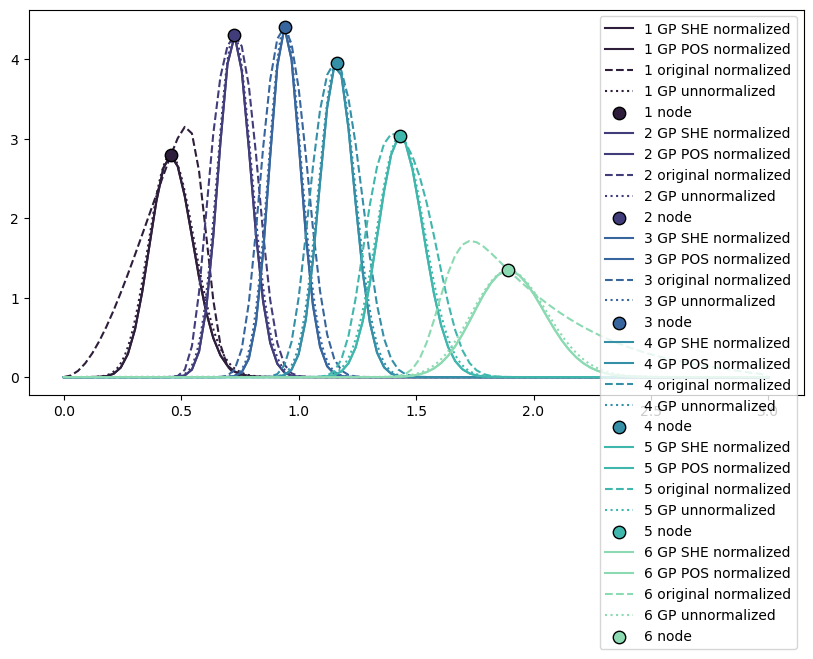

In [40]:
import numpy as np
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
from multiprocessing import get_context
import time
import corner
import matplotlib.pyplot as plt

from nautilus import Prior
from nautilus import Sampler
from scipy.stats import norm
#from mpi4py.futures import MPIPoolExecutor
# Import euclidlib for reading the Euclid data
import euclidlib as el

# Import cloelib for cosmology and theoretical predictions
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations

# Import cloelike for likelihoods
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt, EuclidLikelihood_WL

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared,
    DotProduct, ConstantKernel as C
)

myz = np.linspace(1e-4, 3.0, 100)
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized
full_cov=np.load('/home/jipdebuck/covariance_Gauss_DR1_TR1like_1589_2D.npz')['Gauss']

# Get n(z)
z_nz, nz_heracles = el.phz.redshift_distributions('/home/jipdebuck/nz_example.fits')



# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_heracles, z_nz)
dndz_she_norm = normalize_dndz(nz_heracles, z_nz)

# Find boundaries for x-nodes priors 
i_lows_pos = {}
i_highs_pos = {}
for key, nz in dndz_pos_norm.items():
    nz_max = np.max(nz)
    mask = np.where(nz > 0.5 * nz_max)[0]
    i_lows_pos.update({key: mask[0]})
    i_highs_pos.update({key: mask[-1]})
z_lows_pos = z_nz[[i_lows_pos[key] for key in dndz_pos_norm.keys()]]
z_highs_pos = z_nz[[i_highs_pos[key] for key in dndz_pos_norm.keys()]]

i_lows_she = {}
i_highs_she = {}
for key, nz in dndz_she_norm.items():
    nz_max = np.max(nz)
    mask = np.where(nz > 0.5 * nz_max)[0]
    i_lows_she.update({key: mask[0]})
    i_highs_she.update({key: mask[-1]})
z_lows_she = z_nz[[i_lows_she[key] for key in dndz_she_norm.keys()]]
z_highs_she = z_nz[[i_highs_she[key] for key in dndz_she_norm.keys()]]


# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values())) #stacking arrays vertically
    my_dndz_norm = np.zeros([len(nz_example), len(myz)]) #creating an empty array
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :]) #interpolating to new myz values
    return my_dndz_norm

my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, myz)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, myz)


def build_gp_nz(n_med, z_med, corr_len, delta_x, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds):
    gp_priors = {}
    gp_predictions = {}
    for i, nz in enumerate(n_med):
        corr_len_scale = corr_len*delta_x[i]
        if kernel_class == Matern:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len_scale, nu=nu, length_scale_bounds="fixed")
        else:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len_scale, length_scale_bounds="fixed")
        gp = GaussianProcessRegressor(kernel=kernel, optimizer=None, normalize_y=False, alpha=alpha)
        X_train = np.array([np.log1p(z_bounds[0])/np.log1p(z_bounds[1]), np.log1p(z_med[i])/np.log1p(z_bounds[1]), np.log1p(z_bounds[1])/np.log1p(z_bounds[1])]).reshape(-1, 1)
        y_train = np.array([0.0, nz, 0.0])
        gp.fit(X_train, y_train)
        x_pred = np.log1p(z_pred)/np.log1p(z_bounds[1])
        x_pred = np.array(x_pred).reshape(-1, 1)
        y_pred, y_std = gp.predict(x_pred, return_std=True)
        gp_priors[i] = gp
        gp_predictions[i] = (y_pred, y_std)
    return gp_priors, gp_predictions

z_meds_she = []   # positions of median redshift for each bin
n_meds_she = []   # height of n(z) at median redshift for each bin
z_meds_pos = []
n_meds_pos = []

for key, nz in dndz_she_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med = np.interp(0.5, cdf, z_nz)
    n_med = nz[np.argmin(np.abs(z_nz - z_med))]
    z_meds_she.append(z_med)
    n_meds_she.append(n_med)
    
for key, nz in dndz_pos_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med_pos = np.interp(0.5, cdf, z_nz)
    n_med_pos = nz[np.argmin(np.abs(z_nz - z_med_pos))] # subtract buy z_med_*pos*
    z_meds_pos.append(z_med_pos)
    n_meds_pos.append(n_med_pos)

print('n_meds_pos:', n_meds_pos)

corr_len = 0.3                              # correlation length for the GP kernel
z_bounds = (0,3)                              # bounds for the redshift
z_pred = np.linspace(0, 3, 400)       # prediction points for GP
alpha = 1e-8                                  # noise level during fitting 
kernel_class = RBF
nu = 1.5                                      # necessary for Matern only, defines smoothness 
const_value = 0.04                            # amplitude of constant kernel
const_bounds = (1e-4, 1.0)                    # bounds for constant kernel amplitude
# We read with euclidlib v2025.2 (v2025.1 is also compatible)
z_pred_res = z_pred.reshape(-1, 1)
widths_she = np.array([z_highs_she[0]-z_lows_she[0], z_highs_she[1]-z_lows_she[1], z_highs_she[2]-z_lows_she[2], z_highs_she[3]-z_lows_she[3], z_highs_she[4]-z_lows_she[4], z_highs_she[5]-z_lows_she[5]])
widths_pos = np.array([z_highs_pos[0]-z_lows_pos[0], z_highs_pos[1]-z_lows_pos[1], z_highs_pos[2]-z_lows_pos[2], z_highs_pos[3]-z_lows_pos[3], z_highs_pos[4]-z_lows_pos[4], z_highs_pos[5]-z_lows_pos[5]])

delta_x_she = []
for i in range(len(n_meds_she)):
    z_low_she = z_meds_she[i] - widths_she[i]/2
    z_high_she = z_meds_she[i] + widths_she[i]/2
    dx_she = (np.log1p(z_high_she) - np.log1p(z_low_she)) / np.log1p(z_bounds[1])
    delta_x_she.append(dx_she)

delta_x_pos = []
for i in range(len(n_meds_pos)):
    z_low_pos = z_meds_pos[i] - widths_pos[i]/2
    z_high_pos = z_meds_pos[i] + widths_pos[i]/2
    dx_pos = (np.log1p(z_high_pos) - np.log1p(z_low_pos)) / np.log1p(z_bounds[1])
    delta_x_pos.append(dx_pos)
    
print('delta_x_she', delta_x_she)
print('delta_x_pos', delta_x_pos)
name_to_chain_gp = '3x2pt_LCDM_DR1_GP_width'

#cells_data = el.photo.harmonic_space.angular_power_spectra('/disks/shear16/canasherrera/SheariouslyCalibrated/data/DR1/synthetic_angular_spectra_DR1.fits')

fiducial_cosmology = {
    'H0': 67,                # Hubble constant
    'Omega_cdm0': 0.27,        # Cold dark matter density
    'Omega_b0': 0.049,         # Baryon density
    'Omega_k0': 0.0,           # Curvature
    'mnu': 0.077,                # Neutrino mass
    'w0': -1.0,                # Dark energy equation of state (present)
    'wa': 0.0,                 # Dark energy equation of state (evolution)
    'ns': 0.96,                # Scalar spectral index
    'As': 2.1e-9, # Scalar amplitude
    'gamma_MG': 0.545,         # Modified gravity parameter
    'log10TAGN': 7.75,          # AGN feedback parameter
    'N_mnu': 1,                  # Number of massive neutrino species
    'N_eff': 3.046             # Effective number of relativistic species
}

fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    # Magnification bias (per bin)
    'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
    'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
    'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
    'magnification_bias_7': 0.0, 'magnification_bias_8': 0.0,
    'magnification_bias_9': 0.0, 'magnification_bias_10': 0.0,
    'magnification_bias_11': 0.0, 'magnification_bias_12': 0.0,
    'magnification_bias_13': 0.0,
    # Redshift errors (positions)
    'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 
    'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
    'dz_pos_7': 0.0, 'dz_pos_8': 0.0, 'dz_pos_9': 0.0, 
    'dz_pos_10': 0.0, 'dz_pos_11': 0.0, 'dz_pos_12': 0.0,
    'dz_pos_13': 0.0,
    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
    'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
    'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
    'multiplicative_bias_7': 0.0, 'multiplicative_bias_8': 0.0,
    'multiplicative_bias_9': 0.0, 'multiplicative_bias_10': 0.0,
    'multiplicative_bias_11': 0.0, 'multiplicative_bias_12': 0.0,
    'multiplicative_bias_13': 0.0,
    # Redshift errors (shear)
    'dz_shear_1': 0.0, 'dz_shear_2': 0.0, 'dz_shear_3': 0.0,
    'dz_shear_4': 0.0, 'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
    'dz_shear_7': 0.0, 'dz_shear_8': 0.0, 'dz_shear_9': 0.0, 
    'dz_shear_10': 0.0, 'dz_shear_11': 0.0, 'dz_shear_12': 0.0,
    'dz_shear_13': 0.0
}

ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])

# --- Cosmology and Tracers: Easy to Change! ---

# Choose which perturbation model to use: 'linear' or 'nonlinear'
perturbation_model = 'nonlinear'  # change to 'linear' if needed

# Cosmology parameters (easy to modify)
cosmo_params = fiducial_cosmology.copy()
nuisance_params = fiducial_nuisance.copy()

# Create background
background = CAMBBackground(
    H0=cosmo_params['H0'],
    Omega_cdm0=cosmo_params['Omega_cdm0'],
    Omega_b0=cosmo_params['Omega_b0'],
    w0=cosmo_params['w0'],
    wa=cosmo_params['wa'],
    Omega_k0=cosmo_params['Omega_k0'],
    ns=cosmo_params['ns'],
    As=cosmo_params['As'],
    mnu=cosmo_params['mnu'],
    gamma_MG=cosmo_params['gamma_MG'],
    N_mnu=cosmo_params['N_mnu']
)

# Choose perturbations
if perturbation_model == 'linear':
    perturbations = HMemuLinearPerturbations(background, myz)
else:
    perturbations = HMemuNonLinearPerturbations(
        background, 
        HMemuLinearPerturbations(background, myz), 
        myz, 
        log10TAGN=cosmo_params['log10TAGN']
    )

def resample_dndz_gp(gp_predictions, z_pred, zs):
#    gp_predictions_norm = {}
#    for key in gp_predictions.keys():
#        gp_predictions_norm[key] = gp_predictions[key][0]/integrate.trapezoid(gp_predictions[key][0], z_pred[:,0])
    my_dndz = np.vstack([gp_predictions[i][0] for i in sorted(gp_predictions.keys())])
    my_dndz_norm = np.zeros([len(gp_predictions), len(zs)])
    for i in range(len(gp_predictions)):
        # gp_predictions[i][0] is 1D array of n(z) for bin i

        my_dndz_norm[i, :] = np.interp(zs, z_pred[:,0], my_dndz[i, :])
    
    return my_dndz_norm

priors_she, predictions_she = build_gp_nz(n_meds_she, z_meds_she, corr_len, delta_x_she, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)
my_dndz_norm_gp_she = resample_dndz_gp(predictions_she, z_pred_res, myz)
priors_pos, predictions_pos = build_gp_nz(n_meds_pos, z_meds_pos, corr_len, delta_x_pos, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)
my_dndz_norm_gp_pos = resample_dndz_gp(predictions_pos, z_pred_res, myz)

palette = sns.color_palette("mako", 6)
fig, ax = plt.subplots(figsize=(10, 5))

for j, nz in enumerate(n_meds_she):
    y_pred, y_std = predictions[j]
    X_train, y_train = z_meds_she[j], n_meds_she[j]
    ax.plot(myz, my_dndz_norm_gp_she[j], color=palette[j],label=f"{j+1} GP SHE normalized")
    ax.plot(myz, my_dndz_norm_gp_pos[j], color=palette[j],label=f"{j+1} GP POS normalized")
    ax.plot(myz, my_dndz_she_norm[j], color=palette[j], linestyle='--', label=f"{j+1} original normalized")
#    ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
#                    color=palette[j], alpha=0.2)

    ax.plot(z_pred, y_pred, color=palette[j], linestyle=':', label=f"{j+1} GP unnormalized")
    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")
ax.legend()



delta_x_she: [0.1512393298935407, 0.09546612707921001, 0.08112082181234835, 0.08151967000007927, 0.09505743858123787, 0.12447720724084484]
delta_x_pos: [0.1512393298935407, 0.09546612707921001, 0.08112082181234835, 0.08151967000007927, 0.09505743858123787, 0.12447720724084484]
my_dndz_norm_gp_she: [[5.96370254e-019 5.68179622e-015 1.34272459e-012 1.69778674e-010
  1.21183947e-008 5.10762978e-007 1.32269012e-005 2.18060441e-004
  2.36299815e-003 1.73261415e-002 8.82563939e-002 3.19932481e-001
  8.43766885e-001 1.65211673e+000 2.44689252e+000 2.78879702e+000
  2.48513596e+000 1.75712708e+000 9.99302468e-001 4.62942295e-001
  1.76766417e-001 5.62428408e-002 1.50645192e-002 3.42918314e-003
  6.69306501e-004 1.12942162e-004 1.66053099e-005 2.14261236e-006
  2.44281284e-007 2.47652839e-008 2.24586878e-009 1.83202258e-010
  1.35128176e-011 9.09457264e-013 5.65389231e-014 3.23123438e-015
  1.70482209e-016 8.33701296e-018 3.79313094e-019 1.61133764e-020
  6.41265807e-022 2.39847521e-023 8.45642

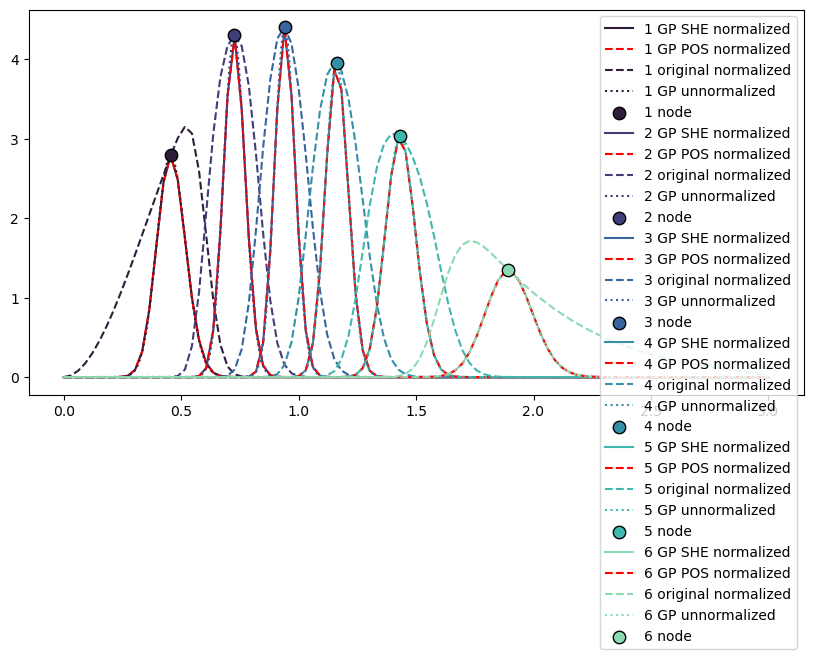

In [7]:
import numpy as np
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
from multiprocessing import get_context
import time
import corner
import matplotlib.pyplot as plt

from nautilus import Prior
from nautilus import Sampler
from scipy.stats import norm
# Import euclidlib for reading the Euclid data
import euclidlib as el
import seaborn as sns

# Import cloelib for cosmology and theoretical predictions
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations

# Import cloelike for likelihoods
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt, EuclidLikelihood_WL

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared,
    DotProduct, ConstantKernel as C
)

myz = np.linspace(1e-4, 3.0, 100)
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized
full_cov=np.load('/home/jipdebuck/covariance_Gauss_DR1_TR1like_1589_2D.npz')['Gauss']

# Get n(z)
z_nz, nz_heracles = el.phz.redshift_distributions('/home/jipdebuck/nz_example.fits')


# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_heracles, z_nz)
dndz_she_norm = normalize_dndz(nz_heracles, z_nz)

# Find boundaries for x-nodes priors 
i_lows_pos = {}
i_highs_pos = {}
for key, nz in dndz_pos_norm.items():
    nz_max = np.max(nz)
    mask = np.where(nz > 0.5 * nz_max)[0]
    i_lows_pos.update({key: mask[0]})
    i_highs_pos.update({key: mask[-1]})
z_lows_pos = z_nz[[i_lows_pos[key] for key in dndz_pos_norm.keys()]]
z_highs_pos = z_nz[[i_highs_pos[key] for key in dndz_pos_norm.keys()]]

i_lows_she = {}
i_highs_she = {}
for key, nz in dndz_she_norm.items():
    nz_max = np.max(nz)
    mask = np.where(nz > 0.5 * nz_max)[0]
    i_lows_she.update({key: mask[0]})
    i_highs_she.update({key: mask[-1]})
z_lows_she = z_nz[[i_lows_she[key] for key in dndz_she_norm.keys()]]
z_highs_she = z_nz[[i_highs_she[key] for key in dndz_she_norm.keys()]]


# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values())) #stacking arrays vertically
    my_dndz_norm = np.zeros([len(nz_example), len(myz)]) #creating an empty array
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :]) #interpolating to new myz values
    return my_dndz_norm

my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, myz)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, myz)


def build_gp_nz(n_med, z_med, corr_len, delta_x, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds):
    gp_priors = {}
    gp_predictions = {}
    for i, nz in enumerate(n_med):
        corr_len_scale = corr_len*delta_x[i]
        if kernel_class == Matern:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len_scale, nu=nu, length_scale_bounds="fixed")
        else:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len_scale, length_scale_bounds="fixed")
        gp = GaussianProcessRegressor(kernel=kernel, optimizer=None, normalize_y=False, alpha=alpha)
        X_train = np.array([np.log1p(z_bounds[0])/np.log1p(z_bounds[1]), np.log1p(z_med[i])/np.log1p(z_bounds[1]), np.log1p(z_bounds[1])/np.log1p(z_bounds[1])]).reshape(-1, 1)
        y_train = np.array([0.0, nz, 0.0])
        gp.fit(X_train, y_train)
        x_pred = np.log1p(z_pred)/np.log1p(z_bounds[1])
        x_pred = np.array(x_pred).reshape(-1, 1)
        y_pred, y_std = gp.predict(x_pred, return_std=True)
        gp_priors[i] = gp
        gp_predictions[i] = (y_pred, y_std)
    return gp_priors, gp_predictions

z_meds_she = []   # positions of median redshift for each bin
n_meds_she = []   # height of n(z) at median redshift for each bin
z_meds_pos = []
n_meds_pos = []

for key, nz in dndz_she_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med = np.interp(0.5, cdf, z_nz)
    n_med = nz[np.argmin(np.abs(z_nz - z_med))]
    z_meds_she.append(z_med)
    n_meds_she.append(n_med)
    
for key, nz in dndz_pos_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med_pos = np.interp(0.5, cdf, z_nz)
    n_med_pos = nz[np.argmin(np.abs(z_nz - z_med_pos))] # subtract by z_med_*pos*
    z_meds_pos.append(z_med_pos)
    n_meds_pos.append(n_med_pos)

log_l_she = np.log(0.2)
corr_len = np.exp(log_l_she)                            # correlation length for the GP kernel
z_bounds = (0,3)                              # bounds for the redshift
z_pred = np.linspace(0, 3, 400)       # prediction points for GP
alpha = 1e-8                                  # noise level during fitting 
kernel_class = RBF
nu = 1.5                                      # necessary for Matern only, defines smoothness 
const_value = 0.04                            # amplitude of constant kernel
const_bounds = (1e-4, 1.0)                    # bounds for constant kernel amplitude
# We read with euclidlib v2025.2 (v2025.1 is also compatible)
z_pred_res = z_pred.reshape(-1, 1)
widths_she = np.array([z_highs_she[0]-z_lows_she[0], z_highs_she[1]-z_lows_she[1], z_highs_she[2]-z_lows_she[2], z_highs_she[3]-z_lows_she[3], z_highs_she[4]-z_lows_she[4], z_highs_she[5]-z_lows_she[5]])
widths_pos = np.array([z_highs_pos[0]-z_lows_pos[0], z_highs_pos[1]-z_lows_pos[1], z_highs_pos[2]-z_lows_pos[2], z_highs_pos[3]-z_lows_pos[3], z_highs_pos[4]-z_lows_pos[4], z_highs_pos[5]-z_lows_pos[5]])

delta_x_she = []
for i in range(len(n_meds_she)):
    z_low_she = z_meds_she[i] - widths_she[i]/2
    z_high_she = z_meds_she[i] + widths_she[i]/2
    dx_she = (np.log1p(z_high_she) - np.log1p(z_low_she)) / np.log1p(z_bounds[1])
    delta_x_she.append(dx_she)

delta_x_pos = []
for i in range(len(n_meds_pos)):
    z_low_pos = z_meds_pos[i] - widths_pos[i]/2
    z_high_pos = z_meds_pos[i] + widths_pos[i]/2
    dx_pos = (np.log1p(z_high_pos) - np.log1p(z_low_pos)) / np.log1p(z_bounds[1])
    delta_x_pos.append(dx_pos)

def resample_dndz_gp(gp_predictions, z_pred, zs):
#    gp_predictions_norm = {}
#    for key in gp_predictions.keys():
#        gp_predictions_norm[key] = gp_predictions[key][0]/integrate.trapezoid(gp_predictions[key][0], z_pred[:,0])
    my_dndz = np.vstack([gp_predictions[i][0] for i in sorted(gp_predictions.keys())])
    my_dndz_norm = np.zeros([len(gp_predictions), len(zs)])
    for i in range(len(gp_predictions)):
        # gp_predictions[i][0] is 1D array of n(z) for bin i

        my_dndz_norm[i, :] = np.interp(zs, z_pred[:,0], my_dndz[i, :])
    
    return my_dndz_norm

print('delta_x_she:', delta_x_she)
print('delta_x_pos:', delta_x_pos)


priors_she, predictions_she = build_gp_nz(n_meds_she, z_meds_she, corr_len, delta_x_she, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)
my_dndz_norm_gp_she = resample_dndz_gp(predictions_she, z_pred_res, myz)
priors_pos, predictions_pos = build_gp_nz(n_meds_pos, z_meds_pos, corr_len, delta_x_pos, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds)
my_dndz_norm_gp_pos = resample_dndz_gp(predictions_pos, z_pred_res, myz)
print('my_dndz_norm_gp_she:', my_dndz_norm_gp_she)
palette = sns.color_palette("mako", 6)
fig, ax = plt.subplots(figsize=(10, 5))

for j, nz in enumerate(n_meds_she):
    y_pred, y_std = predictions_she[j]
    X_train, y_train = z_meds_she[j], n_meds_she[j]
    ax.plot(myz, my_dndz_norm_gp_she[j], color=palette[j],label=f"{j+1} GP SHE normalized")
    ax.plot(myz, my_dndz_norm_gp_pos[j], color='red',linestyle='--', label=f"{j+1} GP POS normalized")
    ax.plot(myz, my_dndz_she_norm[j], color=palette[j], linestyle='--', label=f"{j+1} original normalized")
#    ax.fill_between(z_pred.ravel(), (y_pred - y_std).ravel(), (y_pred + y_std).ravel(),
#                    color=palette[j], alpha=0.2)

    ax.plot(z_pred, y_pred, color=palette[j], linestyle=':', label=f"{j+1} GP unnormalized")
    ax.scatter(X_train, y_train, color=palette[j], edgecolor='black', s=80, zorder=3, label=f"{j+1} node")
ax.legend()

In [13]:
import numpy as np
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
from multiprocessing import get_context
import time
import corner
import matplotlib.pyplot as plt

from nautilus import Prior
from nautilus import Sampler
from scipy.stats import norm
# Import euclidlib for reading the Euclid data
import euclidlib as el

# Import cloelib for cosmology and theoretical predictions
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations

# Import cloelike for likelihoods
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt, EuclidLikelihood_WL

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared,
    DotProduct, ConstantKernel as C
)

myz = np.linspace(1e-4, 3.0, 100)
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized
full_cov=np.load('/home/jipdebuck/covariance_Gauss_DR1_TR1like_1589_2D.npz')['Gauss']

# Get n(z)
z_nz, nz_heracles = el.phz.redshift_distributions('/home/jipdebuck/nz_example.fits')


# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_heracles, z_nz)
dndz_she_norm = normalize_dndz(nz_heracles, z_nz)

# Find boundaries for x-nodes priors 
i_lows_pos = {}
i_highs_pos = {}
for key, nz in dndz_pos_norm.items():
    nz_max = np.max(nz)
    mask = np.where(nz > 0.5 * nz_max)[0]
    i_lows_pos.update({key: mask[0]})
    i_highs_pos.update({key: mask[-1]})
z_lows_pos = z_nz[[i_lows_pos[key] for key in dndz_pos_norm.keys()]]
z_highs_pos = z_nz[[i_highs_pos[key] for key in dndz_pos_norm.keys()]]

i_lows_she = {}
i_highs_she = {}
for key, nz in dndz_she_norm.items():
    nz_max = np.max(nz)
    mask = np.where(nz > 0.5 * nz_max)[0]
    i_lows_she.update({key: mask[0]})
    i_highs_she.update({key: mask[-1]})
z_lows_she = z_nz[[i_lows_she[key] for key in dndz_she_norm.keys()]]
z_highs_she = z_nz[[i_highs_she[key] for key in dndz_she_norm.keys()]]


# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values())) #stacking arrays vertically
    my_dndz_norm = np.zeros([len(nz_example), len(myz)]) #creating an empty array
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :]) #interpolating to new myz values
    return my_dndz_norm

my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, myz)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, myz)


def build_gp_nz(n_med, z_med, corr_len, delta_x, z_bounds, z_pred, alpha, kernel_class, nu, const_value, const_bounds):
    gp_priors = {}
    gp_predictions = {}
    for i, nz in enumerate(n_med):
        corr_len_scale = corr_len*delta_x[i]
        if kernel_class == Matern:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len_scale, nu=nu, length_scale_bounds="fixed")
        else:
            kernel = C(const_value, const_bounds) * kernel_class(length_scale=corr_len_scale, length_scale_bounds="fixed")
        gp = GaussianProcessRegressor(kernel=kernel, optimizer=None, normalize_y=False, alpha=alpha)
        X_train = np.array([np.log1p(z_bounds[0])/np.log1p(z_bounds[1]), np.log1p(z_med[i])/np.log1p(z_bounds[1]), np.log1p(z_bounds[1])/np.log1p(z_bounds[1])]).reshape(-1, 1)
        y_train = np.array([0.0, nz, 0.0])
        gp.fit(X_train, y_train)
        x_pred = np.log1p(z_pred)/np.log1p(z_bounds[1])
        x_pred = np.array(x_pred).reshape(-1, 1)
        y_pred, y_std = gp.predict(x_pred, return_std=True)
        gp_priors[i] = gp
        gp_predictions[i] = (y_pred, y_std)
    return gp_priors, gp_predictions

z_meds_she = []   # positions of median redshift for each bin
n_meds_she = []   # height of n(z) at median redshift for each bin
z_meds_pos = []
n_meds_pos = []

for key, nz in dndz_she_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med = np.interp(0.5, cdf, z_nz)
    n_med = nz[np.argmin(np.abs(z_nz - z_med))]
    z_meds_she.append(z_med)
    n_meds_she.append(n_med)
    
for key, nz in dndz_pos_norm.items():
    # --- CDF & median node ---
    cdf = integrate.cumulative_trapezoid(nz, z_nz, initial=0)
    cdf /= cdf[-1]
    z_med_pos = np.interp(0.5, cdf, z_nz)
    n_med_pos = nz[np.argmin(np.abs(z_nz - z_med_pos))] # subtract by z_med_*pos*
    z_meds_pos.append(z_med_pos)
    n_meds_pos.append(n_med_pos)

corr_len = 0.04                              # correlation length for the GP kernel
z_bounds = (0,3)                              # bounds for the redshift
z_pred = np.linspace(0, 3, 400)       # prediction points for GP
alpha = 1e-8                                  # noise level during fitting 
kernel_class = RBF
nu = 1.5                                      # necessary for Matern only, defines smoothness 
const_value = 0.04                            # amplitude of constant kernel
const_bounds = (1e-4, 1.0)                    # bounds for constant kernel amplitude
# We read with euclidlib v2025.2 (v2025.1 is also compatible)
z_pred_res = z_pred.reshape(-1, 1)
widths_she = np.array([z_highs_she[0]-z_lows_she[0], z_highs_she[1]-z_lows_she[1], z_highs_she[2]-z_lows_she[2], z_highs_she[3]-z_lows_she[3], z_highs_she[4]-z_lows_she[4], z_highs_she[5]-z_lows_she[5]])
widths_pos = np.array([z_highs_pos[0]-z_lows_pos[0], z_highs_pos[1]-z_lows_pos[1], z_highs_pos[2]-z_lows_pos[2], z_highs_pos[3]-z_lows_pos[3], z_highs_pos[4]-z_lows_pos[4], z_highs_pos[5]-z_lows_pos[5]])

delta_x_she = []
for i in range(len(n_meds_she)):
    z_low_she = z_meds_she[i] - widths_she[i]/2
    z_high_she = z_meds_she[i] + widths_she[i]/2
    dx_she = (np.log1p(z_high_she) - np.log1p(z_low_she)) / np.log1p(z_bounds[1])
    delta_x_she.append(dx_she)

delta_x_pos = []
for i in range(len(n_meds_pos)):
    z_low_pos = z_meds_pos[i] - widths_pos[i]/2
    z_high_pos = z_meds_pos[i] + widths_pos[i]/2
    dx_pos = (np.log1p(z_high_pos) - np.log1p(z_low_pos)) / np.log1p(z_bounds[1])
    delta_x_pos.append(dx_pos)
    
name_to_chain_gp = '3x2pt_LCDM_DR1_GP_width'

#cells_data = el.photo.harmonic_space.angular_power_spectra('/disks/shear16/canasherrera/SheariouslyCalibrated/data/DR1/synthetic_angular_spectra_DR1.fits')

fiducial_cosmology = {
    'H0': 67,                # Hubble constant
    'Omega_cdm0': 0.27,        # Cold dark matter density
    'Omega_b0': 0.049,         # Baryon density
    'Omega_k0': 0.0,           # Curvature
    'mnu': 0.077,                # Neutrino mass
    'w0': -1.0,                # Dark energy equation of state (present)
    'wa': 0.0,                 # Dark energy equation of state (evolution)
    'ns': 0.96,                # Scalar spectral index
    'As': 2.1e-9, # Scalar amplitude
    'gamma_MG': 0.545,         # Modified gravity parameter
    'log10TAGN': 7.75,          # AGN feedback parameter
    'N_mnu': 1,                  # Number of massive neutrino species
    'N_eff': 3.046             # Effective number of relativistic species
}

fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    # Magnification bias (per bin)
    'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
    'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
    'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
    'magnification_bias_7': 0.0, 'magnification_bias_8': 0.0,
    'magnification_bias_9': 0.0, 'magnification_bias_10': 0.0,
    'magnification_bias_11': 0.0, 'magnification_bias_12': 0.0,
    'magnification_bias_13': 0.0,
    # Redshift errors (positions)
    'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 
    'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
    'dz_pos_7': 0.0, 'dz_pos_8': 0.0, 'dz_pos_9': 0.0, 
    'dz_pos_10': 0.0, 'dz_pos_11': 0.0, 'dz_pos_12': 0.0,
    'dz_pos_13': 0.0,
    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
    'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
    'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
    'multiplicative_bias_7': 0.0, 'multiplicative_bias_8': 0.0,
    'multiplicative_bias_9': 0.0, 'multiplicative_bias_10': 0.0,
    'multiplicative_bias_11': 0.0, 'multiplicative_bias_12': 0.0,
    'multiplicative_bias_13': 0.0,
    # Redshift errors (shear)
    'dz_shear_1': 0.0, 'dz_shear_2': 0.0, 'dz_shear_3': 0.0,
    'dz_shear_4': 0.0, 'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
    'dz_shear_7': 0.0, 'dz_shear_8': 0.0, 'dz_shear_9': 0.0, 
    'dz_shear_10': 0.0, 'dz_shear_11': 0.0, 'dz_shear_12': 0.0,
    'dz_shear_13': 0.0
}

ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])

# --- Cosmology and Tracers: Easy to Change! ---

# Choose which perturbation model to use: 'linear' or 'nonlinear'
perturbation_model = 'nonlinear'  # change to 'linear' if needed

# Cosmology parameters (easy to modify)
cosmo_params = fiducial_cosmology.copy()
nuisance_params = fiducial_nuisance.copy()

# Create background
background = CAMBBackground(
    H0=cosmo_params['H0'],
    Omega_cdm0=cosmo_params['Omega_cdm0'],
    Omega_b0=cosmo_params['Omega_b0'],
    w0=cosmo_params['w0'],
    wa=cosmo_params['wa'],
    Omega_k0=cosmo_params['Omega_k0'],
    ns=cosmo_params['ns'],
    As=cosmo_params['As'],
    mnu=cosmo_params['mnu'],
    gamma_MG=cosmo_params['gamma_MG'],
    N_mnu=cosmo_params['N_mnu']
)

# Choose perturbations
if perturbation_model == 'linear':
    perturbations = HMemuLinearPerturbations(background, myz)
else:
    perturbations = HMemuNonLinearPerturbations(
        background, 
        HMemuLinearPerturbations(background, myz), 
        myz, 
        log10TAGN=cosmo_params['log10TAGN']
    )

def resample_dndz_gp(gp_predictions, z_pred, zs):
#    gp_predictions_norm = {}
#    for key in gp_predictions.keys():
#        gp_predictions_norm[key] = gp_predictions[key][0]/integrate.trapezoid(gp_predictions[key][0], z_pred[:,0])
    my_dndz = np.vstack([gp_predictions[i][0] for i in sorted(gp_predictions.keys())])
    my_dndz_norm = np.zeros([len(gp_predictions), len(zs)])
    for i in range(len(gp_predictions)):
        # gp_predictions[i][0] is 1D array of n(z) for bin i

        my_dndz_norm[i, :] = np.interp(zs, z_pred[:,0], my_dndz[i, :])
    
    return my_dndz_norm

tracer_pos = PositionsTracer(
    perturbations=perturbations,
    dndz=my_dndz_pos_norm,
    z=myz,
    galaxy_bias_model='poly',
    nuisance_params=nuisance_params
)

tracer_she = ShearTracer(
    perturbations=perturbations,
    dndz=my_dndz_she_norm,
    z=myz,
    nuisance_params=nuisance_params
)


cls_sheshe = AngularTwoPoint(tracer_she, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_posshe = AngularTwoPoint(tracer_pos, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_pospos = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl(ell_theory, 0, perturbations.k)
#print(cls_sheshe[('SHE', 'SHE', 1,1)], len(ell_theory))

# Combine all spectra into a single dictionary for easy access
uncoupled_cls = {**cls_posshe, **cls_sheshe, **cls_pospos}

def build_data(cls, mapa_key, cov, zs, nzs, include_pos=False, include_she=False):
    data = {
        'cells': cls,
        'ells': cls[mapa_key].ell,
        'z_arr': zs,
        'cov': cov,
        'mixmat': {},
    }
    if include_pos:
        data['dndz_pos'] = nzs[0]
    if include_she:
        data['dndz_she'] = nzs[1]
    return data

def build_settings(cls):
    for key in cls:
        if key[:2] == ('POS', 'POS'):
            scale_cuts = {key: [10, 750] for key in cls}
        else:
            scale_cuts = {key: [10, 1500] for key in cls}
    return {'n_ell_bins': 32, 'scale_cuts': scale_cuts}

data_3x2pt = build_data(uncoupled_cls, ('SHE', 'SHE', 1, 1), 
                             full_cov, 
                             myz, [my_dndz_pos_norm, my_dndz_she_norm],
                             include_pos=True, include_she=True)
settings_3x2pt  = build_settings(uncoupled_cls)

like_instance = EuclidLikelihood_3x2pt(
        data=data_3x2pt,
        settings=settings_3x2pt,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
        mode="uncoupled"

    )

loglike = like_instance.loglike(fiducial_cosmology | fiducial_nuisance)
print("✨ Log-likelihood at fiducial: ", loglike)


# Priors
zmean_dr1 = np.array([0.4371, 0.726, 0.9424, 1.164, 1.437, 1.963])

prior_gp = Prior()
prior_gp.add_parameter('Omega_b0', dist=(0.01, 0.1))
prior_gp.add_parameter('Omega_cdm0', dist=(0.1, 0.8))
prior_gp.add_parameter('logAs', dist=(np.log(0.6e-9*1e10), np.log(5e-9*1e10)))
prior_gp.add_parameter('ns', dist=(0.6, 1.2))
prior_gp.add_parameter('H0', dist=(50, 90))
prior_gp.add_parameter('AIA', dist=(-1, 1))
prior_gp.add_parameter('EtaIA', dist=(-5, 5))
#prior_gp.add_parameter('w0', dist=(-3.0, -0.5))
#prior_gp.add_parameter('wa', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly0', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly1', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly2', dist=(-3.0, 3.0))
prior_gp.add_parameter('b1_photo_poly3', dist=(-3.0, 3.0))
prior_gp.add_parameter('multiplicative_bias_1', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_2', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_3', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_4', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_5', norm(loc=0.0, scale=0.01))
prior_gp.add_parameter('multiplicative_bias_6', norm(loc=0.0, scale=0.01)) 
prior_gp.add_parameter('magnification_bias_1', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_2', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_3', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_4', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_5', dist=(-2.0, 2.0))
prior_gp.add_parameter('magnification_bias_6', dist=(-2.0, 2.0))
#prior.add_parameter('dz_pos_1', norm(loc=0.0, scale=0.002*(1+zmean_dr1[0])))
#prior.add_parameter('dz_pos_2', norm(loc=0.0, scale=0.002*(1+zmean_dr1[1])))
#prior.add_parameter('dz_pos_3', norm(loc=0.0, scale=0.002*(1+zmean_dr1[2])))
#prior.add_parameter('dz_pos_4', norm(loc=0.0, scale=0.002*(1+zmean_dr1[3])))
#prior.add_parameter('dz_pos_5', norm(loc=0.0, scale=0.002*(1+zmean_dr1[4])))
#prior.add_parameter('dz_pos_6', norm(loc=0.0, scale=0.002*(1+zmean_dr1[5])))
#prior.add_parameter('dz_shear_1', norm(loc=0.0, scale=0.002*(1+zmean_dr1[0])))
#prior.add_parameter('dz_shear_2', norm(loc=0.0, scale=0.002*(1+zmean_dr1[1])))
#prior.add_parameter('dz_shear_3', norm(loc=0.0, scale=0.002*(1+zmean_dr1[2])))
#prior.add_parameter('dz_shear_4', norm(loc=0.0, scale=0.002*(1+zmean_dr1[3])))
#prior.add_parameter('dz_shear_5', norm(loc=0.0, scale=0.002*(1+zmean_dr1[4])))
#prior.add_parameter('dz_shear_6', norm(loc=0.0, scale=0.002*(1+zmean_dr1[5])))
prior_gp.add_parameter('x1_she', dist= (z_lows_she[0], z_highs_she[0]))
prior_gp.add_parameter('x2_she', dist= (z_lows_she[1], z_highs_she[1]))
prior_gp.add_parameter('x3_she', dist= (z_lows_she[2], z_highs_she[2]))
prior_gp.add_parameter('x4_she', dist= (z_lows_she[3], z_highs_she[3]))
prior_gp.add_parameter('x5_she', dist= (z_lows_she[4], z_highs_she[4]))
prior_gp.add_parameter('x6_she', dist= (z_lows_she[5], z_highs_she[5]))
prior_gp.add_parameter('y1_she', dist= (n_meds_she[0]-1, n_meds_she[0]+1))
prior_gp.add_parameter('y2_she', dist= (n_meds_she[1]-1, n_meds_she[1]+1))
prior_gp.add_parameter('y3_she', dist= (n_meds_she[2]-1, n_meds_she[2]+1))
prior_gp.add_parameter('y4_she', dist= (n_meds_she[3]-1, n_meds_she[3]+1))
prior_gp.add_parameter('y5_she', dist= (n_meds_she[4]-1, n_meds_she[4]+1))
prior_gp.add_parameter('y6_she', dist= (n_meds_she[5]-1, n_meds_she[5]+1))
prior_gp.add_parameter('log_l_she', dist=(np.log(0.001), np.log(1)))
prior_gp.add_parameter('x1_pos', dist= (z_lows_pos[0], z_highs_pos[0]))
prior_gp.add_parameter('x2_pos', dist= (z_lows_pos[1], z_highs_pos[1]))
prior_gp.add_parameter('x3_pos', dist= (z_lows_pos[2], z_highs_pos[2]))
prior_gp.add_parameter('x4_pos', dist= (z_lows_pos[3], z_highs_pos[3]))
prior_gp.add_parameter('x5_pos', dist= (z_lows_pos[4], z_highs_pos[4]))
prior_gp.add_parameter('x6_pos', dist= (z_lows_pos[5], z_highs_pos[5]))
prior_gp.add_parameter('y1_pos', dist= (n_meds_pos[0]-1, n_meds_pos[0]+1))
prior_gp.add_parameter('y2_pos', dist= (n_meds_pos[1]-1, n_meds_pos[1]+1))
prior_gp.add_parameter('y3_pos', dist= (n_meds_pos[2]-1, n_meds_pos[2]+1))
prior_gp.add_parameter('y4_pos', dist= (n_meds_pos[3]-1, n_meds_pos[3]+1))
prior_gp.add_parameter('y5_pos', dist= (n_meds_pos[4]-1, n_meds_pos[4]+1))
prior_gp.add_parameter('y6_pos', dist= (n_meds_pos[5]-1, n_meds_pos[5]+1))
prior_gp.add_parameter('log_l_pos', dist=(np.log(0.001), np.log(1)))

print("✨ Prior set up completed.")
print("Parameters sampled: ", prior_gp.keys)
print("Number of sampled parameters:", len(prior_gp.keys))
default_pars = fiducial_cosmology | fiducial_nuisance

def like_Naut_test_gp(param_dict):

    print("\n--- New likelihood call ---")

    # ========== CHECK INPUT PARAMS ==========
    for k, v in param_dict.items():
        if not np.isfinite(v):
            print(f"Non-finite parameter {k} = {v}")
            return (-np.inf, 0)

    # ============================
    # SHEAR
    # ============================

    l_she = np.exp(param_dict["log_l_she"])
    if not np.isfinite(l_she):
        print("l_she is non-finite")
        return (-np.inf, 0)

    z_meds_she[:] = [
        param_dict[f"x{i}_she"] for i in range(1,7)
    ]

    if not np.all(np.isfinite(z_meds_she)):
        print("Non-finite z_meds_she:", z_meds_she)
        return (-np.inf, 0)

    if not np.all(np.diff(z_meds_she) > 0):
        print("Non-monotonic z_meds_she:", z_meds_she)
        return (-np.inf, 0)

    n_meds_she[:] = [
        param_dict[f"y{i}_she"] for i in range(1,7)
    ]

    if not np.all(np.isfinite(n_meds_she)):
        print("Non-finite n_meds_she:", n_meds_she)
        return (-np.inf, 0)

    # ============================
    # POSITION
    # ============================

    l_pos = np.exp(param_dict["log_l_pos"])
    if not np.isfinite(l_pos):
        print("l_pos is non-finite")
        return (-np.inf, 0)

    z_meds_pos[:] = [
        param_dict[f"x{i}_pos"] for i in range(1,7)
    ]

    if not np.all(np.isfinite(z_meds_pos)):
        print("Non-finite z_meds_pos:", z_meds_pos)
        return (-np.inf, 0)

    if not np.all(np.diff(z_meds_pos) > 0):
        print("Non-monotonic z_meds_pos:", z_meds_pos)
        return (-np.inf, 0)

    n_meds_pos[:] = [
        param_dict[f"y{i}_pos"] for i in range(1,7)
    ]

    if not np.all(np.isfinite(n_meds_pos)):
        print("Non-finite n_meds_pos:", n_meds_pos)
        return (-np.inf, 0)

    # ============================
    # BUILD GPs
    # ============================

    try:
        priors_she, predictions_she = build_gp_nz(
            n_meds_she, z_meds_she, l_she,
            delta_x_she, z_bounds, z_pred,
            alpha, kernel_class, nu,
            const_value, const_bounds
        )
    except Exception as e:
        print("GP shear failed:", e)
        return (-np.inf, 0)

    try:
        my_dndz_norm_gp_she = resample_dndz_gp(
            predictions_she, z_pred_res, myz
        )
    except Exception as e:
        print("Resample shear failed:", e)
        return (-np.inf, 0)

    if not np.all(np.isfinite(my_dndz_norm_gp_she)):
        print("NaNs in shear dndz")
        return (-np.inf, 0)

    # ----- POSITION -----

    try:
        priors_pos, predictions_pos = build_gp_nz(
            n_meds_pos, z_meds_pos, l_pos,
            delta_x_pos, z_bounds, z_pred,
            alpha, kernel_class, nu,
            const_value, const_bounds
        )
    except Exception as e:
        print("GP pos failed:", e)
        return (-np.inf, 0)

    try:
        my_dndz_norm_gp_pos = resample_dndz_gp(
            predictions_pos, z_pred_res, myz
        )
    except Exception as e:
        print("Resample pos failed:", e)
        return (-np.inf, 0)

    if not np.all(np.isfinite(my_dndz_norm_gp_pos)):
        print("NaNs in pos dndz")
        return (-np.inf, 0)

    # ============================
    # COSMOLOGY
    # ============================

    pars_in = default_pars.copy()
    pars_in.update(param_dict)

    As = np.exp(param_dict['logAs']) * 1e-10
    if not np.isfinite(As):
        print("As is non-finite")
        return (-np.inf, 0)

    pars_in['As'] = As

    like_instance.data.update({
        'dndz_she': my_dndz_norm_gp_she,
        'dndz_pos': my_dndz_norm_gp_pos
    })

    try:
        logL = like_instance.loglike(pars_in)
    except Exception as e:
        print("Cosmo loglike crashed:", e)
        return (-np.inf, 0)

    if not np.isfinite(logL):
        print("Cosmo loglike returned non-finite:", logL)
        return (-np.inf, 0)

    sigma8 = like_instance.derived.get('sigma8_0', 0)

    print("logL =", logL)

    return (logL, sigma8)

blob_vec     = [('sigma8_0', float)]


sampler = Sampler(prior_gp, like_Naut_test_gp, 
                              n_live=1000,
                              blobs_dtype=blob_vec,
                              filepath=name_to_chain_gp + '.h5', 
            resume=True)
t_start = time.time()
print('Starting sampling...')
sampler.run(verbose=True)
t_end = time.time()
total_seconds = t_end - t_start
days = int(total_seconds // 86400)
hours = int((total_seconds % 86400) // 3600)
minutes = int((total_seconds % 3600) // 60)
seconds = int(total_seconds % 60)
print(f'Total time: {days}d {hours}h {minutes}m {seconds}s')
print('Sampling finished!')
print('Saving chains...')

points, log_w, log_l, derived = sampler.posterior(return_blobs=True)
log_z = sampler.log_z

        # --- Sampled parameters ---
param_names = list(prior_gp.keys)
chain_dict = {
            name: points[:, i]
            for i, name in enumerate(param_names)
        }

        # --- Derived parameters ---
derived_names = [name for name, _ in blob_vec]

derived_dict = {
            derived_names[0]: np.array([sample[0] for sample in derived])
        }

        # --- Save everything in a labelled way ---
np.savez_compressed(
            name_to_chain_gp + '.npz',
            chain=chain_dict,
            derived=derived_dict,
            weights=log_w,
            logl=log_l,
            logz=log_z,
            param_names=param_names,
            derived_names=derived_names
        )

print('Chains saved with name:', name_to_chain_gp + '.npz')

✨ Log-likelihood at fiducial:  0.0
✨ Prior set up completed.
Parameters sampled:  ['Omega_b0', 'Omega_cdm0', 'logAs', 'ns', 'H0', 'AIA', 'EtaIA', 'b1_photo_poly0', 'b1_photo_poly1', 'b1_photo_poly2', 'b1_photo_poly3', 'multiplicative_bias_1', 'multiplicative_bias_2', 'multiplicative_bias_3', 'multiplicative_bias_4', 'multiplicative_bias_5', 'multiplicative_bias_6', 'magnification_bias_1', 'magnification_bias_2', 'magnification_bias_3', 'magnification_bias_4', 'magnification_bias_5', 'magnification_bias_6', 'x1_she', 'x2_she', 'x3_she', 'x4_she', 'x5_she', 'x6_she', 'y1_she', 'y2_she', 'y3_she', 'y4_she', 'y5_she', 'y6_she', 'log_l_she', 'x1_pos', 'x2_pos', 'x3_pos', 'x4_pos', 'x5_pos', 'x6_pos', 'y1_pos', 'y2_pos', 'y3_pos', 'y4_pos', 'y5_pos', 'y6_pos', 'log_l_pos']
Number of sampled parameters: 49
Starting sampling...
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z  

/home/jipdebuck/miniconda3/envs/venv_310/lib/python3.10/site-packages/cosmopower/cosmopower_NN.py:378: RuntimeWarning: overflow encountered in exp
  layers.append((self.betas_[i] + (1.-self.betas_[i])*1./(1.+np.exp(-self.alphas_[i]*act[-1])))*act[-1])


logL = -2181233.6201848118

--- New likelihood call ---
logL = -1677964.945418692

--- New likelihood call ---
logL = -587994301.9571475

--- New likelihood call ---
logL = -22588532.34584045

--- New likelihood call ---
logL = -218751095.18546364

--- New likelihood call ---
logL = -617020186726.4482

--- New likelihood call ---
logL = -3915394720.166584

--- New likelihood call ---
Cosmo loglike returned non-finite: nan

--- New likelihood call ---
logL = -120542070.26899506

--- New likelihood call ---
logL = -326706.5026147221

--- New likelihood call ---
logL = -7752289.714235309

--- New likelihood call ---
logL = -68577881.53127386

--- New likelihood call ---
logL = -61441187551.20041

--- New likelihood call ---
logL = -43890138.24488007

--- New likelihood call ---
logL = -61380937.27462372

--- New likelihood call ---
logL = -172227464.63020408

--- New likelihood call ---
logL = -2123804781.2712982

--- New likelihood call ---
Cosmo loglike returned non-finite: nan

--- New

/home/jipdebuck/miniconda3/envs/venv_310/lib/python3.10/site-packages/cosmopower/cosmopower_NN.py:378: RuntimeWarning: overflow encountered in exp
  layers.append((self.betas_[i] + (1.-self.betas_[i])*1./(1.+np.exp(-self.alphas_[i]*act[-1])))*act[-1])


logL = -1952619159.5300431

--- New likelihood call ---
logL = -2874709642.7656336

--- New likelihood call ---
logL = -9166696861.782299

--- New likelihood call ---
logL = -167279888.2843987

--- New likelihood call ---
logL = -40166.11837100182

--- New likelihood call ---
logL = -123417178.28005083

--- New likelihood call ---
logL = -3917092624.337986

--- New likelihood call ---
logL = -54168417.793068886

--- New likelihood call ---
logL = -70399448619.99962

--- New likelihood call ---
logL = -400560111.361006

--- New likelihood call ---
logL = -41571362.343166955

--- New likelihood call ---
logL = -41781064.11336633

--- New likelihood call ---
logL = -83672.8111687098

--- New likelihood call ---
logL = -1370530.8170455466

--- New likelihood call ---
logL = -24120382276.043457

--- New likelihood call ---
logL = -964534714.4376479

--- New likelihood call ---
logL = -6911158621.848543

--- New likelihood call ---
logL = -212665271.79498136

--- New likelihood call ---
logL

...

/home/jipdebuck/miniconda3/envs/venv_310/lib/python3.10/site-packages/cosmopower/cosmopower_NN.py:378: RuntimeWarning: overflow encountered in exp
  layers.append((self.betas_[i] + (1.-self.betas_[i])*1./(1.+np.exp(-self.alphas_[i]*act[-1])))*act[-1])


logL = -6191786.194185662

--- New likelihood call ---
logL = -3089141751.040327

--- New likelihood call ---
logL = -140172.32112786203

--- New likelihood call ---
logL = -477106227.4363979

--- New likelihood call ---
logL = -41155442775.88475

--- New likelihood call ---
logL = -661033242.4945986

--- New likelihood call ---
logL = -642677.7420777678

--- New likelihood call ---
Cosmo loglike returned non-finite: nan

--- New likelihood call ---
logL = -61578743.055290446

--- New likelihood call ---
logL = -169225281470.97495

--- New likelihood call ---
logL = -34082618256.668552

--- New likelihood call ---
logL = -30695271989.715317

--- New likelihood call ---
logL = -1298355928.1845617

--- New likelihood call ---
logL = -1192703906297.5054

--- New likelihood call ---
logL = -10322216174.319883

--- New likelihood call ---
logL = -118652258.52339484

--- New likelihood call ---
logL = -59071.42743976903

--- New likelihood call ---
logL = -9777176024.304428

--- New likeliho

/home/jipdebuck/miniconda3/envs/venv_310/lib/python3.10/site-packages/cosmopower/cosmopower_NN.py:378: RuntimeWarning: overflow encountered in exp
  layers.append((self.betas_[i] + (1.-self.betas_[i])*1./(1.+np.exp(-self.alphas_[i]*act[-1])))*act[-1])


logL = -1916082762.4949663

--- New likelihood call ---
logL = -336788112947.45654

--- New likelihood call ---
logL = -1082513923.5356722

--- New likelihood call ---
logL = -1799892105.3051887

--- New likelihood call ---
logL = -1457377.7073115048

--- New likelihood call ---
logL = -576010147.669404

--- New likelihood call ---
logL = -20169263.616587404

--- New likelihood call ---
logL = -41689156.541326106

--- New likelihood call ---


KeyboardInterrupt: 

### Removing bins from data for tests

In [32]:
#import os
#os.environ["OMP_NUM_THREADS"] = "1"
#os.environ["OPENBLAS_NUM_THREADS"] = "1"
#os.environ["MKL_NUM_THREADS"] = "1"
#os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
#os.environ["NUMEXPR_NUM_THREADS"] = "1"


import numpy as np
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
from multiprocessing import get_context
import time
import corner
import matplotlib.pyplot as plt

from nautilus import Prior
from nautilus import Sampler
from scipy.stats import norm
# Import euclidlib for reading the Euclid data
import euclidlib as el

# Import cloelib for cosmology and theoretical predictions
from cloelib.cosmology.camb_cosmology import CAMBBackground
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations

# Import cloelike for likelihoods
from cloelike.EuclidLikelihood_photo_Cls import EuclidLikelihood_3x2pt

# We read with euclidlib v2025.2 (v2025.1 is also compatible)

name_to_chain = '3x2pt_LCDM'

#cells_data = el.photo.harmonic_space.angular_power_spectra('/disks/shear16/canasherrera/SheariouslyCalibrated/data/DR1/synthetic_angular_spectra_DR1.fits')
full_cov=np.load('/home/jipdebuck/covariance_Gauss_DR1_TR1like_1589_2D.npz')['Gauss']
print('Shape cov:', full_cov.shape)

# Get n(z)
z_nz, nz_heracles = el.phz.redshift_distributions('/home/jipdebuck/nz_example.fits')

# Normalize and resample n(z) for both position and shear
myz = np.linspace(1e-4, 3.0, 100)
def normalize_and_resample(nz_dict, z_grid, z_target):
    nz_array = np.vstack([nz / integrate.trapezoid(nz, z_grid) for nz in nz_dict.values()])
    return np.array([np.interp(z_target, z_grid, nz) for nz in nz_array])

my_dndz_pos_norm = normalize_and_resample(nz_heracles, z_nz, myz)
my_dndz_she_norm = normalize_and_resample(nz_heracles, z_nz, myz)




fiducial_cosmology = {
    'H0': 67,                # Hubble constant
    'Omega_cdm0': 0.27,        # Cold dark matter density
    'Omega_b0': 0.049,         # Baryon density
    'Omega_k0': 0.0,           # Curvature
    'mnu': 0.077,                # Neutrino mass
    'w0': -1.0,                # Dark energy equation of state (present)
    'wa': 0.0,                 # Dark energy equation of state (evolution)
    'ns': 0.96,                # Scalar spectral index
    'As': 2.1e-9, # Scalar amplitude
    'gamma_MG': 0.545,         # Modified gravity parameter
    'log10TAGN': 7.75,          # AGN feedback parameter
    'N_mnu': 1,                  # Number of massive neutrino species
    'N_eff': 3.046             # Effective number of relativistic species
}

fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    # Magnification bias (per bin)
    'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
    'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
    'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
    'magnification_bias_7': 0.0, 'magnification_bias_8': 0.0,
    'magnification_bias_9': 0.0, 'magnification_bias_10': 0.0,
    'magnification_bias_11': 0.0, 'magnification_bias_12': 0.0,
    'magnification_bias_13': 0.0,
    # Redshift errors (positions)
    'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 
    'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
    'dz_pos_7': 0.0, 'dz_pos_8': 0.0, 'dz_pos_9': 0.0, 
    'dz_pos_10': 0.0, 'dz_pos_11': 0.0, 'dz_pos_12': 0.0,
    'dz_pos_13': 0.0,
    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
    'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
    'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
    'multiplicative_bias_7': 0.0, 'multiplicative_bias_8': 0.0,
    'multiplicative_bias_9': 0.0, 'multiplicative_bias_10': 0.0,
    'multiplicative_bias_11': 0.0, 'multiplicative_bias_12': 0.0,
    'multiplicative_bias_13': 0.0,
    # Redshift errors (shear)
    'dz_shear_1': 0.0, 'dz_shear_2': 0.0, 'dz_shear_3': 0.0,
    'dz_shear_4': 0.0, 'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
    'dz_shear_7': 0.0, 'dz_shear_8': 0.0, 'dz_shear_9': 0.0, 
    'dz_shear_10': 0.0, 'dz_shear_11': 0.0, 'dz_shear_12': 0.0,
    'dz_shear_13': 0.0
}

ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])

# --- Cosmology and Tracers: Easy to Change! ---

# Choose which perturbation model to use: 'linear' or 'nonlinear'
perturbation_model = 'nonlinear'  # change to 'linear' if needed

# Cosmology parameters (easy to modify)
cosmo_params = fiducial_cosmology.copy()
nuisance_params = fiducial_nuisance.copy()

# Create background
background = CAMBBackground(
    H0=cosmo_params['H0'],
    Omega_cdm0=cosmo_params['Omega_cdm0'],
    Omega_b0=cosmo_params['Omega_b0'],
    w0=cosmo_params['w0'],
    wa=cosmo_params['wa'],
    Omega_k0=cosmo_params['Omega_k0'],
    ns=cosmo_params['ns'],
    As=cosmo_params['As'],
    mnu=cosmo_params['mnu'],
    gamma_MG=cosmo_params['gamma_MG'],
    N_mnu=cosmo_params['N_mnu']
)

# Choose perturbations
if perturbation_model == 'linear':
    perturbations = HMemuLinearPerturbations(background, myz)
else:
    perturbations = HMemuNonLinearPerturbations(
        background, 
        HMemuLinearPerturbations(background, myz), 
        myz, 
        log10TAGN=cosmo_params['log10TAGN']
    )

# Tracer definitions (easy to swap dndz, bias model, etc.)
tracer_pos = PositionsTracer(
    perturbations=perturbations,
    dndz=my_dndz_pos_norm,
    z=myz,
    galaxy_bias_model='poly',
    nuisance_params=nuisance_params
)

tracer_she = ShearTracer(
    perturbations=perturbations,
    dndz=my_dndz_she_norm,
    z=myz,
    nuisance_params=nuisance_params
)


# 🎯 Compute all the 2-point angular power spectra in one go!
cls_sheshe = AngularTwoPoint(tracer_she, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_posshe = AngularTwoPoint(tracer_pos, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
cls_pospos = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl(ell_theory, 0, perturbations.k)

Shape cov: (2496, 2496)


In [47]:

# 🚀 Combine all spectra into a single dictionary for easy access!
uncoupled_cls = {**cls_posshe, **cls_sheshe, **cls_pospos}

def build_data(cls, mapa_key, cov, zs, nzs, include_pos=False, include_she=False):
    data = {
        'cells': cls,
        'ells': cls[mapa_key].ell,
        'z_arr': zs,
        'cov': cov,
        'mixmat': {},
    }
    if include_pos:
        data['dndz_pos'] = nzs[0]
    if include_she:
        data['dndz_she'] = nzs[1]
    return data

#def build_settings(cls):
#    scale_cuts = {}
#    for key in cls:
#        if key[2] == 1 or key[3] == 1:
#            # exclude first bin
#            scale_cuts[key] = [5000, 10000]
#        elif key[:2] == ('POS', 'POS'):
#            scale_cuts[key] = [10, 750]
#        else:
##            scale_cuts[key] = [10, 1500]
 #   return {
 #       'n_ell_bins': 32,
 #       'scale_cuts': scale_cuts
 #   }

def build_settings(cls):
    for key in cls:
        if key[:2] == ('POS', 'POS'):
            scale_cuts = {key: [10, 750] for key in cls}
        else:
            scale_cuts = {key: [10, 1500] for key in cls}
    return {'n_ell_bins': 32, 'scale_cuts': scale_cuts}

data_3x2pt  = build_data(uncoupled_cls, ('SHE', 'SHE', 1, 1), 
                             full_cov, 
                             myz, [my_dndz_pos_norm, my_dndz_she_norm],
                             include_pos=True, include_she=True)
settings_3x2pt  = build_settings(uncoupled_cls)
print(settings_3x2pt)

like_instance = EuclidLikelihood_3x2pt(
        data=data_3x2pt,
        settings=settings_3x2pt,
        Background=CAMBBackground,
        LinPerturbations=HMemuLinearPerturbations,
        NonLinPerturbations=HMemuNonLinearPerturbations,
        mode="uncoupled"
    )

pars_in = fiducial_cosmology | fiducial_nuisance

ll = like_instance.loglike(pars_in)

cells = like_instance.theory_prediction

print(cells)

{'n_ell_bins': 32, 'scale_cuts': {('POS', 'SHE', 1, 1): [10, 750], ('POS', 'SHE', 2, 1): [10, 750], ('POS', 'SHE', 1, 2): [10, 750], ('POS', 'SHE', 3, 1): [10, 750], ('POS', 'SHE', 1, 3): [10, 750], ('POS', 'SHE', 4, 1): [10, 750], ('POS', 'SHE', 1, 4): [10, 750], ('POS', 'SHE', 5, 1): [10, 750], ('POS', 'SHE', 1, 5): [10, 750], ('POS', 'SHE', 6, 1): [10, 750], ('POS', 'SHE', 1, 6): [10, 750], ('POS', 'SHE', 2, 2): [10, 750], ('POS', 'SHE', 3, 2): [10, 750], ('POS', 'SHE', 2, 3): [10, 750], ('POS', 'SHE', 4, 2): [10, 750], ('POS', 'SHE', 2, 4): [10, 750], ('POS', 'SHE', 5, 2): [10, 750], ('POS', 'SHE', 2, 5): [10, 750], ('POS', 'SHE', 6, 2): [10, 750], ('POS', 'SHE', 2, 6): [10, 750], ('POS', 'SHE', 3, 3): [10, 750], ('POS', 'SHE', 4, 3): [10, 750], ('POS', 'SHE', 3, 4): [10, 750], ('POS', 'SHE', 5, 3): [10, 750], ('POS', 'SHE', 3, 5): [10, 750], ('POS', 'SHE', 6, 3): [10, 750], ('POS', 'SHE', 3, 6): [10, 750], ('POS', 'SHE', 4, 4): [10, 750], ('POS', 'SHE', 5, 4): [10, 750], ('POS', '

KeyError: ('SHE', 'SHE', 1, 1)

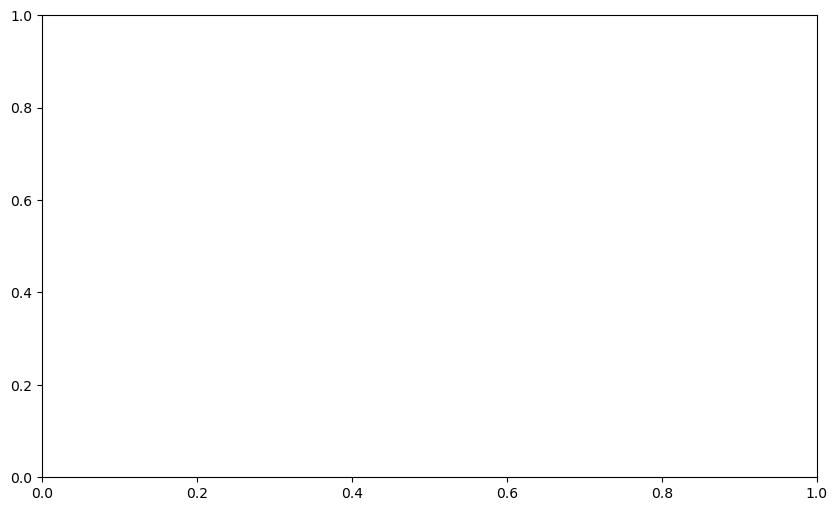

In [39]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 6))


palette = sns.color_palette("mako", 6)
#ells = ell_theory
for i in range(0, 6):
    ells = cells['SHE', 'SHE', i+1, i+1].ell
    ax.loglog(ells, ells*(2*ells+1)*cells['SHE', 'SHE', i+1, i+1][0][0], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=palette[i])
    ax.set_xlabel(r'$\ell$', font='Times New Roman', fontsize=20)
    ax.set_ylabel(r'$\ell (2\ell +1)C^{\rm EE}(\ell)$', font='Times New Roman', fontsize=20);
#axes.set_title("Original $n(z)$ (dashed lines) vs reconstructed $n(z)$ (solid lines) $C^{EE}(\ell)$'s", fontsize=14)
    ax.set_xlim(np.min(ells), np.max(ells))
    ax.legend()
